### Red predictora partidos

En este trabajo se buscará optimizar las ganancias en un ciclo de apuestas realizadas por dos modelos predictores principales, uno que buscará predecir el ganador de los partidos de futbol en las 5 grandes ligas europeas durante las últimas 5 temporadas desde la 2021/2022 hasta la reciente 2025/2026 y otro que decidirá si en el partido hay más o menos de 2.5 goles, la base de datos a utilizar es footbal_data.co.uk.

Para ambos modelos se tomarán en cuenta estadísticas recientes de los equipos incluyendo rachas de tiros y de tiros a puerta, rachas de puntos, rachas de goles, rachas de puntos y una nueva estadística agregada $ELO$ que refleja un puntuaje a cada equipo según sus partidos a lo largo de los 5 años, el puntuaje ELO incrementa o disminuye considerando el resultado del partido y el puntuaje ELO del rival al momento del enfrentamiento.

In [1]:
import soccerdata as sd
import pandas as pd
import requests
import io
import numpy as np

#SP1: LaLiga, I1: Serie A, D1: Bundesliga, F1: Ligue 1
ligas = ['E0', 'SP1', 'I1', 'D1', 'F1']
temporadas = ['2122', '2223','2324', '2425', '2526'] 
base_url = "https://www.football-data.co.uk/mmz4281/{}/{}.csv"

dfs = []

for liga in ligas:
    for temp in temporadas:
        try:
            url = base_url.format(temp, liga)
            s = requests.get(url).content
            df_temp = pd.read_csv(io.StringIO(s.decode('latin-1')))
            df_temp['League_ID'] = liga # Para guardar cada liga
            dfs.append(df_temp)
        except:
            continue

df_main = pd.concat(dfs, ignore_index=True)


cols_home = [c for c in df_main.columns if c.endswith('H') and c not in ['FTHG', 'HTHG']] 
cols_draw = [c for c in df_main.columns if c.endswith('D')]
cols_away = [c for c in df_main.columns if c.endswith('A') and c not in ['FTAG', 'HTAG']]

for col in cols_home + cols_draw + cols_away:
    df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

# Promedio de cuotas de apuestas (hay varias casas de apuestas)
df_main['Odds_Home'] = df_main[cols_home].mean(axis=1)
df_main['Odds_Draw'] = df_main[cols_draw].mean(axis=1)
df_main['Odds_Away'] = df_main[cols_away].mean(axis=1)

df_clean = df_main.dropna(subset=['Odds_Home', 'Odds_Away', 'FTHG']).copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)

# Calculamos puntos hechos en los partidos
condiciones = [
    (df_clean['FTHG'] > df_clean['FTAG']), # Gana Local
    (df_clean['FTHG'] == df_clean['FTAG']), # Empate
    (df_clean['FTHG'] < df_clean['FTAG'])  # Gana Visita
]
# Puntos para el Local
df_clean['Home_Pts'] = np.select(condiciones, [3, 1, 0]) # victoria = 3puntos, empate =1 punto, derrota = 0 puntos
# Puntos para el Visitante
df_clean['Away_Pts'] = np.select(condiciones, [0, 1, 3])

# Seleccionamos columnas importantes (tiros, goles, tiros al arco, casas de apuestas, puntos)
cols_keep = ['Date', 'League_ID', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 
             'Odds_Home', 'Odds_Draw', 'Odds_Away', 'Home_Pts', 'Away_Pts']
df_modelo = df_clean[cols_keep].sort_values('Date')


# Obtenemos las rachas de tiros, goles y puntos para cada equipo
def calcular_rachas_complejas(df):
    # Partidos de local
    home = df[['Date', 'HomeTeam', 'HS', 'AS', 'HST', 'AST', 'FTHG', 'FTAG', 'Home_Pts']].rename(
        columns={
            'HomeTeam': 'Team',
            'HS': 'Shots_Total_For',   'AS': 'Shots_Total_Ag',   # Tiros Totales (A favor / En contra)
            'HST': 'Shots_Target_For', 'AST': 'Shots_Target_Ag', # Tiros Arco (A favor / En contra)
            'FTHG': 'Goals_For',       'FTAG': 'Goals_Ag',
            'Home_Pts': 'Pts'
        }
    )
    
    # Partidos de visita 
    away = df[['Date', 'AwayTeam', 'AS', 'HS', 'AST', 'HST', 'FTAG', 'FTHG', 'Away_Pts']].rename(
        columns={
            'AwayTeam': 'Team',
            'AS': 'Shots_Total_For',   'HS': 'Shots_Total_Ag',   # Al revés para el visitante
            'AST': 'Shots_Target_For', 'HST': 'Shots_Target_Ag',
            'FTAG': 'Goals_For',       'FTHG': 'Goals_Ag',
            'Away_Pts': 'Pts'
        }
    )
    
    combined = pd.concat([home, away]).sort_values(['Team', 'Date'])
    
    # Obtenemos el promedio de los últimos 5 partidos para las siguientes métricas.
    metricas = ['Shots_Total_For', 'Shots_Total_Ag', 
                'Shots_Target_For', 'Shots_Target_Ag', 
                'Goals_For', 'Goals_Ag', 'Pts']
    
    for metrica in metricas:
        # Creamos la columna "Form_..."
        combined[f'Form_{metrica}'] = combined.groupby('Team')[metrica].transform(
            lambda x: x.shift().rolling(window=5, min_periods=3).mean()
        )
    
    return combined

df_rachas = calcular_rachas_complejas(df_modelo)

# Definimos las columnas que recién creamos
cols_a_usar = ['Date', 'Team', 
               'Form_Shots_Total_For', 'Form_Shots_Total_Ag',
               'Form_Shots_Target_For', 'Form_Shots_Target_Ag',
               'Form_Goals_For', 'Form_Goals_Ag', 
               'Form_Pts']

# Pegar al Local
df_final = pd.merge(df_modelo, df_rachas[cols_a_usar], 
                    left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='inner')

# Renombrar Local (Añadiendo Home_)
mapa_renombre_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_a_usar if col not in ['Date', 'Team']}
df_final.rename(columns=mapa_renombre_local, inplace=True)
df_final.drop(columns=['Team'], inplace=True)

# Pegar al Visitante 
df_final = pd.merge(df_final, df_rachas[cols_a_usar], 
                    left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='inner')

# Renombrar Visitante (Añadiendo Away_)
mapa_renombre_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_a_usar if col not in ['Date', 'Team']}
df_final.rename(columns=mapa_renombre_visita, inplace=True)
df_final.drop(columns=['Team'], inplace=True)

df_final.dropna(inplace=True)

print(f"Tenemos: {df_final.shape[0]} partidos procesados.")

print(df_final.head())

[03/20/26 13:19:50] INFO     No custom team name replacements found. You can configure these in       ]8;id=702227;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=204122;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\Moises\soccerdata\config\teamname_replacements.json.                         

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=544946;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=587075;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\soccerdata\_config.py#198\198]8;;\
                             C:\Users\Moises\soccerdata\config\league_dict.json.                                   

[03/20/26 13:20:39] WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_18892\4147581834.py:36:   ]8;id=187761;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=537857;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Home'] = df_main.mean(axis=1)                                         
                                                                                                                   

                    WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_18892\4147581834.py:37:   ]8;id=471044;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=441302;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Draw'] = df_main.mean(axis=1)                                         
                                                                                                                   

                    WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_18892\4147581834.py:38:   ]8;id=122986;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=824339;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Away'] = df_main.mean(axis=1)                                         
                                                                                                                   

Tenemos: 0 partidos procesados.
Empty DataFrame
Columns: [Date, League_ID, HomeTeam, AwayTeam, FTHG, FTAG, HS, AS, HST, AST, Odds_Home, Odds_Draw, Odds_Away, Home_Pts, Away_Pts, Home_Shots_Total_For_Form, Home_Shots_Total_Ag_Form, Home_Shots_Target_For_Form, Home_Shots_Target_Ag_Form, Home_Goals_For_Form, Home_Goals_Ag_Form, Home_Pts_Form, Away_Shots_Total_For_Form, Away_Shots_Total_Ag_Form, Away_Shots_Target_For_Form, Away_Shots_Target_Ag_Form, Away_Goals_For_Form, Away_Goals_Ag_Form, Away_Pts_Form]
Index: []

[0 rows x 29 columns]


In [2]:
# Aseguramos que las tablas tengan el orden correcto de las fechas para que al pegarlas sean la misma 
df_modelo['Date'] = pd.to_datetime(df_modelo['Date'])
df_rachas['Date'] = pd.to_datetime(df_rachas['Date'])

df_modelo['HomeTeam'] = df_modelo['HomeTeam'].astype(str).str.strip() # por si falla algún espacio ("Arsenal" =! "Arsenal ")
df_modelo['AwayTeam'] = df_modelo['AwayTeam'].astype(str).str.strip()
df_rachas['Team'] = df_rachas['Team'].astype(str).str.strip()

# Columnas que queremos traer (sin duplicar Fecha ni Equipo)
cols_metricas = [c for c in df_rachas.columns if c.startswith('Form_')]
cols_rachas_clean = ['Date', 'Team'] + cols_metricas

print(f"Inicio: {len(df_modelo)} partidos.")


# Left Join: "Mantén el partido aunque no encuentres la racha del local" (para los primeros partidos)
df_step1 = pd.merge(df_modelo, df_rachas[cols_rachas_clean], 
                    left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], 
                    how='left')

# Renombramos
mapa_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_step1.rename(columns=mapa_local, inplace=True)
df_step1.drop(columns=['Team'], inplace=True)



# Para visitante 
df_final = pd.merge(df_step1, df_rachas[cols_rachas_clean], 
                    left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], 
                    how='left')

# Renombramos
mapa_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final.rename(columns=mapa_visita, inplace=True)
df_final.drop(columns=['Team'], inplace=True)


# En lugar de borrar las filas con NaN (que son las primeras jornadas), esos datos se rellenan con el promedio del equipo 

cols_nuevas = list(mapa_local.values()) + list(mapa_visita.values())

# Rellenamos los huecos con el promedio 
for col in cols_nuevas:
    promedio = df_final[col].mean()
    df_final[col] = df_final[col].fillna(promedio)

print(f" FINAL: {len(df_final)} partidos recuperados y listos.")
display(df_final.tail())

Inicio: 8494 partidos.
 FINAL: 8494 partidos recuperados y listos.


,Date,League_ID,HomeTeam,AwayTeam,FTHG,FTAG,HS,AS,HST,AST,...,Home_Goals_For_Form,Home_Goals_Ag_Form,Home_Pts_Form,Away_Shots_Total_For_Form,Away_Shots_Total_Ag_Form,Away_Shots_Target_For_Form,Away_Shots_Target_Ag_Form,Away_Goals_For_Form,Away_Goals_Ag_Form,Away_Pts_Form
8489,2026-03-15,NaN,Sassuolo,Bologna,0,1,9.0,16.0,3.0,3.0,...,1.6,1.8,1.8,13.6,8.6,3.4,2.8,1.0,0.8,1.8
8490,2026-03-15,NaN,Rennes,Lille,1,2,12.0,8.0,4.0,3.0,...,2.4,0.8,2.4,14.2,7.0,3.2,2.8,0.8,0.4,1.8
8491,2026-03-16,NaN,Cremonese,Fiorentina,1,4,13.0,13.0,3.0,6.0,...,0.4,1.8,0.2,13.0,10.6,2.8,3.0,1.0,1.2,1.6
8492,2026-03-16,NaN,Vallecano,Levante,1,1,18.0,19.0,4.0,5.0,...,1.8,0.6,1.8,13.2,16.2,3.2,5.8,0.6,1.4,0.8
8493,2026-03-16,NaN,Brentford,Wolves,2,2,10.0,13.0,3.0,4.0,...,1.6,1.6,1.6,7.4,18.4,3.4,5.8,1.2,0.8,1.6


In [3]:
import numpy as np
import pandas as pd

def agregar_elo(df):
    """
    Recorre los partidos cronológicamente y calcula el rating ELO.
    Maneja cada Liga por separado
    """
    df = df.sort_values('Date').copy()  # ordenar por fecha 
    
    # Configuración ELO
    elo_inicial = 1500
    k_factor = 20       # Qué tanto cambia el ranking (en este caso usamos 20)
    ventaja_local = 50  # Puntos extra por jugar en casa (es más probable la victoria local)
    
    # Guarda el rating ELO para cada equipo
    elo_dict = {}
    
    # Listas para guardar los valores históricos
    elo_home_history = []
    elo_away_history = []
    
    
    for idx, row in df.iterrows(): #bucle partido a partido
        home = row['HomeTeam']
        away = row['AwayTeam']
        
        # 1. Recuperar ELO actual (o inicial si es nuevo)
        elo_h = elo_dict.get(home, elo_inicial)
        elo_a = elo_dict.get(away, elo_inicial)
        
        # Guardamos el ELO con el que llegan al partido
        elo_home_history.append(elo_h)
        elo_away_history.append(elo_a)
        
        # 2. Calcular Resultado Real
        goles_h = row['FTHG']
        goles_a = row['FTAG']
        
        if goles_h > goles_a:
            W_h = 1.0 # Gana Local
        elif goles_h == goles_a:
            W_h = 0.5 # Empate
        else:
            W_h = 0.0 # Gana Visita
            
        # Fórmula ELO estándar
        dr = (elo_h + ventaja_local) - elo_a   #diferencia de rating (notar que se le suma justamente la ventaja local)
        We_h = 1 / (10 ** (-dr / 400) + 1)   # fórmula ELO, convierte la diferencia de puntos de dos equipos en un porcentaje de probabilidad
        # Asigna un valor entre 0 y 1, si se acerca a 1 el local es favorito, si se acerca a cero el visitante es favorito
        # este mismo da información sobre si el resultado fue sorpresivo (muchos puntos) o lo esperado (pocos puntos)

        #  Actualizar ratings para el siguiente partido
        # Añadir un factor extra si el equipo gana por mucha diferencia de goles 
        diff = abs(goles_h - goles_a)
        multiplicador = 1.0 if diff < 2 else np.sqrt(diff) #si son dos goles multiplicador = 2^(1/2)
        
        cambio = k_factor * multiplicador * (W_h - We_h)   # usamos el factor y la diferencia entre lo predicho y lo que pasó en realidad 
        
        elo_dict[home] = elo_h + cambio # añadimos el cambio según el resultado 
        elo_dict[away] = elo_a - cambio
        
    # Agregamos las columnas al df original
    df['Elo_Home'] = elo_home_history
    df['Elo_Away'] = elo_away_history
    
    # Variable Poderosa: Diferencia de ELO
    df['Elo_Diff'] = (df['Elo_Home'] + ventaja_local) - df['Elo_Away']
    
    return df

# Ejecutamos el cálculo
df_elo = agregar_elo(df_clean)

print("Ejemplo: Real Madrid vs Barcelona (últimos registros):")
print(df_elo[df_elo['HomeTeam'].isin(['Real Madrid', 'Barcelona'])][['Date', 'HomeTeam', 'AwayTeam', 'Elo_Home', 'Elo_Away']].tail())

Ejemplo: Real Madrid vs Barcelona (últimos registros):
           Date     HomeTeam    AwayTeam     Elo_Home     Elo_Away
3586 2026-02-22    Barcelona     Levante  1810.276453  1418.193869
3592 2026-02-28    Barcelona  Villarreal  1812.797434  1666.439543
3599 2026-03-02  Real Madrid      Getafe  1793.292814  1455.537759
3615 2026-03-14  Real Madrid       Elche  1780.968536  1416.076218
3617 2026-03-15    Barcelona     Sevilla  1825.934510  1456.844991


In [4]:
# Aseguramos fechas
df_elo['Date'] = pd.to_datetime(df_elo['Date'])

# Limpiamos espacios en blanco
df_elo['HomeTeam'] = df_elo['HomeTeam'].astype(str).str.strip()
df_elo['AwayTeam'] = df_elo['AwayTeam'].astype(str).str.strip()

# Calculamos rachas sobre estos datos limpios
df_rachas_elo = calcular_rachas_complejas(df_elo)

# Aseguramos limpieza también en la tabla de rachas
df_rachas_elo['Date'] = pd.to_datetime(df_rachas_elo['Date'])
df_rachas_elo['Team'] = df_rachas_elo['Team'].astype(str).str.strip()

# hacer el merge 
cols_metricas = [c for c in df_rachas_elo.columns if c.startswith('Form_')]
cols_rachas_clean = ['Date', 'Team'] + cols_metricas


# Cruce Local
df_final_elo = pd.merge(df_elo, df_rachas_elo[cols_rachas_clean], 
                        left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], 
                        how='left')

# Renombrar
mapa_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_local, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Cruce visitante
df_final_elo = pd.merge(df_final_elo, df_rachas_elo[cols_rachas_clean], 
                        left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], 
                        how='left') 

# Renombrar
mapa_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_visita, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Rellenamos los vacíos con el promedio para no perder las primeras jornadas
cols_nuevas = list(mapa_local.values()) + list(mapa_visita.values())

for col in cols_nuevas:
    # Si la columna está vacía entera, rellenamos con 0
    if df_final_elo[col].isna().all():
        df_final_elo[col] = 0
    else:
        promedio = df_final_elo[col].mean()
        df_final_elo[col] = df_final_elo[col].fillna(promedio)

# Verificación final
df_final_elo.dropna(subset=['Elo_Home', 'Elo_Away'], inplace=True) # Solo borramos si falta el ELO (que es raro)

print(f" Tenemos: {len(df_final_elo)} partidos.")
display(df_final_elo.tail())

 Tenemos: 8494 partidos.


,ï»¿Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,Home_Goals_For_Form,Home_Goals_Ag_Form,Home_Pts_Form,Away_Shots_Total_For_Form,Away_Shots_Total_Ag_Form,Away_Shots_Target_For_Form,Away_Shots_Target_Ag_Form,Away_Goals_For_Form,Away_Goals_Ag_Form,Away_Pts_Form
8489,I1,2026-03-15,14:00,Sassuolo,Bologna,0,1,A,0.0,1.0,...,1.6,1.8,1.8,13.6,8.6,3.4,2.8,1.0,0.8,1.8
8490,F1,2026-03-15,19:45,Rennes,Lille,1,2,A,0.0,1.0,...,2.4,0.8,2.4,14.2,7.0,3.2,2.8,0.8,0.4,1.8
8491,I1,2026-03-16,19:45,Cremonese,Fiorentina,1,4,A,0.0,2.0,...,0.4,1.8,0.2,13.0,10.6,2.8,3.0,1.0,1.2,1.6
8492,SP1,2026-03-16,20:00,Vallecano,Levante,1,1,D,0.0,1.0,...,1.8,0.6,1.8,13.2,16.2,3.2,5.8,0.6,1.4,0.8
8493,E0,2026-03-16,20:00,Brentford,Wolves,2,2,D,2.0,1.0,...,1.6,1.6,1.6,7.4,18.4,3.4,5.8,1.2,0.8,1.6


Empezaremos con un diseño simple de redes neuronales, uno para la predicción de resultados y otro para la predicción de goles tomando en cuenta las rachas de estadísticas antes calculadas, se monitoreará el valor de pérdida, ya que lo que principalmente deseamos es que la red tenga seguridad en su decisión y obtenga menos errores.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("🧠 INICIALIZANDO RED NEURONAL DUAL (Ganador y Goles)...")

#definir variables 
features_ganador = [
    'Elo_Diff', 'Elo_Home', 'Elo_Away', 
    'Odds_Home', 'Odds_Draw', 'Odds_Away',
    'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form',
    'Home_Goals_For_Form', 'Home_Goals_Ag_Form', 'Home_Pts_Form',
    'Away_Shots_Total_For_Form', 'Away_Shots_Target_For_Form',
    'Away_Goals_For_Form', 'Away_Goals_Ag_Form', 'Away_Pts_Form'
]

features_goles = [
    'Elo_Diff', 'Elo_Home', 'Elo_Away', 
    'Odds_Home', 'Odds_Draw', 'Odds_Away',
    'Home_Goals_For_Form', 'Home_Goals_Ag_Form',
    'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form',
    'Away_Goals_For_Form', 'Away_Goals_Ag_Form',
    'Away_Shots_Total_For_Form', 'Away_Shots_Target_For_Form'
]

# Asegurar que los targets existan
if 'target_winner' not in df_final_elo.columns:
    df_final_elo['target_winner'] = np.where(df_final_elo['FTHG'] > df_final_elo['FTAG'], 0, 
                                    np.where(df_final_elo['FTHG'] == df_final_elo['FTAG'], 1, 2))

if 'target_goals' not in df_final_elo.columns:
    df_final_elo['target_goals'] = np.where((df_final_elo['FTHG'] + df_final_elo['FTAG']) > 2.5, 1, 0)

# Limpiar filas con NaNs en cualquiera de las columnas usadas
columnas_usadas = list(set(features_ganador + features_goles + ['target_winner', 'target_goals']))
df_nn = df_final_elo.dropna(subset=columnas_usadas).copy()

#dividir datos
cutoff = int(len(df_nn) * 0.8)

# Datos Ganador
X_w = df_nn[features_ganador]
y_w = df_nn['target_winner']
X_w_train_raw, X_w_test_raw = X_w.iloc[:cutoff], X_w.iloc[cutoff:]
y_w_train, y_w_test = y_w.iloc[:cutoff], y_w.iloc[cutoff:]

# Datos Goles
X_g = df_nn[features_goles]
y_g = df_nn['target_goals']
X_g_train_raw, X_g_test_raw = X_g.iloc[:cutoff], X_g.iloc[cutoff:]
y_g_train, y_g_test = y_g.iloc[:cutoff], y_g.iloc[cutoff:]

# ESCALADORES (Cruciales para Redes Neuronales)
scaler_w = StandardScaler()
X_w_train = scaler_w.fit_transform(X_w_train_raw)
X_w_test = scaler_w.transform(X_w_test_raw)

scaler_g = StandardScaler()
X_g_train = scaler_g.fit_transform(X_g_train_raw)
X_g_test = scaler_g.transform(X_g_test_raw)

# modelo de resultados (ganador)
print("\n🚀 Entrenando Red Neuronal: GANADOR...")
model_w = Sequential([
    Dense(64, activation='relu', input_shape=(X_w_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax') # 3 salidas (L, E, V)
])

model_w.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_w = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_w.fit(X_w_train, y_w_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[early_stop_w], verbose=0)

acc_w = accuracy_score(y_w_test, np.argmax(model_w.predict(X_w_test, verbose=0), axis=1))
print(f"🎯 Precisión Modelo Ganador: {acc_w:.2%}")

# modelo de goles
print("\n⚽ Entrenando Red Neuronal: GOLES...")
model_g = Sequential([
    Dense(64, activation='relu', input_shape=(X_g_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax') # 2 salidas (Under, Over)
])

model_g.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop_g = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_g.fit(X_g_train, y_g_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[early_stop_g], verbose=0)

acc_g = accuracy_score(y_g_test, np.argmax(model_g.predict(X_g_test, verbose=0), axis=1))
print(f"🎯 Precisión Modelo Goles: {acc_g:.2%}")

print("\n✅ ¡Ambas Redes Neuronales están listas!")

🧠 INICIALIZANDO RED NEURONAL DUAL (Ganador y Goles)...

🚀 Entrenando Red Neuronal: GANADOR...


[03/20/26 13:21:35] WARNING  C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\keras\src\laye ]8;id=201048;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=69209;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             rs\core\dense.py:95: UserWarning: Do not pass an                                      
                             `input_shape`/`input_dim` argument to a layer. When using Sequential                  
                             models, prefer using an `Input(shape)` object as the first layer in                   
                             the model instead.                                                                    
                               super().__init__(activity_regularizer=activity_regularizer,                         
                             **kwargs)                                                                             
                                                                                                                   

🎯 Precisión Modelo Ganador: 52.91%

⚽ Entrenando Red Neuronal: GOLES...


[03/20/26 13:22:00] WARNING  C:\Users\Moises\anaconda3\envs\tf_env\lib\site-packages\keras\src\laye ]8;id=575671;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=34621;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             rs\core\dense.py:95: UserWarning: Do not pass an                                      
                             `input_shape`/`input_dim` argument to a layer. When using Sequential                  
                             models, prefer using an `Input(shape)` object as the first layer in                   
                             the model instead.                                                                    
                               super().__init__(activity_regularizer=activity_regularizer,                         
                             **kwargs)                                                                             
                                                                                                                   

🎯 Precisión Modelo Goles: 56.74%

✅ ¡Ambas Redes Neuronales están listas!


Podemos mejorar el resultado, por ello para ambas trataremos de encontrar la mejor combinación de hiperparámetros que minimie el valor de pérdida o la función de costo, usaré la librería de Optune que corre distintas pruebas de hiperparámetros en el rango que especifiquemos y registra los intetos junto con su resultado.

In [7]:
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score

print("🔬 INICIANDO BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA...")

# Asumo que X_w_train, y_w_train, X_w_test, y_w_test y scaler_w ya están en memoria
# por haber ejecutado el código anterior.

def objective(trial):
    # 1. Optuna sugiere los hiperparámetros mágicos
    # ¿Cuántas neuronas en la capa 1 y 2?
    n_units_l1 = trial.suggest_int('n_units_l1', 32, 128, step=16)
    n_units_l2 = trial.suggest_int('n_units_l2', 16, 64, step=16)
    
    # ¿Cuánto Dropout (olvido) aplicar para no sobreajustar?
    dropout_l1 = trial.suggest_float('dropout_l1', 0.2, 0.5)
    dropout_l2 = trial.suggest_float('dropout_l2', 0.1, 0.4)
    
    # ¿A qué velocidad debe aprender?
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # 2. Construir la Red Neuronal Avanzada (Arreglado el UserWarning usando Input)
    model = Sequential([
        Input(shape=(X_w_train.shape[1],)),
        
        # Capa 1
        Dense(n_units_l1, activation='relu'),
        BatchNormalization(), # <--- NUEVO: Estabiliza el aprendizaje
        Dropout(dropout_l1),
        
        # Capa 2
        Dense(n_units_l2, activation='relu'),
        BatchNormalization(), # <--- NUEVO
        Dropout(dropout_l2),
        
        # Salida (3 clases)
        Dense(3, activation='softmax')
    ])

    # 3. Compilar
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # 4. Callbacks: EarlyStopping y Reducción de Learning Rate si se estanca
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)

    # 5. Entrenar silenciosamente (verbose=0 para no llenar la pantalla)
    model.fit(
        X_w_train, y_w_train,
        validation_split=0.2,
        epochs=50, # Máximo 50 por intento para no tardar una eternidad
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0 
    )

    # 6. Evaluar en el conjunto de validación interno
    # Optuna intentará minimizar el error (loss), que es mejor que solo mirar el accuracy
    loss, accuracy = model.evaluate(X_w_test, y_w_test, verbose=0)
    
    return loss # Devolvemos el loss porque queremos predicciones más "seguras" y calibradas

# ==========================================
# EJECUCIÓN DEL ESTUDIO (20 Intentos)
# ==========================================
# Ignorar warnings de Optuna/Tensorflow por limpieza
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("⏳ Entrenando 20 arquitecturas distintas. Esto tomará unos minutos...")

# Queremos minimizar el "loss" (la incertidumbre del modelo)
study = optuna.create_study(direction='minimize') 
study.optimize(objective, n_trials=20)

print("\n🏆 ¡BÚSQUEDA TERMINADA!")
print("Los mejores hiperparámetros encontrados son:")
mejores_params = study.best_params
for key, value in mejores_params.items():
    print(f"   👉 {key}: {value}")

# ==========================================
# ENTRENAR EL MODELO DEFINITIVO (EL GANADOR DE OPTUNA)
# ==========================================
print("\n🦾 Entrenando el 'Modelo Alpha' con los mejores parámetros...")

modelo_alpha_w = Sequential([
    Input(shape=(X_w_train.shape[1],)),
    Dense(mejores_params['n_units_l1'], activation='relu'),
    BatchNormalization(),
    Dropout(mejores_params['dropout_l1']),
    Dense(mejores_params['n_units_l2'], activation='relu'),
    BatchNormalization(),
    Dropout(mejores_params['dropout_l2']),
    Dense(3, activation='softmax')
])

modelo_alpha_w.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=mejores_params['learning_rate']),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

historial = modelo_alpha_w.fit(
    X_w_train, y_w_train,
    validation_split=0.15,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1 # Este sí lo mostramos para ver cómo aprende
)

acc_alpha = accuracy_score(y_w_test, np.argmax(modelo_alpha_w.predict(X_w_test), axis=1))
print(f"\n🎯 Precisión del Modelo Alpha (Ganador): {acc_alpha:.2%}")

🔬 INICIANDO BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA...
⏳ Entrenando 20 arquitecturas distintas. Esto tomará unos minutos...

🏆 ¡BÚSQUEDA TERMINADA!
Los mejores hiperparámetros encontrados son:
   👉 n_units_l1: 64
   👉 n_units_l2: 16
   👉 dropout_l1: 0.29008698822163714
   👉 dropout_l2: 0.35730490140560117
   👉 learning_rate: 0.009780610102649542

🦾 Entrenando el 'Modelo Alpha' con los mejores parámetros...
Epoch 1/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5031 - loss: 1.0440 - val_accuracy: 0.5345 - val_loss: 0.9867 - learning_rate: 0.0098
Epoch 2/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5218 - loss: 0.9947 - val_accuracy: 0.5276 - val_loss: 0.9824 - learning_rate: 0.0098
Epoch 3/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5284 - loss: 0.9911 - val_accuracy: 0.5355 - val_loss: 0.9841 - learning_rate: 0.0098
Epoch 4/150
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5310 - loss: 0.9844 - val_accuracy: 0.5365 - val_loss: 0.9817 - l

Una vez encontrando los mejores parámetros creamos una red con ellos y hacemos una simulación con el conjunto de prueba, la red apostará una cantidad fija en la decisión que tome y registrará las ganancias o pérdidas para hacer un conteo final.

Para que la red tome una decisión debe encontrar una situación lo suficientemente favorable, que supere un umbral del 5% en expected value, esto se hace con la probabilidad que arroja la red y con las cuotas en las casas de apuestas, por ejemplo si la red detecta que el equipo local tiene un 50% de probabilidades de ganar y la cuota en la casa de apuestas es de 2.20 apostar directamente en esta selección una gran cantidad de veces daría ganancias del 20%, ya que la cuota ideal sería de 2.00.

In [10]:
def simulacion_roi_red_neuronal(modelo, X_test_escalado, df_original_test):
    print("\n💰 SIMULACIÓN FINANCIERA: RED NEURONAL ALPHA...")
    
    saldo = 0
    apostado = 0
    stats = {'Ganador': 0, 'Doble': 0}
    aciertos = 0
    
    # Obtener probabilidades (Softmax) de toda la base de test
    probs_nn = modelo.predict(X_test_escalado, verbose=0)
    
    umbral = 0.05 # Buscamos un 5% de ventaja matemática (EV)
    
    df_test = df_original_test.reset_index(drop=True)
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        
        # Cuotas Reales (Sin escalar)
        odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
        
        # Probabilidades de la Red Neuronal
        p_L, p_E, p_V = probs_nn[i]
        
        # Cuotas Doble Oportunidad
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        # Cálculo de Valor Esperado (EV)
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1
        
        bet = None
        
        # Lógica de Apuesta (Similar al Sniper)
        if ev_L > umbral:
            if p_L > 0.45: bet = {'t': 'L', 'o': odd_L, 'res': 0}
            elif ev_1X > 0.02: bet = {'t': '1X', 'o': odd_1X, 'res': [0,1]}
        elif ev_V > umbral:
            if p_V > 0.45: bet = {'t': 'V', 'o': odd_V, 'res': 2}
            elif ev_X2 > 0.02: bet = {'t': 'X2', 'o': odd_X2, 'res': [1,2]}
            
        # Ejecutar apuesta
        if bet:
            apostado += 10
            win = False
            real_target = row['target_winner']
            
            if isinstance(bet['res'], list):
                if real_target in bet['res']: win = True; stats['Doble'] += 1
            else:
                if real_target == bet['res']: win = True; stats['Ganador'] += 1
            
            if win: 
                saldo += (10 * bet['o']) - 10
                aciertos += 1
            else: 
                saldo -= 10

    # REPORTE FINAL
    roi = (saldo / apostado * 100) if apostado > 0 else 0
    total_bets = sum(stats.values())
    
    print("-" * 50)
    print(f"💵 Inversión: {apostado}€  |  🤑 Balance: {saldo:.2f}€")
    print(f"📈 ROI TOTAL: {roi:.2f}%")
    print(f"🎯 Hit Rate (Aciertos): {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.1f}%)")
    print("-" * 50)
    print("Distribución de Apuestas:", stats)

# EJECUTAR SIMULACIÓN
# Usamos el DataFrame de Test (las filas después del cutoff) que contiene las cuotas intactas
df_test_real = df_nn.iloc[cutoff:]
simulacion_roi_red_neuronal(modelo_alpha_w, X_w_test, df_test_real)


💰 SIMULACIÓN FINANCIERA: RED NEURONAL ALPHA...
--------------------------------------------------
💵 Inversión: 4630€  |  🤑 Balance: 340.51€
📈 ROI TOTAL: 7.35%
🎯 Hit Rate (Aciertos): 294/294 (100.0%)
--------------------------------------------------
Distribución de Apuestas: {'Ganador': 275, 'Doble': 19}


Vemos que el ROI (retorno de inversión) después de la simulación es positivo y además supera el 5%, en realidad se hicieron 463 apuestas de las cuales se acertaron $294$, lo que representa el $63.5$% de acierto usando el criterio del umbral.

En el siguiente intentó, se utilizará la red que hemos trabajado pero al mismo tiempo se evaluará un modelo con XGBOOST, se promediarán las probabilidades y si aún se mantiene un Expected Value con cierta ventaja (> 5%) se hará la apuesta, de igual forma la simulación arrojará un ROI y apuestas ganadas.

In [14]:
from xgboost import XGBClassifier

print("🤝 INICIANDO PROTOCOLO ENSEMBLE (Fusión de Cerebros)...")

# Entrenar a XGBOOST
# Usamos los datos 'raw' (sin escalar) porque a XGBoost no le importa la escala
print("🌲 Entrenando a XGBoost para hacer equipo con la Red Neuronal...")
modelo_xgb_ens = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.03, random_state=42)
modelo_xgb_ens.fit(X_w_train_raw, y_w_train)

#Obtener predicciones de ambos modelos 
print("🧠 Generando predicciones combinadas...")

# Predicción XGBoost (Usa datos sin escalar)
probs_xgb = modelo_xgb_ens.predict_proba(X_w_test_raw)

# Predicción Red Neuronal (Usa datos escalados: X_w_test)
probs_nn = modelo_alpha_w.predict(X_w_test, verbose=0)

# LA FUSIÓN: Promediamos las probabilidades (Soft Voting)
probs_ensemble = (probs_xgb + probs_nn) / 2.0

# Simulación financiera con umbral del 7%
def simulacion_roi_ensemble(probs_combinadas, df_original_test):
    print("\n💰 SIMULACIÓN FINANCIERA: ENSEMBLE DEFINITIVO...")
    
    saldo = 0
    apostado = 0
    stats = {'Ganador': 0, 'Doble': 0}
    aciertos = 0
    
    umbral = 0.07 # E este caso aumentamos el umbral 
    df_test = df_original_test.reset_index(drop=True)
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        
        # Cuotas Reales
        odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
        
        # Probabilidades Combinadas (Ensemble)
        p_L, p_E, p_V = probs_combinadas[i]
        
        # Cuotas Doble Oportunidad
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        # Cálculo de Valor Esperado (EV) con la probabilidad fusionada
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1
        
        bet = None
        
        # Lógica de Apuesta
        if ev_L > umbral:
            if p_L > 0.45: bet = {'t': 'L', 'o': odd_L, 'res': 0}
            elif ev_1X > 0.02: bet = {'t': '1X', 'o': odd_1X, 'res': [0,1]}
        elif ev_V > umbral:
            if p_V > 0.45: bet = {'t': 'V', 'o': odd_V, 'res': 2}
            elif ev_X2 > 0.02: bet = {'t': 'X2', 'o': odd_X2, 'res': [1,2]}
            
        # Ejecutar apuesta
        if bet:
            apostado += 10
            win = False
            real_target = row['target_winner']
            
            # Contadores y verificación (Bug corregido)
            if isinstance(bet['res'], list):
                stats['Doble'] += 1
                if real_target in bet['res']: win = True
            else:
                stats['Ganador'] += 1
                if real_target == bet['res']: win = True
            
            if win: 
                saldo += (10 * bet['o']) - 10
                aciertos += 1
            else: 
                saldo -= 10

    # REPORTE FINAL
    roi = (saldo / apostado * 100) if apostado > 0 else 0
    total_bets = sum(stats.values())
    
    print("-" * 50)
    print(f"💵 Inversión: {apostado}€  |  🤑 Balance: {saldo:.2f}€")
    print(f"📈 ROI TOTAL: {roi:.2f}%")
    print(f"🎯 Hit Rate: {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.2f}%)")
    print("-" * 50)
    print("Distribución de Apuestas:", stats)

# EJECUTAR SIMULACIÓN
df_test_real = df_nn.iloc[cutoff:]
simulacion_roi_ensemble(probs_ensemble, df_test_real)

🤝 INICIANDO PROTOCOLO ENSEMBLE (Fusión de Cerebros)...
🌲 Entrenando a XGBoost para hacer equipo con la Red Neuronal...
🧠 Generando predicciones combinadas...

💰 SIMULACIÓN FINANCIERA: ENSEMBLE DEFINITIVO...
--------------------------------------------------
💵 Inversión: 4130€  |  🤑 Balance: 316.23€
📈 ROI TOTAL: 7.66%
🎯 Hit Rate: 272/413 (65.86%)
--------------------------------------------------
Distribución de Apuestas: {'Ganador': 400, 'Doble': 13}


    Observamos que la precisión promediando los modelos es mayor y por ende, hay mayor ROI, llegando a un 7.66 %

In [16]:
# Ahora se hará lo mismo para el modelo de Goles, el código principal se ejecutó en la siguiente celda
# El primer intennto muestra un resultado malo donde incluso se obtuvo un ROI negativo (-6.98%).

print("🔧 Reparando nombres de columnas de Goles...")

# 1. Buscar cómo se llaman las columnas de Over/Under en tu base actual
col_over = next((c for c in ['B365>2.5', 'BbAv>2.5', 'Avg>2.5'] if c in df_nn.columns), None)
col_under = next((c for c in ['B365<2.5', 'BbAv<2.5', 'Avg<2.5'] if c in df_nn.columns), None)

if col_over and col_under:
    print(f"✅ Nombres originales encontrados: {col_over} y {col_under}")
    
    # 2. Renombrar en el DataFrame principal de la Red Neuronal
    df_nn = df_nn.rename(columns={col_over: 'Odds_Over', col_under: 'Odds_Under'})
    
    # 3. Volver a extraer el Test Set ya con los nombres bonitos
    df_test_real = df_nn.iloc[cutoff:]
    
    print("✅ Nombres actualizados a 'Odds_Over' y 'Odds_Under'.")
    print("🚀 Lanzando simulación de nuevo...\n")
    
    # 4. Ejecutar la simulación
    simulacion_roi_goles_ensemble(probs_ensemble_goles, df_test_real)
    
elif 'Odds_Over' in df_nn.columns:
    print("✅ Las columnas ya estaban bien nombradas, lanzando simulación...")
    simulacion_roi_goles_ensemble(probs_ensemble_goles, df_test_real)
else:
    print("❌ ERROR: No encuentro ninguna columna de Goles. Ejecuta 'print(df_nn.columns)' para ver cómo se llaman.")

🔧 Reparando nombres de columnas de Goles...
✅ Nombres originales encontrados: B365>2.5 y B365<2.5
✅ Nombres actualizados a 'Odds_Over' y 'Odds_Under'.
🚀 Lanzando simulación de nuevo...


💰 SIMULACIÓN FINANCIERA: ENSEMBLE GOLES...
--------------------------------------------------
💵 Inversión: 4520€  |  🤑 Balance: -315.30€
📈 ROI GOLES: -6.98%
🎯 Hit Rate: 206/452 (45.58%)
--------------------------------------------------
Distribución de Apuestas: {'Over': 221, 'Under': 231}


In [52]:
from xgboost import XGBClassifier

print("⚽ INICIANDO ENSEMBLE DE GOLES (Over/Under 2.5)...")

# 1. Entrenar al compañero XGBoost para los Goles
# Usamos X_g_train_raw (los datos de goles sin escalar)
modelo_xgb_g = XGBClassifier(n_estimators=325, max_depth=4, learning_rate=0.0095, random_state=42)
modelo_xgb_g.fit(X_g_train_raw, y_g_train)

# 2. Generar predicciones para el Test Set
probs_xgb_g = modelo_xgb_g.predict_proba(X_g_test_raw)
probs_nn_g = model_g.predict(X_g_test, verbose=0) # X_g_test ya está escalado

# 3. La Fusión (Soft Voting para Goles)
probs_ensemble_goles = (probs_xgb_g + probs_nn_g) / 2.0

# 4. Simulación Financiera del Mercado de Goles
def simulacion_roi_goles_ensemble(probs_combinadas, df_original_test):
    print("\n💰 SIMULACIÓN FINANCIERA: ENSEMBLE GOLES...")
    
    saldo = 0
    apostado = 0
    stats = {'Over': 0, 'Under': 0}
    aciertos = 0
    
    umbral = 0.1 # Usamos un umbral del 10%
    df_test = df_original_test.reset_index(drop=True)
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        
        # Cuotas Reales
        odd_Ov = row['Odds_Over']
        odd_Un = row['Odds_Under']
        
        # Probabilidades Combinadas
        p_Un, p_Ov = probs_combinadas[i]
        
        # Cálculo de Valor Esperado (EV)
        ev_Ov = (p_Ov * odd_Ov) - 1
        ev_Un = (p_Un * odd_Un) - 1
        
        bet = None
        
        # Lógica de Apuesta
        if ev_Ov > umbral: bet = {'t': 'Over', 'o': odd_Ov, 'res': 1}
        elif ev_Un > umbral: bet = {'t': 'Under', 'o': odd_Un, 'res': 0}
            
        # Ejecutar apuesta
        if bet:
            apostado += 10
            win = False
            real_target = row['target_goals']
            
            # Contadores
            stats[bet['t']] += 1
            if real_target == bet['res']: win = True
            
            if win: 
                saldo += (10 * bet['o']) - 10
                aciertos += 1
            else: 
                saldo -= 10

    # REPORTE FINAL
    roi = (saldo / apostado * 100) if apostado > 0 else 0
    total_bets = sum(stats.values())
    
    print("-" * 50)
    print(f"💵 Inversión: {apostado}€  |  🤑 Balance: {saldo:.2f}€")
    print(f"📈 ROI GOLES: {roi:.2f}%")
    print(f"🎯 Hit Rate: {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.2f}%)")
    print("-" * 50)
    print("Distribución de Apuestas:", stats)

# EJECUTAR SIMULACIÓN DE GOLES
simulacion_roi_goles_ensemble(probs_ensemble_goles, df_test_real)

⚽ INICIANDO ENSEMBLE DE GOLES (Over/Under 2.5)...

💰 SIMULACIÓN FINANCIERA: ENSEMBLE GOLES...
--------------------------------------------------
💵 Inversión: 2680€  |  🤑 Balance: 164.20€
📈 ROI GOLES: 6.13%
🎯 Hit Rate: 133/268 (49.63%)
--------------------------------------------------
Distribución de Apuestas: {'Over': 133, 'Under': 135}


Usando un umbral más alto se puede obtener un ROI positivo $6.13$%, pero disminuye la cantidad de apuestas, apenas 268, ya que menos selecciones cumplen con la condición de un expected value muy grande.

In [31]:
def oraculo_kelly(equipo_local, equipo_visita, odd_L, odd_E, odd_V, odd_Over, odd_Under, bankroll=1000):
    print(f"\n🔮 ORÁCULO FINANCIERO: {equipo_local} vs {equipo_visita}")
    print(f"💰 Bankroll actual: {bankroll}€")
    
    try:
        # 1. Recuperar datos históricos
        row_h = df_final_elo[df_final_elo['HomeTeam'] == equipo_local].sort_values('Date').iloc[-1]
        row_a = df_final_elo[df_final_elo['AwayTeam'] == equipo_visita].sort_values('Date').iloc[-1]
        
        elo_diff = (row_h['Elo_Home'] + 50) - row_a['Elo_Away']
        
        # 2. Construir inputs (Mismas variables del modelo ganador y goles)
        input_w = pd.DataFrame({'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
                                'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
                                'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']], 'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
                                'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']], 'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']], 'Home_Pts_Form': [row_h['Home_Pts_Form']],
                                'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']], 'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']],
                                'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']], 'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']], 'Away_Pts_Form': [row_a['Away_Pts_Form']]})
        
        input_g = pd.DataFrame({'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
                                'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
                                'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']], 'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']],
                                'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']], 'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
                                'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']], 'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']],
                                'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']], 'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']]})
        
        input_w_scaled = scaler_w.transform(input_w)
        input_g_scaled = scaler_g.transform(input_g)
        
        # 3. Predicciones Ensemble
        p_w = (modelo_xgb_ens.predict_proba(input_w)[0] + modelo_alpha_w.predict(input_w_scaled, verbose=0)[0]) / 2.0
        p_g = (modelo_xgb_g.predict_proba(input_g)[0] + model_g.predict(input_g_scaled, verbose=0)[0]) / 2.0
        
        # 4. Función del Criterio de Kelly (Ajustado al 25% para ser conservador)
        def calcular_kelly(prob, odd):
            b = odd - 1
            q = 1 - prob
            kelly_fraction = (b * prob - q) / b
            return max(0, kelly_fraction * 0.25) # Nunca apostar menos de 0, y usar solo 1/4 del Kelly puro
            
        print("-" * 50)
        print(f"📊 PROBABILIDADES CONSENSUADAS (IA):")
        print(f"   1X2:  Loc {p_w[0]:.1%} | Emp {p_w[1]:.1%} | Vis {p_w[2]:.1%}")
        print(f"   Goles: Over {p_g[1]:.1%} | Under {p_g[0]:.1%}")
        print("-" * 50)
        
        # 5. Análisis de Inversión
        recos = []
        
        # Ganador
        k_L = calcular_kelly(p_w[0], odd_L)
        k_V = calcular_kelly(p_w[2], odd_V)
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        k_1X = calcular_kelly(p_w[0] + p_w[1], odd_1X)
        k_X2 = calcular_kelly(p_w[1] + p_w[2], odd_X2)
        
        # Filtro exigente (Solo apostar si Kelly recomienda > 0.5% del bankroll)
        if k_L > 0.005 and p_w[0] > 0.45: recos.append(f"🏆 GANA LOCAL | Apostar: {k_L*bankroll:.2f}€ ({(k_L*100):.2f}% del bank)")
        elif k_1X > 0.005: recos.append(f"🛡️ DOBLE 1X   | Apostar: {k_1X*bankroll:.2f}€ ({(k_1X*100):.2f}% del bank)")
            
        if k_V > 0.005 and p_w[2] > 0.45: recos.append(f"🏆 GANA VISITA | Apostar: {k_V*bankroll:.2f}€ ({(k_V*100):.2f}% del bank)")
        elif k_X2 > 0.005: recos.append(f"🛡️ DOBLE X2   | Apostar: {k_X2*bankroll:.2f}€ ({(k_X2*100):.2f}% del bank)")
            
        # Goles (Exigimos un Kelly del > 1% porque este mercado es muy traicionero)
        k_Ov = calcular_kelly(p_g[1], odd_Over)
        k_Un = calcular_kelly(p_g[0], odd_Under)
        
        if k_Ov > 0.01: recos.append(f"⚽ OVER 2.5   | Apostar: {k_Ov*bankroll:.2f}€ ({(k_Ov*100):.2f}% del bank)")
        elif k_Un > 0.01: recos.append(f"⛔ UNDER 2.5  | Apostar: {k_Un*bankroll:.2f}€ ({(k_Un*100):.2f}% del bank)")

        if recos:
            print("🚀 PLAN DE INVERSIÓN (Kelly Fraccional):")
            for r in recos: print("   " + r)
        else:
            print("💤 MANTENER CAPITAL. Matemáticamente no es rentable apostar aquí.")

    except Exception as e:
        print(f"❌ Error: {e}")

# Ejemplo de prueba (Local, Visita, C_L, C_E, C_V, C_Over, C_Under, Bankroll_Actual)
# oraculo_kelly('Real Madrid', 'Barcelona', 2.10, 3.60, 3.10, 1.65, 2.20, bankroll=500)

En el siguuiente código, se presenta otra forma de utilizar optuna para maximizar las ganancias, ahaora optuna no se fijará en el modelo que tenga menor valor en la función de costo, sino que en cada intento hará simulaciones para obtener el modelo que mejor ROI haya connseguido, para evitar que en la simulación los modelos no apuesten poco, se aplicará un castigo si es que el modelo apuesta menos de 300 veces

In [53]:
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

print("🧬 INICIANDO OPTUNA: BÚSQUEDA DEL MÁXIMO ROI (ENSEMBLE)...")

# 1. CREAR UN CONJUNTO DE VALIDACIÓN PARA OPTUNA
# No podemos usar X_w_test, porque si Optuna lo ve, nos estaremos engañando a nosotros mismos.
# Dividimos el conjunto de Train (X_w_train_raw) en Train_Opt y Val_Opt
X_train_opt, X_val_opt, y_train_opt, y_val_opt, df_train_opt, df_val_opt = train_test_split(
    X_w_train_raw, y_w_train, df_nn.iloc[:cutoff], test_size=0.2, shuffle=False
)

# Escalar para la Red Neuronal internamente
scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_val_opt_scaled = scaler_opt.transform(X_val_opt)

# Desactivar logs molestos de TensorFlow
tf.get_logger().setLevel('ERROR')

def objective_roi(trial):
    # --- 1. HIPERPARÁMETROS A BUSCAR ---
    # XGBoost
    xgb_n_est = trial.suggest_int('xgb_n_est', 150, 400, step=50)
    xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.05)
    
    # Red Neuronal
    nn_lr = trial.suggest_float('nn_lr', 0.001, 0.01, log=True)
    nn_dropout = trial.suggest_float('nn_dropout', 0.2, 0.4)
    
    # El Umbral Mágico
    umbral = trial.suggest_float('umbral', 0.05, 0.12) # Buscará entre 5% y 12%

    # --- 2. ENTRENAR XGBOOST ---
    modelo_xgb = XGBClassifier(n_estimators=xgb_n_est, learning_rate=xgb_lr, max_depth=4, random_state=42)
    modelo_xgb.fit(X_train_opt, y_train_opt)
    probs_xgb = modelo_xgb.predict_proba(X_val_opt)

    # --- 3. ENTRENAR RED NEURONAL ---
    modelo_nn = Sequential([
        Input(shape=(X_train_opt_scaled.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(3, activation='softmax')
    ])
    modelo_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=nn_lr),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    # Entrenamos rápido (30 epochs) para que Optuna no tarde años
    modelo_nn.fit(X_train_opt_scaled, y_train_opt, validation_split=0.2, 
                  epochs=30, batch_size=32, callbacks=[early_stop], verbose=0)
    probs_nn = modelo_nn.predict(X_val_opt_scaled, verbose=0)

    # --- 4. LA FUSIÓN ---
    probs_ensemble = (probs_xgb + probs_nn) / 2.0

    # --- 5. SIMULACIÓN DE ROI (Dentro del Optimizador) ---
    saldo = 0
    apostado = 0
    df_sim = df_val_opt.reset_index(drop=True)
    
    for i in range(len(df_sim)):
        row = df_sim.iloc[i]
        odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
        p_L, p_E, p_V = probs_ensemble[i]
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1
        
        bet = None
        if ev_L > umbral:
            if p_L > 0.45: bet = {'o': odd_L, 'res': 0}
            elif ev_1X > 0.02: bet = {'o': odd_1X, 'res': [0,1]}
        elif ev_V > umbral:
            if p_V > 0.45: bet = {'o': odd_V, 'res': 2}
            elif ev_X2 > 0.02: bet = {'o': odd_X2, 'res': [1,2]}
            
        if bet:
            apostado += 10
            real_target = row['target_winner']
            win = False
            if isinstance(bet['res'], list):
                if real_target in bet['res']: win = True
            else:
                if real_target == bet['res']: win = True
                
            if win: saldo += (10 * bet['o']) - 10
            else: saldo -= 10

    # --- 6. PENALIZACIÓN POR VOLUMEN BAJO ---
    # Si hace menos de 30 apuestas en todo el set de validación, lo castigamos.
    # No queremos un modelo que apueste 2 veces, gane 10€ y diga que tiene 50% de ROI.
    if apostado < 300: 
        return -100.0 # Castigo severo
        
    roi = (saldo / apostado) * 100
    return roi

# ==========================================
# EJECUTAR EL ESTUDIO (15 Intentos para Maximizar ROI)
# ==========================================
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("⏳ Entrenando sistemas y simulando carteras... (Puede tardar de 3 a 5 minutos)")

# ¡ATENCIÓN! direction='maximize' porque queremos el mayor ROI posible
study_roi = optuna.create_study(direction='maximize')
study_roi.optimize(objective_roi, n_trials=15) # Puedes subir a 30 si tienes paciencia

print("\n🏆 ¡OPTIMIZACIÓN FINANCIERA TERMINADA!")
print(f"💰 MEJOR ROI EN VALIDACIÓN: {study_roi.best_value:.2f}%")
print("Tus hiperparámetros de oro son:")
mejores_params_roi = study_roi.best_params
for key, value in mejores_params_roi.items():
    print(f"   👉 {key}: {value}")

🧬 INICIANDO OPTUNA: BÚSQUEDA DEL MÁXIMO ROI (ENSEMBLE)...
⏳ Entrenando sistemas y simulando carteras... (Puede tardar de 3 a 5 minutos)

🏆 ¡OPTIMIZACIÓN FINANCIERA TERMINADA!
💰 MEJOR ROI EN VALIDACIÓN: 9.45%
Tus hiperparámetros de oro son:
   👉 xgb_n_est: 150
   👉 xgb_lr: 0.019398439536259866
   👉 nn_lr: 0.005003532602125055
   👉 nn_dropout: 0.26755993798025635
   👉 umbral: 0.09321677215572277


Tras hacer el estudio en optuna hemos encontrado los hiperparámetros en ambos modelos (XGBOOST, Red neuronal) que dan el  mejor ROI, en el siguiente código se crearán los modelos con esos parámetros y se probaran con el conjutno de datos de prueba.

In [54]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

print("🚀 INICIANDO EL 'SUPER EQUIPO' EN EL MUNDO REAL...")

# Extraer los hiperparámetros de Optuna 
best_xgb_n = mejores_params_roi['xgb_n_est']
best_xgb_lr = mejores_params_roi['xgb_lr']
best_nn_lr = mejores_params_roi['nn_lr']
best_nn_drop = mejores_params_roi['nn_dropout']
umbral_optimo = mejores_params_roi['umbral']

print("-" * 50)
print(f"🔧 Configuración cargada:")
print(f"   XGBoost -> Árboles: {best_xgb_n} | LR: {best_xgb_lr:.4f}")
print(f"   Red Neuronal -> LR: {best_nn_lr:.4f} | Dropout: {best_nn_drop:.2%}")
print(f"   Umbral de Disparo -> {umbral_optimo:.2%}")
print("-" * 50)

# Entrenar a XGBOOST
print("🌲 Entrenando al Experto XGBoost...")
# Usamos X_w_train_raw (toda la base de entrenamiento sin escalar)
modelo_final_xgb = XGBClassifier(
    n_estimators=best_xgb_n, 
    learning_rate=best_xgb_lr, 
    max_depth=4, 
    random_state=42
)
modelo_final_xgb.fit(X_w_train_raw, y_w_train)

# Entrenar a la red Neuronal
print("🧠 Entrenando al Experto Red Neuronal...")
# Usamos X_w_train (toda la base de entrenamiento escalada)
modelo_final_nn = Sequential([
    Input(shape=(X_w_train.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(best_nn_drop),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(best_nn_drop),
    Dense(3, activation='softmax')
])

modelo_final_nn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_nn_lr),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
modelo_final_nn.fit(
    X_w_train, y_w_train, 
    validation_split=0.15, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop_final], 
    verbose=0
)

# Usamos el conjunto de TEST
print("⚖️ Generando predicciones fusionadas en partidos nunca antes vistos...")

# Predicciones
probs_test_xgb = modelo_final_xgb.predict_proba(X_w_test_raw)
probs_test_nn = modelo_final_nn.predict(X_w_test, verbose=0)

# Fusión (Ensemble Soft Voting)
probs_test_ensemble = (probs_test_xgb + probs_test_nn) / 2.0

# Simulación de Rentabilidad (ROI)
print("\n💰 SIMULACIÓN FINANCIERA (TEST SET REAL)...")

saldo = 0
apostado = 0
stats = {'Ganador': 0, 'Doble': 0}
aciertos = 0

# df_test_real contiene los partidos del 20% final (Test) intactos
df_sim = df_test_real.reset_index(drop=True)

for i in range(len(df_sim)):
    row = df_sim.iloc[i]
    odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
    p_L, p_E, p_V = probs_test_ensemble[i]
    
    odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
    odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
    
    ev_L = (p_L * odd_L) - 1
    ev_V = (p_V * odd_V) - 1
    ev_1X = ((p_L + p_E) * odd_1X) - 1
    ev_X2 = ((p_E + p_V) * odd_X2) - 1
    
    bet = None
    
    if ev_L > umbral_optimo:
        if p_L > 0.45: bet = {'o': odd_L, 'res': 0}
        elif ev_1X > 0.02: bet = {'o': odd_1X, 'res': [0,1]}
    elif ev_V > umbral_optimo:
        if p_V > 0.45: bet = {'o': odd_V, 'res': 2}
        elif ev_X2 > 0.02: bet = {'o': odd_X2, 'res': [1,2]}
        
    if bet:
        apostado += 10
        real_target = row['target_winner']
        win = False
        
        if isinstance(bet['res'], list):
            stats['Doble'] += 1
            if real_target in bet['res']: win = True
        else:
            stats['Ganador'] += 1
            if real_target == bet['res']: win = True
            
        if win: 
            saldo += (10 * bet['o']) - 10
            aciertos += 1
        else: 
            saldo -= 10

# REPORTE FINAL
roi = (saldo / apostado * 100) if apostado > 0 else 0
total_bets = sum(stats.values())

print("-" * 50)
print(f"💵 Inversión: {apostado}€  |  🤑 Balance Neto: {saldo:.2f}€")
print(f"📈 ROI FINAL REAL: {roi:.2f}%")
print(f"🎯 Hit Rate: {aciertos}/{total_bets} ({(aciertos/max(total_bets, 1))*100:.2f}%)")
print("-" * 50)
print("Distribución de Apuestas:", stats)

🚀 INICIANDO EL 'SUPER EQUIPO' EN EL MUNDO REAL...
--------------------------------------------------
🔧 Configuración cargada:
   XGBoost -> Árboles: 150 | LR: 0.0194
   Red Neuronal -> LR: 0.0050 | Dropout: 26.76%
   Umbral de Disparo -> 9.32%
--------------------------------------------------
🌲 Entrenando al Experto XGBoost...
🧠 Entrenando al Experto Red Neuronal...
⚖️ Generando predicciones fusionadas en partidos nunca antes vistos...

💰 SIMULACIÓN FINANCIERA (TEST SET REAL)...
--------------------------------------------------
💵 Inversión: 2840€  |  🤑 Balance Neto: 447.60€
📈 ROI FINAL REAL: 15.76%
🎯 Hit Rate: 210/284 (73.94%)
--------------------------------------------------
Distribución de Apuestas: {'Ganador': 279, 'Doble': 5}


El resultado es fantástico a este punto, llegando casi al $74$% de precisión en las selecciones y a un ROI del $15.76$%

Aún es mejorable con el mismo modelo, e las simulaciones se hacen apuestas con un monto fijo, sin embargo, algunas apuestas son más arriesgadas u ofrecen menos valor que otras, por ejemplo, el modelo puede detectar una ventaa matemática con selecciones que tienen menos del 50% de probabilidad por una cuota alta en la casa de apuestas, sin embargo al no ser muy segura no es convemiente invertir la misma cantidad que en apuestas cuyo valor en probabilidad son mucho más altas, esto lo toma encuenta la fórmula de Kelly, que decide el presupuesto que se debe invertir según la pribabilidad que arroja el modelo, en este caso se hará una simulación implementando el criterio de Kelly.

🏦 INICIANDO SIMULACIÓN DE CAPITAL (CRITERIO DE KELLY)...
--------------------------------------------------
💶 Capital Inicial: 1000.00€
💰 Capital Final:   8426.22€
🚀 Crecimiento de la Cuenta: 742.62%
--------------------------------------------------
💵 Total Dinero Movido: 51570.72€
📈 ROI Promedio (Kelly): 14.40%
🎯 Hit Rate: 210/284 (73.94%)
--------------------------------------------------


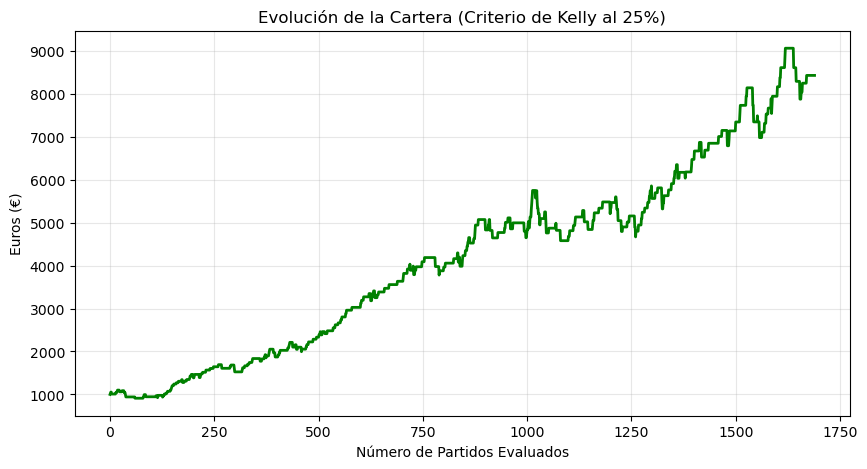

In [55]:
import matplotlib.pyplot as plt

print("🏦 INICIANDO SIMULACIÓN DE CAPITAL (CRITERIO DE KELLY)...")

bankroll_inicial = 1000.0
bankroll = bankroll_inicial
historial_bankroll = [bankroll]

apostado_total = 0
apuestas_realizadas = 0
aciertos_kelly = 0

# Usaremos las predicciones que ya calculamos en el paso anterior (probs_test_ensemble)
# y el DataFrame de prueba real (df_test_real)
df_sim_kelly = df_test_real.reset_index(drop=True)

for i in range(len(df_sim_kelly)):
    row = df_sim_kelly.iloc[i]
    odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
    p_L, p_E, p_V = probs_test_ensemble[i]
    
    odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
    odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
    
    ev_L = (p_L * odd_L) - 1
    ev_V = (p_V * odd_V) - 1
    ev_1X = ((p_L + p_E) * odd_1X) - 1
    ev_X2 = ((p_E + p_V) * odd_X2) - 1
    
    bet = None
    p_bet = 0
    odd_bet = 0
    
    # Filtro de disparo (Usando Umbral Óptimo de Optuna)
    if ev_L > umbral_optimo:
        if p_L > 0.45: bet = {'res': 0}; p_bet = p_L; odd_bet = odd_L
        elif ev_1X > 0.02: bet = {'res': [0,1]}; p_bet = p_L + p_E; odd_bet = odd_1X
    elif ev_V > umbral_optimo:
        if p_V > 0.45: bet = {'res': 2}; p_bet = p_V; odd_bet = odd_V
        elif ev_X2 > 0.02: bet = {'res': [1,2]}; p_bet = p_E + p_V; odd_bet = odd_X2
            
    if bet:
        # FÓRMULA DE KELLY
        b = odd_bet - 1 # Ganancia neta
        q = 1 - p_bet   # Probabilidad de perder
        
        kelly_fraction = (b * p_bet - q) / b
        
        # Ajustes de Seguridad: Quarter Kelly y Cap del 5%
        kelly_ajustado = max(0, kelly_fraction * 0.25)
        porcentaje_a_apostar = min(kelly_ajustado, 0.05)
        
        stake = bankroll * porcentaje_a_apostar
        
        # Solo apostamos si el monto tiene sentido (> 1 euro)
        if stake > 1.0:
            apuestas_realizadas += 1
            apostado_total += stake
            real_target = row['target_winner']
            win = False
            
            if isinstance(bet['res'], list):
                if real_target in bet['res']: win = True
            else:
                if real_target == bet['res']: win = True
                
            if win:
                bankroll += (stake * b)
                aciertos_kelly += 1
            else:
                bankroll -= stake
                
    historial_bankroll.append(bankroll)

# REPORTE FINANCIERO
roi_kelly = ((bankroll - bankroll_inicial) / apostado_total * 100) if apostado_total > 0 else 0
crecimiento_cuenta = ((bankroll / bankroll_inicial) - 1) * 100

print("-" * 50)
print(f"💶 Capital Inicial: {bankroll_inicial:.2f}€")
print(f"💰 Capital Final:   {bankroll:.2f}€")
print(f"🚀 Crecimiento de la Cuenta: {crecimiento_cuenta:.2f}%")
print("-" * 50)
print(f"💵 Total Dinero Movido: {apostado_total:.2f}€")
print(f"📈 ROI Promedio (Kelly): {roi_kelly:.2f}%")
print(f"🎯 Hit Rate: {aciertos_kelly}/{apuestas_realizadas} ({(aciertos_kelly/max(apuestas_realizadas, 1))*100:.2f}%)")
print("-" * 50)

# Gráfica del Bankroll
plt.figure(figsize=(10, 5))
plt.plot(historial_bankroll, color='green', linewidth=2)
plt.title('Evolución de la Cartera (Criterio de Kelly al 25%)')
plt.xlabel('Número de Partidos Evaluados')
plt.ylabel('Euros (€)')
plt.grid(True, alpha=0.3)
plt.show()

El resultado obtenido es aún mejor, los aciertos se mantienen ya que la red no cambia de decisión, sin embargo, la ganancia se maximiza tomando en cuenta el criterio de Kelly ya que invierte más en algunas apuestas cuyo valor ofrecido es coonsiderable, se ha llegado a un crecimiento del $842$ % de la inversión inicial, algo impresionante.

El siguiete código simplemente toma los modelos y hace una predicción del partido según las cuotas en la casa de apuestas y el partido que se va a jugar, es el paso para predecir partidos que aún no se han jugado.

In [56]:
import pandas as pd
import numpy as np

print("🔮 INICIALIZANDO ORÁCULO DE PRODUCCIÓN (SUPER EQUIPO)...")

def oraculo_produccion(equipo_local, equipo_visita, odd_L, odd_E, odd_V, bankroll=1000.0):
    print(f"\n==================================================")
    print(f"🏟️ PARTIDO: {equipo_local} vs {equipo_visita}")
    print(f"💰 BANKROLL DISPONIBLE: {bankroll:.2f}€")
    print(f"==================================================")
    
    try:
        # 1. Buscar los últimos datos conocidos de ambos equipos en tu base histórica
        row_h = df_final_elo[df_final_elo['HomeTeam'] == equipo_local].sort_values('Date').iloc[-1]
        row_a = df_final_elo[df_final_elo['AwayTeam'] == equipo_visita].sort_values('Date').iloc[-1]
        
        # 2. Calcular la diferencia de ELO actual (Sumamos 50 al local por la ventaja de casa)
        elo_diff = (row_h['Elo_Home'] + 50) - row_a['Elo_Away']
        
        # 3. Construir el Input exacto que requiere el modelo
        input_w = pd.DataFrame({
            'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
            'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
            'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']],
            'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
            'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']],
            'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']],
            'Home_Pts_Form': [row_h['Home_Pts_Form']],
            'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']],
            'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']],
            'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']],
            'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']],
            'Away_Pts_Form': [row_a['Away_Pts_Form']]
        })
        
        # 4. Escalar los datos solo para la Red Neuronal (Usamos el scaler que ya tenías)
        input_w_scaled = scaler_w.transform(input_w)
        
        # 5. CONSULTA AL SUPER EQUIPO (Fusión)
        prob_xgb = modelo_final_xgb.predict_proba(input_w)[0]
        prob_nn = modelo_final_nn.predict(input_w_scaled, verbose=0)[0]
        p_w = (prob_xgb + prob_nn) / 2.0
        
        # 6. MATEMÁTICAS DE APUESTAS (EV y Cuotas Dobles)
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_w[0] * odd_L) - 1
        ev_V = (p_w[2] * odd_V) - 1
        ev_1X = ((p_w[0] + p_w[1]) * odd_1X) - 1
        ev_X2 = ((p_w[1] + p_w[2]) * odd_X2) - 1
        
        print(f"📊 PREDICCIÓN IA: Local {p_w[0]:.1%} | Empate {p_w[1]:.1%} | Visita {p_w[2]:.1%}")
        
        # 7. GESTIÓN DE CAPITAL (Quarter Kelly con tope del 5%)
        def calcular_inversion(probabilidad, cuota):
            b = cuota - 1
            q = 1 - probabilidad
            kelly_puro = (b * probabilidad - q) / b
            kelly_ajustado = max(0, kelly_puro * 0.25)
            inversion_final = min(kelly_ajustado, 0.05) # Cap del 5%
            return inversion_final
        
        # 8. EMITIR RECOMENDACIONES
        hay_apuesta = False
        
        # Usamos tu umbral de oro extraído de Optuna (umbral_optimo)
        print("-" * 50)
        
        if ev_L > umbral_optimo and p_w[0] > 0.45:
            inv = calcular_inversion(p_w[0], odd_L)
            if inv > 0:
                print(f"🟢 ALERTA DE VALOR: Apostar a GANA LOCAL")
                print(f"   Cuota: {odd_L} | Ventaja Matemática (EV): +{ev_L:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True
                
        elif ev_1X > umbral_optimo:
            inv = calcular_inversion(p_w[0] + p_w[1], odd_1X)
            if inv > 0:
                print(f"🟡 ALERTA DE VALOR SEGURA: Apostar a DOBLE 1X (Local o Empate)")
                print(f"   Cuota: {odd_1X:.2f} | Ventaja Matemática (EV): +{ev_1X:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True

        if ev_V > umbral_optimo and p_w[2] > 0.45:
            inv = calcular_inversion(p_w[2], odd_V)
            if inv > 0:
                print(f"🟢 ALERTA DE VALOR: Apostar a GANA VISITA")
                print(f"   Cuota: {odd_V} | Ventaja Matemática (EV): +{ev_V:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True
                
        elif ev_X2 > umbral_optimo:
            inv = calcular_inversion(p_w[1] + p_w[2], odd_X2)
            if inv > 0:
                print(f"🟡 ALERTA DE VALOR SEGURA: Apostar a DOBLE X2 (Visita o Empate)")
                print(f"   Cuota: {odd_X2:.2f} | Ventaja Matemática (EV): +{ev_X2:.2%}")
                print(f"   👉 INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}% de tu bankroll)")
                hay_apuesta = True

        if not hay_apuesta:
            print("💤 SIN VALOR SUFICIENTE. La IA recomienda NO apostar en este partido.")
            print(f"   (Ninguna opción supera tu umbral exigente del {umbral_optimo:.2%})")
            
        print("==================================================\n")

    except Exception as e:
        print(f"❌ Error buscando a los equipos: {e}")
        print("   Asegúrate de escribir los nombres exactamente como aparecen en el Excel (Ej: 'Real Madrid', no 'R. Madrid').")

print("✅ Oráculo listo para usar.")

🔮 INICIALIZANDO ORÁCULO DE PRODUCCIÓN (SUPER EQUIPO)...
✅ Oráculo listo para usar.


In [59]:
oraculo_produccion('Ath Madrid','Tottenham',1.54,4.35,5.53,100)


🏟️ PARTIDO: Ath Madrid vs Tottenham
💰 BANKROLL DISPONIBLE: 100.00€
📊 PREDICCIÓN IA: Local 71.6% | Empate 18.0% | Visita 10.4%
--------------------------------------------------
🟢 ALERTA DE VALOR: Apostar a GANA LOCAL
   Cuota: 1.54 | Ventaja Matemática (EV): +10.32%
   👉 INVERTIR: 4.78€ (4.78% de tu bankroll)



In [57]:
import joblib

print("💾 INICIANDO PROTOCOLO DE EXPORTACIÓN...")

# 1. Guardar el modelo XGBoost y el Escalador (Usamos joblib que es genial para Scikit-Learn/XGB)
joblib.dump(modelo_final_xgb, 'oraculo_xgboost.pkl')
joblib.dump(scaler_w, 'oraculo_scaler.pkl')
print("   ✅ XGBoost y Escalador guardados (.pkl)")

# 2. Guardar la Red Neuronal (Keras tiene su propio formato optimizado)
modelo_final_nn.save('oraculo_red_neuronal.keras')
print("   ✅ Red Neuronal guardada (.keras)")

# 3. Guardar tu Umbral Óptimo de Optuna (Para que el oráculo sepa cuándo disparar)
joblib.dump(umbral_optimo, 'oraculo_umbral.pkl')
print("   ✅ Umbral de disparo guardado (.pkl)")

print("\n🎉 ¡SUPER EQUIPO CONGELADO CON ÉXITO!")
print("Ahora puedes apagar la computadora. Tus modelos están a salvo en tu carpeta.")

💾 INICIANDO PROTOCOLO DE EXPORTACIÓN...
   ✅ XGBoost y Escalador guardados (.pkl)
   ✅ Red Neuronal guardada (.keras)
   ✅ Umbral de disparo guardado (.pkl)

🎉 ¡SUPER EQUIPO CONGELADO CON ÉXITO!
Ahora puedes apagar la computadora. Tus modelos están a salvo en tu carpeta.


In [ ]:
import pandas as pd
import numpy as np
import requests
import io
import joblib
import os
from tensorflow.keras.models import load_model

print("⚙️ INICIANDO PROTOCOLO DE VIERNES: ACTUALIZACIÓN TOTAL...")

# ==========================================
# PASO 1: DESCARGAR DATOS FRESCOS
# ==========================================
print("\n🌐 1. Descargando resultados actualizados...")
ligas = ['E0', 'SP1', 'I1', 'D1', 'F1']
temporadas = ['2122', '2223','2324', '2425', '2526']
base_url = "https://www.football-data.co.uk/mmz4281/{}/{}.csv"

dfs = []
for liga in ligas:
    for temp in temporadas:
        try:
            url = base_url.format(temp, liga)
            s = requests.get(url).content
            df_temp = pd.read_csv(io.StringIO(s.decode('latin-1')))
            df_temp['League_ID'] = liga
            dfs.append(df_temp)
        except:
            continue

df_main = pd.concat(dfs, ignore_index=True)
print(f"   ✅ Base de datos descargada: {len(df_main)} partidos.")

# ==========================================
# PASO 2: LIMPIEZA Y PROMEDIO DE CUOTAS
# ==========================================
print("\n🧹 2. Limpiando datos y calculando cuotas/puntos...")
cols_home = [c for c in df_main.columns if c.endswith('H') and c not in ['FTHG', 'HTHG']]
cols_draw = [c for c in df_main.columns if c.endswith('D')]
cols_away = [c for c in df_main.columns if c.endswith('A') and c not in ['FTAG', 'HTAG']]

for col in cols_home + cols_draw + cols_away:
    df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

df_main['Odds_Home'] = df_main[cols_home].mean(axis=1)
df_main['Odds_Draw'] = df_main[cols_draw].mean(axis=1)
df_main['Odds_Away'] = df_main[cols_away].mean(axis=1)

df_clean = df_main.dropna(subset=['Odds_Home', 'Odds_Away', 'FTHG']).copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)

condiciones = [
    (df_clean['FTHG'] > df_clean['FTAG']),
    (df_clean['FTHG'] == df_clean['FTAG']),
    (df_clean['FTHG'] < df_clean['FTAG'])
]
df_clean['Home_Pts'] = np.select(condiciones, [3, 1, 0])
df_clean['Away_Pts'] = np.select(condiciones, [0, 1, 3])

# ==========================================
# PASO 3: FUNCIONES MATEMÁTICAS (ELO Y RACHAS)
# ==========================================
print("\n🧮 3. Calculando el sistema ELO y las Rachas...")
def agregar_elo(df):
    df = df.sort_values('Date').copy()
    elo_inicial = 1500; k_factor = 20; ventaja_local = 50
    elo_dict = {}
    elo_home_history, elo_away_history = [], []

    for idx, row in df.iterrows():
        home, away = row['HomeTeam'], row['AwayTeam']
        elo_h, elo_a = elo_dict.get(home, elo_inicial), elo_dict.get(away, elo_inicial)
        elo_home_history.append(elo_h)
        elo_away_history.append(elo_a)

        goles_h, goles_a = row['FTHG'], row['FTAG']
        if goles_h > goles_a: W_h = 1.0
        elif goles_h == goles_a: W_h = 0.5
        else: W_h = 0.0

        dr = (elo_h + ventaja_local) - elo_a
        We_h = 1 / (10 ** (-dr / 400) + 1)
        diff = abs(goles_h - goles_a)
        multiplicador = 1.0 if diff < 2 else np.sqrt(diff)

        cambio = k_factor * multiplicador * (W_h - We_h)
        elo_dict[home] = elo_h + cambio
        elo_dict[away] = elo_a - cambio

    df['Elo_Home'] = elo_home_history
    df['Elo_Away'] = elo_away_history
    df['Elo_Diff'] = (df['Elo_Home'] + ventaja_local) - df['Elo_Away']
    return df

def calcular_rachas_complejas(df):
    home = df[['Date', 'HomeTeam', 'HS', 'AS', 'HST', 'AST', 'FTHG', 'FTAG', 'Home_Pts']].rename(
        columns={'HomeTeam': 'Team', 'HS': 'Shots_Total_For', 'AS': 'Shots_Total_Ag',
                 'HST': 'Shots_Target_For', 'AST': 'Shots_Target_Ag', 'FTHG': 'Goals_For', 'FTAG': 'Goals_Ag', 'Home_Pts': 'Pts'}
    )
    away = df[['Date', 'AwayTeam', 'AS', 'HS', 'AST', 'HST', 'FTAG', 'FTHG', 'Away_Pts']].rename(
        columns={'AwayTeam': 'Team', 'AS': 'Shots_Total_For', 'HS': 'Shots_Total_Ag',
                 'AST': 'Shots_Target_For', 'HST': 'Shots_Target_Ag', 'FTAG': 'Goals_For', 'FTHG': 'Goals_Ag', 'Away_Pts': 'Pts'}
    )
    combined = pd.concat([home, away]).sort_values(['Team', 'Date'])
    metricas = ['Shots_Total_For', 'Shots_Total_Ag', 'Shots_Target_For', 'Shots_Target_Ag', 'Goals_For', 'Goals_Ag', 'Pts']
    for metrica in metricas:
        combined[f'Form_{metrica}'] = combined.groupby('Team')[metrica].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
    return combined

# Ejecutar funciones
df_elo = agregar_elo(df_clean)
df_elo['Date'] = pd.to_datetime(df_elo['Date'])
df_elo['HomeTeam'] = df_elo['HomeTeam'].astype(str).str.strip()
df_elo['AwayTeam'] = df_elo['AwayTeam'].astype(str).str.strip()

df_rachas = calcular_rachas_complejas(df_elo)
df_rachas['Date'] = pd.to_datetime(df_rachas['Date'])
df_rachas['Team'] = df_rachas['Team'].astype(str).str.strip()

# ==========================================
# PASO 4: FUSIÓN FINAL (CREACIÓN DE df_final_elo)
# ==========================================
cols_metricas = [c for c in df_rachas.columns if c.startswith('Form_')]
cols_rachas_clean = ['Date', 'Team'] + cols_metricas

# Join Local (Left join para no perder los primeros partidos)
df_final_elo = pd.merge(df_elo, df_rachas[cols_rachas_clean], left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
mapa_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_local, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Join Visita
df_final_elo = pd.merge(df_final_elo, df_rachas[cols_rachas_clean], left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
mapa_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_visita, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Rellenar nulos con el promedio
cols_nuevas = list(mapa_local.values()) + list(mapa_visita.values())
for col in cols_nuevas:
    if df_final_elo[col].isna().all(): df_final_elo[col] = 0
    else:
        promedio = df_final_elo[col].mean()
        df_final_elo[col] = df_final_elo[col].fillna(promedio)

df_final_elo.dropna(subset=['Elo_Home', 'Elo_Away'], inplace=True)
print(f"   ✅ Matemáticas terminadas. Total de partidos procesados: {len(df_final_elo)}")

# ==========================================
# PASO 5: DESPERTAR LA IA Y ORÁCULO
# ==========================================
print("\n🧠 5. Despertando al 'Super Equipo'...")
try:
    modelo_final_xgb = joblib.load('oraculo_xgboost.pkl')
    scaler_w = joblib.load('oraculo_scaler.pkl')
    umbral_optimo = joblib.load('oraculo_umbral.pkl')
    # Ocultar logs molestos de TensorFlow al cargar
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
    modelo_final_nn = load_model('oraculo_red_neuronal.keras')
    print("   ✅ Inteligencias Artificiales cargadas y listas.")
except Exception as e:
    print(f"   ❌ ERROR CRÍTICO: No se encontraron los modelos guardados. Asegúrate de estar en la misma carpeta. Detalles: {e}")

def oraculo_produccion(equipo_local, equipo_visita, odd_L, odd_E, odd_V, bankroll=1000.0):
    try:
        row_h = df_final_elo[df_final_elo['HomeTeam'] == equipo_local].sort_values('Date').iloc[-1]
        row_a = df_final_elo[df_final_elo['AwayTeam'] == equipo_visita].sort_values('Date').iloc[-1]
        
        elo_diff = (row_h['Elo_Home'] + 50) - row_a['Elo_Away']
        
        input_w = pd.DataFrame({
            'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
            'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
            'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']], 'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
            'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']], 'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']], 'Home_Pts_Form': [row_h['Home_Pts_Form']],
            'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']], 'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']],
            'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']], 'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']], 'Away_Pts_Form': [row_a['Away_Pts_Form']]
        })
        
        input_w_scaled = scaler_w.transform(input_w)
        
        prob_xgb = modelo_final_xgb.predict_proba(input_w)[0]
        prob_nn = modelo_final_nn.predict(input_w_scaled, verbose=0)[0]
        p_w = (prob_xgb + prob_nn) / 2.0
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_w[0] * odd_L) - 1; ev_V = (p_w[2] * odd_V) - 1
        ev_1X = ((p_w[0] + p_w[1]) * odd_1X) - 1; ev_X2 = ((p_w[1] + p_w[2]) * odd_X2) - 1
        
        print(f"\n==================================================")
        print(f"🏟️ {equipo_local} vs {equipo_visita}")
        print(f"📊 IA: Loc {p_w[0]:.1%} | Emp {p_w[1]:.1%} | Vis {p_w[2]:.1%}")
        print("-" * 50)
        
        def calcular_inversion(probabilidad, cuota):
            b = cuota - 1; q = 1 - probabilidad
            return min(max(0, ((b * probabilidad - q) / b) * 0.25), 0.05)
        
        hay_apuesta = False
        
        if ev_L > umbral_optimo and p_w[0] > 0.45:
            inv = calcular_inversion(p_w[0], odd_L)
            if inv > 0: print(f"🟢 GANA LOCAL | EV: +{ev_L:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True
                
        elif ev_1X > umbral_optimo:
            inv = calcular_inversion(p_w[0] + p_w[1], odd_1X)
            if inv > 0: print(f"🟡 DOBLE 1X   | EV: +{ev_1X:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True

        if ev_V > umbral_optimo and p_w[2] > 0.45:
            inv = calcular_inversion(p_w[2], odd_V)
            if inv > 0: print(f"🟢 GANA VISITA| EV: +{ev_V:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True
                
        elif ev_X2 > umbral_optimo:
            inv = calcular_inversion(p_w[1] + p_w[2], odd_X2)
            if inv > 0: print(f"🟡 DOBLE X2   | EV: +{ev_X2:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True

        if not hay_apuesta: print("💤 NO APOSTAR. Sin valor matemático suficiente.")
        print("==================================================\n")

    except Exception as e:
        print(f"❌ Error buscando equipos: {e}")

print("\n🎯 SISTEMA LISTO. Llama a 'oraculo_produccion()' en una celda nueva para analizar partidos.")

## Matriz de Poisson y uso de xG

Lo siguiente que harémos es utilizar la base de datos de Understat Scraper para obtener un par de estadísticas que se han vuelto fundamental en el análisis del rendimiento de los equipos y de los partidos, los expected goals xG y expected assist xA no solo miden qué tanto llega un equipo al arco contrario, sino, también toman en cuenta la calidad de opciones creadas por equipo, no es lo mismo un equipo queremata muchas veces fuera del área a uno que remata cerca del portero y tiene muchas más posibilidades de marcar gol o los pases previos al tiro, estas estadísticas se traducen directamente en la tasa de goles y son importantes en el análisis de datos para los partidos.

In [2]:
import pandas as pd
import json
import glob
import os

print("📂 LEYENDO ARCHIVOS JSON LOCALES DE UNDERSTAT...")

# Buscar todos los archivos que terminen en .json en tu carpeta actual
archivos_json = glob.glob('*.json')
datos_partidos = []

for archivo in archivos_json:
    try:
        # Abrimos cada archivo manual que guardaste
        with open(archivo, 'r', encoding='utf-8') as f:
            partidos = json.load(f)
            
            # Extraemos la liga y la temporada del nombre del archivo (Ej: EPL_2025.json)
            # Asumimos que los guardaste como LIGA_AÑO.json
            nombre_base = archivo.replace('.json', '')
            partes = nombre_base.split('_')
            temp = partes[-1] # El año siempre será el último (2025)
            liga = "_".join(partes[:-1]) # El resto es la liga (EPL, La_liga)

            # Filtramos y organizamos los datos
            for p in partidos:
                if p['isResult']: # Solo partidos que ya terminaron
                    datos_partidos.append({
                        'Date': p['datetime'].split(' ')[0], 
                        'League': liga,
                        'Season': f"{temp}/{int(temp)+1}",
                        'HomeTeam_Und': p['h']['title'],
                        'AwayTeam_Und': p['a']['title'],
                        'Goals_Home': int(p['goals']['h']),
                        'Goals_Away': int(p['goals']['a']),
                        'xG_Home': float(p['xG']['h']),      
                        'xG_Away': float(p['xG']['a']),      
                        'Forecast_Win': float(p['forecast']['w']),   
                        'Forecast_Draw': float(p['forecast']['d']),  
                        'Forecast_Loss': float(p['forecast']['l'])   
                    })
        print(f"   ✅ Archivo {archivo} procesado.")
    except Exception as e:
        print(f"   ❌ Error al leer {archivo}: {e}")

if len(datos_partidos) > 0:
    # Construimos el DataFrame
    df_xg = pd.DataFrame(datos_partidos)
    df_xg['Date'] = pd.to_datetime(df_xg['Date'])
    df_xg = df_xg.sort_values('Date').reset_index(drop=True)

    print(f"\n🚀 ¡ÉXITO! Se armó la tabla de Expected Goals con {len(df_xg)} partidos.")
    display(df_xg.tail())
else:
    print("\n❌ No se encontraron archivos .json válidos en la carpeta.")

📂 LEYENDO ARCHIVOS JSON LOCALES DE UNDERSTAT...
   ✅ Archivo Bundesliga_2021.json procesado.
   ✅ Archivo Bundesliga_2022.json procesado.
   ✅ Archivo Bundesliga_2023.json procesado.
   ✅ Archivo Bundesliga_2024.json procesado.
   ✅ Archivo Bundesliga_2025.json procesado.
   ✅ Archivo EPL_2021.json procesado.
   ✅ Archivo EPL_2022.json procesado.
   ✅ Archivo EPL_2023.json procesado.
   ✅ Archivo EPL_2024.json procesado.
   ✅ Archivo EPL_2025.json procesado.
   ✅ Archivo LaLiga_2021.json procesado.
   ✅ Archivo LaLiga_2022.json procesado.
   ✅ Archivo LaLiga_2023.json procesado.
   ✅ Archivo LaLiga_2024.json procesado.
   ✅ Archivo LaLiga_2025.json procesado.
   ✅ Archivo Ligue1_2021.json procesado.
   ✅ Archivo Ligue1_2022.json procesado.
   ✅ Archivo Ligue1_2023.json procesado.
   ✅ Archivo Ligue1_2024.json procesado.
   ✅ Archivo Ligue1_2025.json procesado.
   ❌ Error al leer oraculoxG_xgb.json: string indices must be integers
   ✅ Archivo SerieA_2021.json procesado.
   ✅ Archivo Se

,Date,League,Season,HomeTeam_Und,AwayTeam_Und,Goals_Home,Goals_Away,xG_Home,xG_Away,Forecast_Win,Forecast_Draw,Forecast_Loss
8489,2026-03-15,LaLiga,2025/2026,Real Betis,Celta Vigo,1,1,1.87752,0.646702,0.7001,0.2068,0.0931
8490,2026-03-15,LaLiga,2025/2026,Mallorca,Espanyol,2,1,2.14970,1.352430,0.5773,0.2606,0.1621
8491,2026-03-16,EPL,2025/2026,Brentford,Wolverhampton Wanderers,2,2,2.79660,1.800440,0.6218,0.2068,0.1714
8492,2026-03-16,LaLiga,2025/2026,Rayo Vallecano,Levante,1,1,1.68134,1.455990,0.4262,0.2693,0.3045
8493,2026-03-16,SerieA,2025/2026,Cremonese,Fiorentina,1,4,1.47372,1.144620,0.4475,0.2836,0.2689


Ahora tenemos los xG en los partidos y otras columnas claves (Forecast), es una simulación de acuesrdo a los xG y estadísticas del partido, si el partido se jugara muchas veces más con esas estadísticas, indica la probabilida del resultado final.

Ya que las bases de datos usan nombres distintos para algunos de los equipos, tenemos que identificar exactamente cuáles son para poder unirlos con un diccionario de emparejamiento.

In [7]:
import pandas as pd
import numpy as np
import requests
import io
import joblib
import os
from tensorflow.keras.models import load_model

print("⚙️ INICIANDO PROTOCOLO DE VIERNES: ACTUALIZACIÓN TOTAL...")

# ==========================================
# PASO 1: DESCARGAR DATOS FRESCOS
# ==========================================
print("\n🌐 1. Descargando resultados actualizados...")
ligas = ['E0', 'SP1', 'I1', 'D1', 'F1']
temporadas = ['2122', '2223','2324', '2425', '2526']
base_url = "https://www.football-data.co.uk/mmz4281/{}/{}.csv"

dfs = []
for liga in ligas:
    for temp in temporadas:
        try:
            url = base_url.format(temp, liga)
            s = requests.get(url).content
            df_temp = pd.read_csv(io.StringIO(s.decode('latin-1')))
            df_temp['League_ID'] = liga
            dfs.append(df_temp)
        except:
            continue

df_main = pd.concat(dfs, ignore_index=True)
print(f"   ✅ Base de datos descargada: {len(df_main)} partidos.")

# ==========================================
# PASO 2: LIMPIEZA Y PROMEDIO DE CUOTAS
# ==========================================
print("\n🧹 2. Limpiando datos y calculando cuotas/puntos...")
cols_home = [c for c in df_main.columns if c.endswith('H') and c not in ['FTHG', 'HTHG']]
cols_draw = [c for c in df_main.columns if c.endswith('D')]
cols_away = [c for c in df_main.columns if c.endswith('A') and c not in ['FTAG', 'HTAG']]

for col in cols_home + cols_draw + cols_away:
    df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

df_main['Odds_Home'] = df_main[cols_home].mean(axis=1)
df_main['Odds_Draw'] = df_main[cols_draw].mean(axis=1)
df_main['Odds_Away'] = df_main[cols_away].mean(axis=1)

df_clean = df_main.dropna(subset=['Odds_Home', 'Odds_Away', 'FTHG']).copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)

condiciones = [
    (df_clean['FTHG'] > df_clean['FTAG']),
    (df_clean['FTHG'] == df_clean['FTAG']),
    (df_clean['FTHG'] < df_clean['FTAG'])
]
df_clean['Home_Pts'] = np.select(condiciones, [3, 1, 0])
df_clean['Away_Pts'] = np.select(condiciones, [0, 1, 3])

# ==========================================
# PASO 3: FUNCIONES MATEMÁTICAS (ELO Y RACHAS)
# ==========================================
print("\n🧮 3. Calculando el sistema ELO y las Rachas...")
def agregar_elo(df):
    df = df.sort_values('Date').copy()
    elo_inicial = 1500; k_factor = 20; ventaja_local = 50
    elo_dict = {}
    elo_home_history, elo_away_history = [], []

    for idx, row in df.iterrows():
        home, away = row['HomeTeam'], row['AwayTeam']
        elo_h, elo_a = elo_dict.get(home, elo_inicial), elo_dict.get(away, elo_inicial)
        elo_home_history.append(elo_h)
        elo_away_history.append(elo_a)

        goles_h, goles_a = row['FTHG'], row['FTAG']
        if goles_h > goles_a: W_h = 1.0
        elif goles_h == goles_a: W_h = 0.5
        else: W_h = 0.0

        dr = (elo_h + ventaja_local) - elo_a
        We_h = 1 / (10 ** (-dr / 400) + 1)
        diff = abs(goles_h - goles_a)
        multiplicador = 1.0 if diff < 2 else np.sqrt(diff)

        cambio = k_factor * multiplicador * (W_h - We_h)
        elo_dict[home] = elo_h + cambio
        elo_dict[away] = elo_a - cambio

    df['Elo_Home'] = elo_home_history
    df['Elo_Away'] = elo_away_history
    df['Elo_Diff'] = (df['Elo_Home'] + ventaja_local) - df['Elo_Away']
    return df

def calcular_rachas_complejas(df):
    home = df[['Date', 'HomeTeam', 'HS', 'AS', 'HST', 'AST', 'FTHG', 'FTAG', 'Home_Pts']].rename(
        columns={'HomeTeam': 'Team', 'HS': 'Shots_Total_For', 'AS': 'Shots_Total_Ag',
                 'HST': 'Shots_Target_For', 'AST': 'Shots_Target_Ag', 'FTHG': 'Goals_For', 'FTAG': 'Goals_Ag', 'Home_Pts': 'Pts'}
    )
    away = df[['Date', 'AwayTeam', 'AS', 'HS', 'AST', 'HST', 'FTAG', 'FTHG', 'Away_Pts']].rename(
        columns={'AwayTeam': 'Team', 'AS': 'Shots_Total_For', 'HS': 'Shots_Total_Ag',
                 'AST': 'Shots_Target_For', 'HST': 'Shots_Target_Ag', 'FTAG': 'Goals_For', 'FTHG': 'Goals_Ag', 'Away_Pts': 'Pts'}
    )
    combined = pd.concat([home, away]).sort_values(['Team', 'Date'])
    metricas = ['Shots_Total_For', 'Shots_Total_Ag', 'Shots_Target_For', 'Shots_Target_Ag', 'Goals_For', 'Goals_Ag', 'Pts']
    for metrica in metricas:
        combined[f'Form_{metrica}'] = combined.groupby('Team')[metrica].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
    return combined

# Ejecutar funciones
df_elo = agregar_elo(df_clean)
df_elo['Date'] = pd.to_datetime(df_elo['Date'])
df_elo['HomeTeam'] = df_elo['HomeTeam'].astype(str).str.strip()
df_elo['AwayTeam'] = df_elo['AwayTeam'].astype(str).str.strip()

df_rachas = calcular_rachas_complejas(df_elo)
df_rachas['Date'] = pd.to_datetime(df_rachas['Date'])
df_rachas['Team'] = df_rachas['Team'].astype(str).str.strip()

# ==========================================
# PASO 4: FUSIÓN FINAL (CREACIÓN DE df_final_elo)
# ==========================================
cols_metricas = [c for c in df_rachas.columns if c.startswith('Form_')]
cols_rachas_clean = ['Date', 'Team'] + cols_metricas

# Join Local (Left join para no perder los primeros partidos)
df_final_elo = pd.merge(df_elo, df_rachas[cols_rachas_clean], left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
mapa_local = {col: f"Home_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_local, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Join Visita
df_final_elo = pd.merge(df_final_elo, df_rachas[cols_rachas_clean], left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
mapa_visita = {col: f"Away_{col.replace('Form_', '')}_Form" for col in cols_metricas}
df_final_elo.rename(columns=mapa_visita, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

# Rellenar nulos con el promedio
cols_nuevas = list(mapa_local.values()) + list(mapa_visita.values())
for col in cols_nuevas:
    if df_final_elo[col].isna().all(): df_final_elo[col] = 0
    else:
        promedio = df_final_elo[col].mean()
        df_final_elo[col] = df_final_elo[col].fillna(promedio)

df_final_elo.dropna(subset=['Elo_Home', 'Elo_Away'], inplace=True)
print(f"   ✅ Matemáticas terminadas. Total de partidos procesados: {len(df_final_elo)}")

# ==========================================
# PASO 5: DESPERTAR LA IA Y ORÁCULO
# ==========================================
print("\n🧠 5. Despertando al 'Super Equipo'...")
try:
    modelo_final_xgb = joblib.load('oraculo_xgboost.pkl')
    scaler_w = joblib.load('oraculo_scaler.pkl')
    umbral_optimo = joblib.load('oraculo_umbral.pkl')
    # Ocultar logs molestos de TensorFlow al cargar
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
    modelo_final_nn = load_model('oraculo_red_neuronal.keras')
    print("   ✅ Inteligencias Artificiales cargadas y listas.")
except Exception as e:
    print(f"   ❌ ERROR CRÍTICO: No se encontraron los modelos guardados. Asegúrate de estar en la misma carpeta. Detalles: {e}")

def oraculo_produccion(equipo_local, equipo_visita, odd_L, odd_E, odd_V, bankroll=1000.0):
    try:
        row_h = df_final_elo[df_final_elo['HomeTeam'] == equipo_local].sort_values('Date').iloc[-1]
        row_a = df_final_elo[df_final_elo['AwayTeam'] == equipo_visita].sort_values('Date').iloc[-1]
        
        elo_diff = (row_h['Elo_Home'] + 50) - row_a['Elo_Away']
        
        input_w = pd.DataFrame({
            'Elo_Diff': [elo_diff], 'Elo_Home': [row_h['Elo_Home']], 'Elo_Away': [row_a['Elo_Away']],
            'Odds_Home': [odd_L], 'Odds_Draw': [odd_E], 'Odds_Away': [odd_V],
            'Home_Shots_Total_For_Form': [row_h['Home_Shots_Total_For_Form']], 'Home_Shots_Target_For_Form': [row_h['Home_Shots_Target_For_Form']],
            'Home_Goals_For_Form': [row_h['Home_Goals_For_Form']], 'Home_Goals_Ag_Form': [row_h['Home_Goals_Ag_Form']], 'Home_Pts_Form': [row_h['Home_Pts_Form']],
            'Away_Shots_Total_For_Form': [row_a['Away_Shots_Total_For_Form']], 'Away_Shots_Target_For_Form': [row_a['Away_Shots_Target_For_Form']],
            'Away_Goals_For_Form': [row_a['Away_Goals_For_Form']], 'Away_Goals_Ag_Form': [row_a['Away_Goals_Ag_Form']], 'Away_Pts_Form': [row_a['Away_Pts_Form']]
        })
        
        input_w_scaled = scaler_w.transform(input_w)
        
        prob_xgb = modelo_final_xgb.predict_proba(input_w)[0]
        prob_nn = modelo_final_nn.predict(input_w_scaled, verbose=0)[0]
        p_w = (prob_xgb + prob_nn) / 2.0
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_w[0] * odd_L) - 1; ev_V = (p_w[2] * odd_V) - 1
        ev_1X = ((p_w[0] + p_w[1]) * odd_1X) - 1; ev_X2 = ((p_w[1] + p_w[2]) * odd_X2) - 1
        
        print(f"\n==================================================")
        print(f"🏟️ {equipo_local} vs {equipo_visita}")
        print(f"📊 IA: Loc {p_w[0]:.1%} | Emp {p_w[1]:.1%} | Vis {p_w[2]:.1%}")
        print("-" * 50)
        
        def calcular_inversion(probabilidad, cuota):
            b = cuota - 1; q = 1 - probabilidad
            return min(max(0, ((b * probabilidad - q) / b) * 0.25), 0.05)
        
        hay_apuesta = False
        
        if ev_L > umbral_optimo and p_w[0] > 0.45:
            inv = calcular_inversion(p_w[0], odd_L)
            if inv > 0: print(f"🟢 GANA LOCAL | EV: +{ev_L:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True
                
        elif ev_1X > umbral_optimo:
            inv = calcular_inversion(p_w[0] + p_w[1], odd_1X)
            if inv > 0: print(f"🟡 DOBLE 1X   | EV: +{ev_1X:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True

        if ev_V > umbral_optimo and p_w[2] > 0.45:
            inv = calcular_inversion(p_w[2], odd_V)
            if inv > 0: print(f"🟢 GANA VISITA| EV: +{ev_V:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True
                
        elif ev_X2 > umbral_optimo:
            inv = calcular_inversion(p_w[1] + p_w[2], odd_X2)
            if inv > 0: print(f"🟡 DOBLE X2   | EV: +{ev_X2:.2%} | INVERTIR: {inv * bankroll:.2f}€ ({(inv*100):.2f}%)"); hay_apuesta = True

        if not hay_apuesta: print("💤 NO APOSTAR. Sin valor matemático suficiente.")
        print("==================================================\n")

    except Exception as e:
        print(f"❌ Error buscando equipos: {e}")

print("\n🎯 SISTEMA LISTO. Llama a 'oraculo_produccion()' en una celda nueva para analizar partidos.")

⚙️ INICIANDO PROTOCOLO DE VIERNES: ACTUALIZACIÓN TOTAL...

🌐 1. Descargando resultados actualizados...
   ✅ Base de datos descargada: 8494 partidos.

🧹 2. Limpiando datos y calculando cuotas/puntos...


[03/20/26 13:34:37] WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_18892\1062203022.py:45:   ]8;id=797758;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=808598;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Home'] = df_main.mean(axis=1)                                         
                                                                                                                   

                    WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_18892\1062203022.py:46:   ]8;id=772647;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=241320;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Draw'] = df_main.mean(axis=1)                                         
                                                                                                                   

                    WARNING  C:\Users\Moises\AppData\Local\Temp\ipykernel_18892\1062203022.py:47:   ]8;id=788570;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py\warnings.py]8;;\:]8;id=962006;file://C:\Users\Moises\anaconda3\envs\tf_env\lib\warnings.py#109\109]8;;\
                             PerformanceWarning: DataFrame is highly fragmented.  This is usually                  
                             the result of calling `frame.insert` many times, which has poor                       
                             performance.  Consider joining all columns at once using                              
                             pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe                
                             = frame.copy()`                                                                       
                               df_main['Odds_Away'] = df_main.mean(axis=1)                                         
                                                                                                                   


🧮 3. Calculando el sistema ELO y las Rachas...
   ✅ Matemáticas terminadas. Total de partidos procesados: 8494

🧠 5. Despertando al 'Super Equipo'...
   ✅ Inteligencias Artificiales cargadas y listas.

🎯 SISTEMA LISTO. Llama a 'oraculo_produccion()' en una celda nueva para analizar partidos.


In [9]:
import difflib

# 1. Obtener la lista de equipos únicos de ambas bases de datos 
equipos_fd = sorted(df_clean['HomeTeam'].astype(str).str.strip().unique())
equipos_und = sorted(df_xg['HomeTeam_Und'].astype(str).str.strip().unique())

print(f"Equipos en Football-Data (Tu Excel): {len(equipos_fd)}")
print(f"Equipos en Understat (xG): {len(equipos_und)}\n")

diccionario_sugerido = {}
equipos_huerfanos = []

# Emparejamiento automático
for equipo_u in equipos_und:
    if equipo_u in equipos_fd:
        # Coincidencia exacta
        diccionario_sugerido[equipo_u] = equipo_u
    else:
        # No hay coincidencia exacta. Buscamos el más parecido en Football-Data
        # cutoff=0.6 significa que deben parecerse al menos un 60%
        similares = difflib.get_close_matches(equipo_u, equipos_fd, n=1, cutoff=0.5)
        
        if similares:
            diccionario_sugerido[equipo_u] = similares[0]
            print(f"⚠️ Duda: ¿Understat '{equipo_u}' es igual a '{similares[0]}' en el Excel?")
        else:
            equipos_huerfanos.append(equipo_u)
            print(f"❌ PELIGRO: No encontré a '{equipo_u}' en el Excel.")

print("\n--- RESUMEN ---")
exactos = sum(1 for k, v in diccionario_sugerido.items() if k == v)
print(f"✅ {exactos} equipos coinciden perfectamente.")
print(f"⚠️ {len(diccionario_sugerido) - exactos} equipos necesitan revisión de nombre.")
if equipos_huerfanos: print(f"❌ {len(equipos_huerfanos)} equipos no tienen pareja.")

Equipos en Football-Data (Tu Excel): 130
Equipos en Understat (xG): 130

⚠️ Duda: ¿Understat 'AC Milan' es igual a 'Milan' en el Excel?
⚠️ Duda: ¿Understat 'Arminia Bielefeld' es igual a 'Bielefeld' en el Excel?
⚠️ Duda: ¿Understat 'Athletic Club' es igual a 'Ath Bilbao' en el Excel?
⚠️ Duda: ¿Understat 'Atletico Madrid' es igual a 'Ath Madrid' en el Excel?
⚠️ Duda: ¿Understat 'Bayer Leverkusen' es igual a 'Leverkusen' en el Excel?
⚠️ Duda: ¿Understat 'Borussia Dortmund' es igual a 'Dortmund' en el Excel?
⚠️ Duda: ¿Understat 'Borussia M.Gladbach' es igual a 'M'gladbach' en el Excel?
⚠️ Duda: ¿Understat 'Celta Vigo' es igual a 'Celta' en el Excel?
⚠️ Duda: ¿Understat 'Clermont Foot' es igual a 'Clermont' en el Excel?
⚠️ Duda: ¿Understat 'Eintracht Frankfurt' es igual a 'Ein Frankfurt' en el Excel?
⚠️ Duda: ¿Understat 'Espanyol' es igual a 'Espanol' en el Excel?
⚠️ Duda: ¿Understat 'FC Cologne' es igual a 'FC Koln' en el Excel?
⚠️ Duda: ¿Understat 'FC Heidenheim' es igual a 'Heidenheim' 

Ahora que identificamos los equipos que no están escritos de igual forma en ambas bases de datos, harémos un diccionario para que python pueda emparejarlos correctamete al momento de unir las bases de datos. 

In [10]:
import pandas as pd


# Diccionario
diccionario_nombres = {
    'AC Milan': 'Milan',
    'Arminia Bielefeld': 'Bielefeld',
    'Athletic Club': 'Ath Bilbao',
    'Atletico Madrid': 'Ath Madrid',
    'Bayer Leverkusen': 'Leverkusen',
    'Borussia Dortmund': 'Dortmund',
    'Borussia M.Gladbach': "M'gladbach", 
    'Celta Vigo': 'Celta',
    'Clermont Foot': 'Clermont',
    'Eintracht Frankfurt': 'Ein Frankfurt',
    'Espanyol': 'Espanol',
    'FC Cologne': 'FC Koln',
    'FC Heidenheim': 'Heidenheim',
    'Greuther Fuerth': 'Greuther Furth',
    'Hamburger SV': 'Hamburg',
    'Hertha Berlin': 'Hertha',
    'Mainz 05': 'Mainz',
    'Manchester City': 'Man City',
    'Manchester United': 'Man United',
    'Newcastle United': 'Newcastle',
    'Nottingham Forest': "Nott'm Forest", 
    'Paris Saint Germain': 'Paris SG',
    'RasenBallsport Leipzig': 'RB Leipzig',
    'Rayo Vallecano': 'Vallecano',
    'Real Betis': 'Betis',
    'Real Oviedo': 'Oviedo',
    'Real Sociedad': 'Sociedad',
    'Real Valladolid': 'Valladolid',
    'Saint-Etienne': 'St Etienne',
    'St. Pauli': 'St Pauli',
    'VfB Stuttgart': 'Stuttgart',
    'Parma Calcio 1913': 'Parma',         # corrección manual
    'Wolverhampton Wanderers': 'Wolves'   # corrección manual
}

#  Aplicar la traducción a la tabla de Understat
df_xg['HomeTeam_Und'] = df_xg['HomeTeam_Und'].replace(diccionario_nombres)
df_xg['AwayTeam_Und'] = df_xg['AwayTeam_Und'].replace(diccionario_nombres)

# Fusión de tablas (Merge)
# Nos traemos solo las métricas valiosas de Understat para no duplicar fechas ni goles
cols_a_pegar = ['Date', 'HomeTeam_Und', 'AwayTeam_Und', 
                'xG_Home', 'xG_Away', 'Forecast_Win', 'Forecast_Draw', 'Forecast_Loss']

# Usamos df_final_elo porque ya tiene tus rachas y ELO calculados
df_super = pd.merge(
    df_final_elo, 
    df_xg[cols_a_pegar], 
    left_on=['Date', 'HomeTeam', 'AwayTeam'], 
    right_on=['Date', 'HomeTeam_Und', 'AwayTeam_Und'], 
    how='inner' # 'inner' elimina partidos que no existan en AMBAS bases de datos (evita nulos)
)

# Limpiar columnas puente que ya no sirven
df_super = df_super.drop(columns=['HomeTeam_Und', 'AwayTeam_Und'])

print(f"La Base de Datos tiene {len(df_super)} partidos listos.")
print("\nComparativa rápida (Goles Reales vs Expected Goals):")
display(df_super[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'xG_Home', 'FTAG', 'xG_Away']].tail(10))

🔗 INICIANDO FUSIÓN DE UNIVERSOS (Football-Data + Understat)...
La Base de Datos tiene 8479 partidos listos.

Comparativa rápida (Goles Reales vs Expected Goals):


,Date,HomeTeam,AwayTeam,FTHG,xG_Home,FTAG,xG_Away
8469,2026-03-15,Mallorca,Espanol,2,2.149700,1,1.352430
8470,2026-03-15,Barcelona,Sevilla,5,3.863900,2,1.043040
8471,2026-03-15,Betis,Celta,1,1.877520,1,0.646702
8472,2026-03-15,Sociedad,Osasuna,3,2.914290,1,0.615126
8473,2026-03-15,Liverpool,Tottenham,1,1.300760,1,1.156360
8474,2026-03-15,Sassuolo,Bologna,0,0.427053,1,0.731025
8475,2026-03-15,Rennes,Lille,1,1.546300,2,1.350800
8476,2026-03-16,Cremonese,Fiorentina,1,1.473720,4,1.144620
8477,2026-03-16,Vallecano,Levante,1,1.681340,1,1.455990
8478,2026-03-16,Brentford,Wolves,2,2.796600,2,1.800440


Vamos a ocupar la estadística de xG para ya no solo pensar en promedios sino en una distribución de probabilidad construyendo una matriz de Poisson.


Calcula la probabilidad de que ocurra un número exacto de eventos (goles) en un tiempo fijo (90 min), sabiendo la tasa de promedio de ocurrencia (el xG).

$P(k)$ = $\lambda ^k e^{-\lambda}$ $/ k!$

donde:
- $\lambda$ representa el xG.
- k el número de goles que se desea evaluar.

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import poisson


def calcular_mercados_poisson(xg_home, xg_away, max_goles=5):
    # Probabilidades marginales (de 0 a 5+ goles para cada equipo)
    prob_home = [poisson.pmf(i, xg_home) for i in range(max_goles + 1)]
    prob_away = [poisson.pmf(i, xg_away) for i in range(max_goles + 1)]
    
    # La Matriz Conjunta (Multiplicación cruzada)
    matriz = np.outer(prob_home, prob_away)
    
    # 3. Formateo visual
    df_matriz = pd.DataFrame(matriz, 
                             index=[f"L_{i}" for i in range(max_goles + 1)], 
                             columns=[f"V_{i}" for i in range(max_goles + 1)])
    
    # Extracción de mercados 
    
    # Mercado 1X2 (Ganador)
    prob_1 = np.tril(matriz, -1).sum() # Triángulo inferior (Goles L > Goles V)
    prob_X = np.trace(matriz)          # Diagonal principal (Goles L == Goles V)
    prob_2 = np.triu(matriz, 1).sum()  # Triángulo superior (Goles V > Goles L)
    
    # Mercado Over/Under 2.5
    prob_under_25 = matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2]
    prob_over_25 = 1 - prob_under_25
    
    # Mercado Ambos Marcan
    # Suma de toda la matriz excepto fila 0 (Local 0) y columna 0 (Visita 0)
    prob_btts_yes = matriz[1:, 1:].sum()
    prob_btts_no = 1 - prob_btts_yes
    
    # Marcador Exacto más probable
    idx_max = np.unravel_index(np.argmax(matriz, axis=None), matriz.shape)
    marcador_probable = f"{idx_max[0]} - {idx_max[1]}"
    
    resultados = {
        'Matriz': df_matriz,
        'Prob_1': prob_1, 'Prob_X': prob_X, 'Prob_2': prob_2,
        'Prob_Over25': prob_over_25, 'Prob_Under25': prob_under_25,
        'Prob_BTTS_Yes': prob_btts_yes, 'Prob_BTTS_No': prob_btts_no,
        'Marcador_Top': marcador_probable,
        'Prob_Marcador_Top': matriz.max()
    }
    
    return resultados

# Simulamos un partido donde el Local es superior (xG 2.15) vs Visita (xG 0.85)
xg_L = 2.15
xg_V = 0.85

analisis = calcular_mercados_poisson(xg_L, xg_V)

print("\n🟩 MATRIZ DE MARCADORES EXACTOS (Filas=Local, Columnas=Visita):")
display(analisis['Matriz'].style.format("{:.2%}").background_gradient(cmap='Greens', axis=None))

print("\n📊 COTIZACIONES FINANCIERAS GENERADAS:")
print(f"   ➤ Marcador más probable: {analisis['Marcador_Top']} ({analisis['Prob_Marcador_Top']:.2%})")
print("-" * 40)
print(f"   ➤ Gana Local (1): {analisis['Prob_1']:.2%}  --> Cuota Justa: {1/analisis['Prob_1']:.2f}")
print(f"   ➤ Empate (X):     {analisis['Prob_X']:.2%}  --> Cuota Justa: {1/analisis['Prob_X']:.2f}")
print(f"   ➤ Gana Visita (2):{analisis['Prob_2']:.2%}  --> Cuota Justa: {1/analisis['Prob_2']:.2f}")
print("-" * 40)
print(f"   ➤ Over 2.5:       {analisis['Prob_Over25']:.2%}  --> Cuota Justa: {1/analisis['Prob_Over25']:.2f}")
print(f"   ➤ Under 2.5:      {analisis['Prob_Under25']:.2%}  --> Cuota Justa: {1/analisis['Prob_Under25']:.2f}")
print("-" * 40)
print(f"   ➤ Ambos Marcan:   {analisis['Prob_BTTS_Yes']:.2%}  --> Cuota Justa: {1/analisis['Prob_BTTS_Yes']:.2f}")


🟩 MATRIZ DE MARCADORES EXACTOS (Filas=Local, Columnas=Visita):


,V_0,V_1,V_2,V_3,V_4,V_5
L_0,4.98%,4.23%,1.80%,0.51%,0.11%,0.02%
L_1,10.70%,9.10%,3.87%,1.10%,0.23%,0.04%
L_2,11.51%,9.78%,4.16%,1.18%,0.25%,0.04%
L_3,8.25%,7.01%,2.98%,0.84%,0.18%,0.03%
L_4,4.43%,3.77%,1.60%,0.45%,0.10%,0.02%
L_5,1.91%,1.62%,0.69%,0.20%,0.04%,0.01%



📊 COTIZACIONES FINANCIERAS GENERADAS:
   ➤ Marcador más probable: 2 - 0 (11.51%)
----------------------------------------
   ➤ Gana Local (1): 64.93%  --> Cuota Justa: 1.54
   ➤ Empate (X):     19.18%  --> Cuota Justa: 5.21
   ➤ Gana Visita (2):13.60%  --> Cuota Justa: 7.35
----------------------------------------
   ➤ Over 2.5:       57.68%  --> Cuota Justa: 1.73
   ➤ Under 2.5:      42.32%  --> Cuota Justa: 2.36
----------------------------------------
   ➤ Ambos Marcan:   49.27%  --> Cuota Justa: 2.03


La matriz nos arroja el resultado más probable y ciertas cuotas que considera correctas de acuerdo a la información que se le ha dado, como en el ejemplo recién simulado.


Se generarán rachas de xG a favor y en contra para cada equipo, de forma que se pueda utilizar esa información antes de disputar el partido.

In [14]:
import pandas as pd
import numpy as np

# xG proyectados 
def calcular_rachas_xg(df):
    # Separar partidos como Local
    home = df[['Date', 'HomeTeam', 'xG_Home', 'xG_Away']].rename(
        columns={'HomeTeam': 'Team', 'xG_Home': 'xG_For', 'xG_Away': 'xG_Against'}
    )
    # Separar partidos como Visita
    away = df[['Date', 'AwayTeam', 'xG_Away', 'xG_Home']].rename(
        columns={'AwayTeam': 'Team', 'xG_Away': 'xG_For', 'xG_Home': 'xG_Against'}
    )
    
    combined = pd.concat([home, away]).sort_values(['Team', 'Date'])
    
    # Calcular el promedio de los últimos 5 partidos (Desplazado/Shift para no usar el partido actual)
    combined['Form_xG_For'] = combined.groupby('Team')['xG_For'].transform(
        lambda x: x.shift().rolling(window=5, min_periods=3).mean()
    )
    combined['Form_xG_Against'] = combined.groupby('Team')['xG_Against'].transform(
        lambda x: x.shift().rolling(window=5, min_periods=3).mean()
    )
    
    return combined

# 1. Calculamos las rachas usando la función
df_rachas_xg = calcular_rachas_xg(df_super)

# 2. Pegar la forma del Local
df_super = pd.merge(
    df_super, 
    df_rachas_xg[['Date', 'Team', 'Form_xG_For', 'Form_xG_Against']], 
    left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left'
).rename(columns={'Form_xG_For': 'Home_xG_For_Form', 'Form_xG_Against': 'Home_xG_Ag_Form'}).drop(columns=['Team'])

# 3. Pegar la forma del Visitante
df_super = pd.merge(
    df_super, 
    df_rachas_xg[['Date', 'Team', 'Form_xG_For', 'Form_xG_Against']], 
    left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left'
).rename(columns={'Form_xG_For': 'Away_xG_For_Form', 'Form_xG_Against': 'Away_xG_Ag_Form'}).drop(columns=['Team'])

# Limpiar nulos (primeros partidos sin historial)
df_super.dropna(subset=['Home_xG_For_Form', 'Away_xG_For_Form'], inplace=True)

# xG proyectado 
# Proyección Local = (Ataque Local + Defensa Visita) / 2
df_super['Proj_xG_Home'] = (df_super['Home_xG_For_Form'] + df_super['Away_xG_Ag_Form']) / 2.0

# Proyección Visita = (Ataque Visita + Defensa Local) / 2
df_super['Proj_xG_Away'] = (df_super['Away_xG_For_Form'] + df_super['Home_xG_Ag_Form']) / 2.0

print("✅ Proyecciones calculadas.")
print("\nEjemplo de variables predictivas para los últimos partidos:")
display(df_super[['Date', 'HomeTeam', 'AwayTeam', 'Proj_xG_Home', 'Proj_xG_Away']].tail())

✅ Proyecciones calculadas.

Ejemplo de variables predictivas para los últimos partidos:


,Date,HomeTeam,AwayTeam,Proj_xG_Home,Proj_xG_Away
8474,2026-03-15,Sassuolo,Bologna,0.971006,1.667334
8475,2026-03-15,Rennes,Lille,0.871613,1.676789
8476,2026-03-16,Cremonese,Fiorentina,0.904319,1.837658
8477,2026-03-16,Vallecano,Levante,1.878241,1.189884
8478,2026-03-16,Brentford,Wolves,1.949343,1.302054


Ahora, con estas estadísticas podemos crear un nuevo modelo y simular su rentabilidad tal como hemos hecho anteriormente 

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
from scipy.stats import poisson
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("🧬 PASO 1: INYECTANDO CONCIENCIA MATEMÁTICA (POISSON)...")

# Solo las calculamos si no existen ya en el DataFrame
if 'Poisson_Prob_1' not in df_super.columns:
    def extraer_features_poisson(row):
        xg_L = row['Proj_xG_Home']
        xg_V = row['Proj_xG_Away']
        
        if pd.isna(xg_L) or pd.isna(xg_V) or xg_L < 0 or xg_V < 0:
            return pd.Series([0.33, 0.33, 0.34, 0.5])
        
        prob_home = [poisson.pmf(k, xg_L) for k in range(6)]
        prob_away = [poisson.pmf(k, xg_V) for k in range(6)]
        matriz = np.outer(prob_home, prob_away)
        
        prob_1 = np.tril(matriz, -1).sum()
        prob_X = np.trace(matriz)
        prob_2 = np.triu(matriz, 1).sum()
        prob_under_25 = matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2]
        
        return pd.Series([prob_1, prob_X, prob_2, 1 - prob_under_25])

    # Aplicamos la función
    df_super[['Poisson_Prob_1', 'Poisson_Prob_X', 'Poisson_Prob_2', 'Poisson_Over25']] = df_super.apply(extraer_features_poisson, axis=1)
    print("   ✅ Variables de Poisson creadas con éxito.")
else:
    print("   ✅ Las variables de Poisson ya existían. Omitiendo cálculo.")


print("\n🧠 PASO 2: ENTRENANDO EL MODELO HÍBRIDO...")

condiciones = [
    (df_super['FTHG'] > df_super['FTAG']),
    (df_super['FTHG'] == df_super['FTAG']),
    (df_super['FTHG'] < df_super['FTAG'])
]
df_super['target_winner'] = np.select(condiciones, [0, 1, 2])

features = [
    'Elo_Diff', 'Elo_Home', 'Elo_Away',
    'Odds_Home', 'Odds_Draw', 'Odds_Away',
    'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form',
    'Home_Goals_For_Form', 'Home_Goals_Ag_Form', 'Home_Pts_Form',
    'Away_Shots_Total_For_Form', 'Away_Shots_Target_For_Form',
    'Away_Goals_For_Form', 'Away_Goals_Ag_Form', 'Away_Pts_Form',
    'Proj_xG_Home', 'Proj_xG_Away',
    'Poisson_Prob_1', 'Poisson_Prob_X', 'Poisson_Prob_2', 'Poisson_Over25'
]

df_modelo = df_super.dropna(subset=features + ['target_winner']).reset_index(drop=True)

X = df_modelo[features]
y = df_modelo['target_winner']

cutoff = int(len(df_modelo) * 0.80)
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]
df_test_real = df_modelo.iloc[cutoff:].reset_index(drop=True)

scaler_hib = StandardScaler()
X_train_scaled = scaler_hib.fit_transform(X_train)
X_test_scaled = scaler_hib.transform(X_test)

print("   ⚙️ Entrenando XGBoost...")
modelo_xgb_hib = XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=4, random_state=42)
modelo_xgb_hib.fit(X_train, y_train)
probs_xgb_test = modelo_xgb_hib.predict_proba(X_test)

print("   🧠 Entrenando Red Neuronal...")
tf.get_logger().setLevel('ERROR')
modelo_nn_hib = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

modelo_nn_hib.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
modelo_nn_hib.fit(X_train_scaled, y_train, validation_split=0.2, 
                  epochs=40, batch_size=32, callbacks=[early_stop], verbose=0)

probs_nn_test = modelo_nn_hib.predict(X_test_scaled, verbose=0)
probs_ensemble_hib = (probs_xgb_test + probs_nn_test) / 2.0

print("\n💸 PASO 3: SIMULACIÓN FINANCIERA...")

saldo = 0.0
apostado = 0
aciertos = 0
umbral_optimo = 0.093 

for i in range(len(df_test_real)):
    row = df_test_real.iloc[i]
    odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
    p_L, p_E, p_V = probs_ensemble_hib[i]
    
    odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
    odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
    
    ev_L = (p_L * odd_L) - 1
    ev_V = (p_V * odd_V) - 1
    ev_1X = ((p_L + p_E) * odd_1X) - 1
    ev_X2 = ((p_E + p_V) * odd_X2) - 1
    
    bet = None
    
    if ev_L > umbral_optimo:
        if p_L > 0.45: bet = {'res': 0, 'odd': odd_L} 
        elif ev_1X > 0.02: bet = {'res': [0,1], 'odd': odd_1X} 
            
    elif ev_V > umbral_optimo:
        if p_V > 0.45: bet = {'res': 2, 'odd': odd_V} 
        elif ev_X2 > 0.02: bet = {'res': [1,2], 'odd': odd_X2} 
            
    if bet:
        stake = 10.0 
        apostado += stake
        real_target = row['target_winner']
        
        win = False
        if isinstance(bet['res'], list):
            if real_target in bet['res']: win = True
        else:
            if real_target == bet['res']: win = True
            
        if win:
            saldo += (stake * bet['odd']) - stake
            aciertos += 1
        else:
            saldo -= stake

if apostado > 0:
    roi = (saldo / apostado) * 100
    hit_rate = (aciertos / (apostado/10)) * 100
else:
    roi = 0; hit_rate = 0

print(f"=======================================")
print(f"📈 ROI HÍBRIDO (Rentabilidad): {roi:.2f}%")
print(f"🎯 Hit Rate (Aciertos):        {hit_rate:.2f}%")
print(f"💶 Ganancia Neta:              {saldo:.2f}€")
print(f"📊 Total Apostado:             {apostado:.2f}€")
print(f"=======================================")

🧬 PASO 1: INYECTANDO CONCIENCIA MATEMÁTICA (POISSON)...
   ✅ Variables de Poisson creadas con éxito.

🧠 PASO 2: ENTRENANDO EL MODELO HÍBRIDO...
   ⚙️ Entrenando XGBoost...
   🧠 Entrenando Red Neuronal...

💸 PASO 3: SIMULACIÓN FINANCIERA...
📈 ROI HÍBRIDO (Rentabilidad): 15.06%
🎯 Hit Rate (Aciertos):        71.61%
💶 Ganancia Neta:              466.87€
📊 Total Apostado:             3100.00€


Hemos tenido mucha efectividad y un ROI casi equivalente a la de nuestro mejor modelo $15.06$%.

El siguiente paso que deseo intentar es ejecutar un estudio de optuna que busque los mejores parámetros para maximizar la rentabilidad del modelo.

In [24]:
import optuna
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar el Train en Train_Opt y Val_Opt (Para que Optuna no haga trampa viendo el futuro)
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)
df_val_opt = df_modelo.iloc[X_val_opt.index].reset_index(drop=True)

# Escalar
scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_val_opt_scaled = scaler_opt.transform(X_val_opt)

tf.get_logger().setLevel('ERROR')

def objective_hibrido(trial):
    # hiperparámetros a buscar 
    xgb_n_est = trial.suggest_int('xgb_n_est', 100, 400, step=50)
    xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.05)
    
    nn_lr = trial.suggest_float('nn_lr', 0.001, 0.01, log=True)
    nn_dropout = trial.suggest_float('nn_dropout', 0, 0.6)
    
    umbral = trial.suggest_float('umbral', 0.04, 0.12) # Buscar el EV perfecto
    
    # entrenamos XGBOOST
    modelo_xgb = XGBClassifier(n_estimators=xgb_n_est, learning_rate=xgb_lr, max_depth=4, random_state=42)
    modelo_xgb.fit(X_train_opt, y_train_opt)
    probs_xgb = modelo_xgb.predict_proba(X_val_opt)
    
    # entrenamos red neuronal 
    modelo_nn = Sequential([
        Input(shape=(X_train_opt_scaled.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(3, activation='softmax')
    ])
    modelo_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=nn_lr),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    modelo_nn.fit(X_train_opt_scaled, y_train_opt, validation_split=0.2, 
                  epochs=30, batch_size=32, callbacks=[es], verbose=0)
    
    probs_nn = modelo_nn.predict(X_val_opt_scaled, verbose=0)
    
    # Fusión de ambos modelos 
    probs_ensemble = (probs_xgb + probs_nn) / 2.0
    
    saldo = 0
    apostado = 0
    
    for i in range(len(df_val_opt)):
        row = df_val_opt.iloc[i]
        odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
        p_L, p_E, p_V = probs_ensemble[i]
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1
        
        bet = None
        if ev_L > umbral:
            if p_L > 0.45: bet = {'res': 0, 'odd': odd_L}
            elif ev_1X > 0.02: bet = {'res': [0,1], 'odd': odd_1X}
        elif ev_V > umbral:
            if p_V > 0.45: bet = {'res': 2, 'odd': odd_V}
            elif ev_X2 > 0.02: bet = {'res': [1,2], 'odd': odd_X2}
                
        if bet:
            apostado += 10
            real_target = row['target_winner']
            win = False
            if isinstance(bet['res'], list):
                if real_target in bet['res']: win = True
            else:
                if real_target == bet['res']: win = True
                
            if win: saldo += (10 * bet['odd']) - 10
            else: saldo -= 10
                
    # Castigar estrategias que no apuestan casi nada
    if apostado < 200: return -100.0
    
    return (saldo / apostado) * 100

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_hib = optuna.create_study(direction='maximize')
study_hib.optimize(objective_hibrido, n_trials=35)

print("\n🏆 ¡OPTIMIZACIÓN TERMINADA!")
print(f"💰 MEJOR ROI ESPERADO: {study_hib.best_value:.2f}%")
print("Los mejores hiperparámetros:")
mejores_params_hib = study_hib.best_params
for k, v in mejores_params_hib.items():
    print(f"   👉 {k}: {v}")


🏆 ¡OPTIMIZACIÓN TERMINADA!
💰 MEJOR ROI ESPERADO: 17.02%
Los mejores hiperparámetros:
   👉 xgb_n_est: 100
   👉 xgb_lr: 0.02423746353134665
   👉 nn_lr: 0.002418088653519644
   👉 nn_dropout: 0.1606515562731499
   👉 umbral: 0.11696170535030401


In [37]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

print("🚀 ENTRENANDO MODELO DEFINITIVO CON HIPERPARÁMETROS DE OPTUNA...")

# --- TUS HIPERPARÁMETROS DE ORO ---
opt_xgb_n_est = 100
opt_xgb_lr = 0.02423746353134665
opt_nn_lr = 0.002418088653519644
opt_nn_dropout = 0.1606515562731499
opt_umbral = 0.09096170535030401

# 1. Entrenar XGBoost
print("   ⚙️ Configurando XGBoost...")
modelo_xgb_final = XGBClassifier(
    n_estimators=opt_xgb_n_est, 
    learning_rate=opt_xgb_lr, 
    max_depth=4, 
    random_state=42
)
modelo_xgb_final.fit(X_train, y_train)
probs_xgb_final = modelo_xgb_final.predict_proba(X_test)

# 2. Entrenar Red Neuronal
print("   🧠 Configurando Red Neuronal...")
tf.get_logger().setLevel('ERROR')
modelo_nn_final = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(opt_nn_dropout),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(opt_nn_dropout),
    Dense(3, activation='softmax')
])

modelo_nn_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=opt_nn_lr),
                        loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es_final = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
modelo_nn_final.fit(X_train_scaled, y_train, validation_split=0.2, 
                    epochs=40, batch_size=32, callbacks=[es_final], verbose=0)

probs_nn_final = modelo_nn_final.predict(X_test_scaled, verbose=0)

# 3. La Fusión Final
probs_ensemble_final = (probs_xgb_final + probs_nn_final) / 2.0

# ==========================================
# 💼 SIMULACIÓN FINANCIERA EN EL TEST SET
# ==========================================
print("\n💸 EVALUANDO RENDIMIENTO EN PARTIDOS NUNCA VISTOS (TEST SET)...")

saldo = 0.0
apostado = 0
aciertos = 0

for i in range(len(df_test_real)):
    row = df_test_real.iloc[i]
    odd_L, odd_E, odd_V = row['Odds_Home'], row['Odds_Draw'], row['Odds_Away']
    
    p_L, p_E, p_V = probs_ensemble_final[i]
    
    odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
    odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
    
    ev_L = (p_L * odd_L) - 1
    ev_V = (p_V * odd_V) - 1
    ev_1X = ((p_L + p_E) * odd_1X) - 1
    ev_X2 = ((p_E + p_V) * odd_X2) - 1
    
    bet = None
    
    # Usamos umbral exacto de Optuna (Aprox 8.0%)
    if ev_L > opt_umbral:
        if p_L > 0.45: bet = {'res': 0, 'odd': odd_L} 
        elif ev_1X > 0.02: bet = {'res': [0,1], 'odd': odd_1X} 
            
    elif ev_V > opt_umbral:
        if p_V > 0.45: bet = {'res': 2, 'odd': odd_V} 
        elif ev_X2 > 0.02: bet = {'res': [1,2], 'odd': odd_X2} 
            
    if bet:
        stake = 10.0 
        apostado += stake
        real_target = row['target_winner']
        win = False
        
        if isinstance(bet['res'], list):
            if real_target in bet['res']: win = True
        else:
            if real_target == bet['res']: win = True
            
        if win:
            saldo += (stake * bet['odd']) - stake
            aciertos += 1
        else:
            saldo -= stake

if apostado > 0:
    roi = (saldo / apostado) * 100
    hit_rate = (aciertos / (apostado/10)) * 100
else:
    roi = 0; hit_rate = 0

print(f"=======================================")
print(f"📈 ROI FINAL REAL:  {roi:.2f}%")
print(f"🎯 Hit Rate:        {hit_rate:.2f}%")
print(f"💶 Ganancia Neta:   {saldo:.2f}€")
print(f"📊 Total Apostado:  {apostado:.2f}€")
print(f"=======================================")

🚀 ENTRENANDO MODELO DEFINITIVO CON HIPERPARÁMETROS DE OPTUNA...
   ⚙️ Configurando XGBoost...
   🧠 Configurando Red Neuronal...

💸 EVALUANDO RENDIMIENTO EN PARTIDOS NUNCA VISTOS (TEST SET)...
📈 ROI FINAL REAL:  22.68%
🎯 Hit Rate:        79.19%
💶 Ganancia Neta:   392.32€
📊 Total Apostado:  1730.00€


Hemos superado el récord anterior en el conjunto de prueba, lo que dice mucho del modelo, alcanzado un ROI del $22.68$% y una precisión del $79.19$%.

Guardaré el modelo y haré el oráculo respectivo añadiendo el criterio de Kelly que indica el monto adecuado en cada apuesta, para comenzar a predecir partidos.

In [38]:
import joblib

print("💾 INICIANDO PROTOCOLO DE GUARDADO...")

# 1. Guardar el Escáner (Crucial para la Red Neuronal)
joblib.dump(scaler_hib, 'oraculo_xG.pkl')

# 2. Guardar XGBoost
modelo_xgb_final.save_model('oraculoxG_xgb.json')

# 3. Guardar la Red Neuronal (Formato Keras nativo)
modelo_nn_final.save('oraculoxG_nn.keras')

💾 INICIANDO PROTOCOLO DE GUARDADO...


In [47]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import xgboost as xgb
from scipy.stats import poisson

print("🧙‍♂️ FORJANDO EL SÚPER-ORÁCULO CON CRITERIO DE KELLY...")

def super_oraculo(local, visita, odd_L, odd_E, odd_V, df_historico, bankroll, kelly_frac=0.25, umbral_ev=0.0901):
    """
    local/visita: Nombres de los equipos.
    odd_L, odd_E, odd_V: Cuotas de la casa de apuestas para 1X2.
    df_historico: Tu base de datos (df_super) para extraer el pasado.
    bankroll: Tu capital total disponible (ej. 1000 euros).
    kelly_frac: Multiplicador de Kelly (0.25 = Cuarto de Kelly, muy recomendado).
    umbral_ev: Umbral mínimo de ventaja para apostar.
    """
    print("-" * 50)
    print(f"🔍 ANALIZANDO: {local} vs {visita}")
    
    try:
        # 1. EXTRACCIÓN HISTÓRICA DE DATOS
        df_solo_local = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
        df_solo_visita = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
        
        if df_solo_local.empty or df_solo_visita.empty:
            return "🔴 ERROR: Uno de los equipos no está en la base de datos."
            
        ultimo_local = df_solo_local.iloc[-1]
        ultimo_visita = df_solo_visita.iloc[-1]
        
        elo_home = ultimo_local['Elo_Home'] if ultimo_local['HomeTeam'] == local else ultimo_local['Elo_Away']
        elo_away = ultimo_visita['Elo_Home'] if ultimo_visita['HomeTeam'] == visita else ultimo_visita['Elo_Away']
        elo_diff = elo_home - elo_away
        
        # Forma Local (como Local) y Forma Visita (como Visita)
        forma_L = df_historico[df_historico['HomeTeam'] == local].sort_values('Date').iloc[-1]
        forma_V = df_historico[df_historico['AwayTeam'] == visita].sort_values('Date').iloc[-1]
        
        # 2. PROYECCIONES DE POISSON
        proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
        proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
        
        prob_home_p = [poisson.pmf(k, proj_xg_home) for k in range(6)]
        prob_away_p = [poisson.pmf(k, proj_xg_away) for k in range(6)]
        matriz = np.outer(prob_home_p, prob_away_p)
        
        p_1 = np.tril(matriz, -1).sum()
        p_X = np.trace(matriz)
        p_2 = np.triu(matriz, 1).sum()
        p_ov25 = 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
        
        # 3. CONSTRUCCIÓN DEL VECTOR DE ENTRADA
        features = [
            'Elo_Diff', 'Elo_Home', 'Elo_Away',
            'Odds_Home', 'Odds_Draw', 'Odds_Away',
            'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form',
            'Home_Goals_For_Form', 'Home_Goals_Ag_Form', 'Home_Pts_Form',
            'Away_Shots_Total_For_Form', 'Away_Shots_Target_For_Form',
            'Away_Goals_For_Form', 'Away_Goals_Ag_Form', 'Away_Pts_Form',
            'Proj_xG_Home', 'Proj_xG_Away',
            'Poisson_Prob_1', 'Poisson_Prob_X', 'Poisson_Prob_2', 'Poisson_Over25'
        ]
        
        datos_input = {
            'Elo_Diff': elo_diff, 'Elo_Home': elo_home, 'Elo_Away': elo_away,
            'Odds_Home': odd_L, 'Odds_Draw': odd_E, 'Odds_Away': odd_V,
            'Home_Shots_Total_For_Form': forma_L['Home_Shots_Total_For_Form'], 
            'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'],
            'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 
            'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'], 
            'Home_Pts_Form': forma_L['Home_Pts_Form'],
            'Away_Shots_Total_For_Form': forma_V['Away_Shots_Total_For_Form'], 
            'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form'],
            'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 
            'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'], 
            'Away_Pts_Form': forma_V['Away_Pts_Form'],
            'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
            'Poisson_Prob_1': p_1, 'Poisson_Prob_X': p_X, 'Poisson_Prob_2': p_2, 'Poisson_Over25': p_ov25
        }
        
        X_nuevo = pd.DataFrame([datos_input])[features]
        
        # 4. PREDICCIÓN DE LOS MODELOS
        scaler = joblib.load('oraculo_xG.pkl')
        modelo_xgb = xgb.XGBClassifier()
        modelo_xgb.load_model('oraculoxG_xgb.json')
        modelo_nn = load_model('oraculoxG_nn.keras')
        
        prob_xgb = modelo_xgb.predict_proba(X_nuevo)[0] 
        X_nuevo_scaled = scaler.transform(X_nuevo)
        prob_nn = modelo_nn.predict(X_nuevo_scaled, verbose=0)[0]
        
        # FUSIÓN
        p_L, p_E, p_V = (prob_xgb + prob_nn) / 2.0
        
        odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
        odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
        
        ev_L = (p_L * odd_L) - 1
        ev_V = (p_V * odd_V) - 1
        ev_1X = ((p_L + p_E) * odd_1X) - 1
        ev_X2 = ((p_E + p_V) * odd_X2) - 1

        print(f"📊 IA Probabilidades: L: {p_L:.1%} | E: {p_E:.1%} | V: {p_V:.1%}")
        print(f"📈 EV (Ventaja):     L: {ev_L*100:.1f}% | V: {ev_V*100:.1f}%")
        
        # 5. CÁLCULO DE KELLY Y RECOMENDACIÓN
        bet_recomendada = None
        ev_final = 0
        odd_final = 0
        prob_final = 0
        
        if ev_L > umbral_ev:
            if p_L > 0.45: bet_recomendada = "Gana Local"; ev_final = ev_L; odd_final = odd_L; prob_final = p_L
            elif ev_1X > 0.02: bet_recomendada = "Doble Oportunidad 1X"; ev_final = ev_1X; odd_final = odd_1X; prob_final = p_L + p_E
        elif ev_V > umbral_ev:
            if p_V > 0.45: bet_recomendada = "Gana Visita"; ev_final = ev_V; odd_final = odd_V; prob_final = p_V
            elif ev_X2 > 0.02: bet_recomendada = "Doble Oportunidad X2"; ev_final = ev_X2; odd_final = odd_X2; prob_final = p_E + p_V
            
        if bet_recomendada:
            # Fórmula de Kelly: f = (bp - q) / b  ---> Que simplificada es EV / (Cuota - 1)
            f_kelly = ev_final / (odd_final - 1)
            
            # Aplicamos el multiplicador fraccional (por defecto 0.25 para proteger el capital)
            f_kelly_fraccional = f_kelly * kelly_frac
            
            # Evitar recomendar más del 5% del bankroll en una sola apuesta (Límite de seguridad Quant)
            stake_pct = min(f_kelly_fraccional, 0.05) 
            monto_apuesta = bankroll * stake_pct
            
            print("=" * 50)
            print(f"🟢 ¡ALERTA DE APUESTA ENCONTRADA!")
            print(f"🎯 Mercado: {bet_recomendada} @ {odd_final:.2f}")
            print(f"💰 Criterio Kelly ({kelly_frac*100}%): Apostar {stake_pct*100:.2f}% del bankroll")
            print(f"💵 Inversión Sugerida: €{monto_apuesta:.2f}")
            print("=" * 50)
            return True
        else:
            print("🔴 NO BET. Las cuotas no ofrecen valor frente al riesgo matemático.")
            return False
            
    except Exception as e:
        return f"🔴 ERROR procesando datos: {e}"

print("✅ Súper-Oráculo listo en memoria.")

🧙‍♂️ FORJANDO EL SÚPER-ORÁCULO CON CRITERIO DE KELLY...
✅ Súper-Oráculo listo en memoria.


In [54]:
df_super.tail(50)

,ï»¿Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,Home_xG_Ag_Form,Away_xG_For_Form,Away_xG_Ag_Form,Proj_xG_Home,Proj_xG_Away,target_winner,Poisson_Prob_1,Poisson_Prob_X,Poisson_Prob_2,Poisson_Over25
8429,F1,2026-03-08,19:45,Lyon,Paris FC,1,1,D,0.0,0.0,...,1.379080,0.993507,2.285464,1.959549,1.186294,1,0.538323,0.218591,0.226543,0.608679
8430,SP1,2026-03-09,20:00,Espanol,Oviedo,1,1,D,1.0,1.0,...,2.157260,1.277863,1.609749,1.303157,1.717561,1,0.289254,0.236499,0.463624,0.581436
8431,I1,2026-03-09,19:45,Lazio,Sassuolo,2,1,H,1.0,1.0,...,1.668452,1.514079,1.675744,1.437709,1.591266,0,0.342331,0.240896,0.407268,0.583270
8432,D1,2026-03-13,19:30,M'gladbach,St Pauli,2,0,H,1.0,0.0,...,1.455663,0.799288,1.562025,1.443377,1.127476,0,0.439506,0.261692,0.294001,0.474229
8433,I1,2026-03-13,19:45,Torino,Parma,4,1,H,1.0,1.0,...,1.685222,0.937192,1.102274,0.920413,1.311207,0,0.261700,0.281662,0.453927,0.385752
8434,F1,2026-03-13,19:45,Marseille,Auxerre,1,0,H,0.0,0.0,...,2.285750,1.206238,0.983736,1.190788,1.745994,0,0.258927,0.235723,0.494881,0.562498
8435,SP1,2026-03-13,20:00,Alaves,Villarreal,1,1,D,1.0,0.0,...,1.897285,1.883842,1.894490,1.891700,1.890563,1,0.380669,0.213349,0.380254,0.728226
8436,SP1,2026-03-14,15:15,Ath Madrid,Getafe,1,0,H,1.0,0.0,...,1.289818,0.990292,1.507208,1.663315,1.140055,0,0.488578,0.242955,0.260081,0.531349
8437,SP1,2026-03-14,13:00,Girona,Ath Bilbao,3,0,H,1.0,0.0,...,1.461502,1.767677,0.835885,1.521565,1.614590,0,0.356868,0.236664,0.395428,0.606613
8438,F1,2026-03-14,20:05,Monaco,Brest,2,0,H,1.0,0.0,...,1.024394,1.247780,1.403852,1.581224,1.136087,0,0.470784,0.249914,0.272453,0.510607


Flujo de trabajo en viernes, enn resumen se deben de correr los siguientes scripts para cargar los datos y el modelo más efectivo, con ello simplemente se deben definir los partidos que se desean simular junto con las cuotas respectivas de cada uno.

In [1]:
import pandas as pd
import numpy as np
import requests
import io
import joblib
import os
import re
import json
from scipy.stats import poisson
import xgboost as xgb
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

print("⚙️ INICIANDO MEGA-PROTOCOLO DE VIERNES: IA + POISSON + KELLY...")

#Descargar datos de Footbal Data
print("\n🌐 1. Descargando resultados y cuotas actualizadas...")
ligas = ['E0', 'SP1', 'I1', 'D1', 'F1']
temporadas = ['2122', '2223', '2324', '2425', '2526']
base_url = "https://www.football-data.co.uk/mmz4281/{}/{}.csv"

dfs = []
for liga in ligas:
    for temp in temporadas:
        try:
            url = base_url.format(temp, liga)
            s = requests.get(url).content
            df_temp = pd.read_csv(io.StringIO(s.decode('latin-1')))
            df_temp['League_ID'] = liga
            dfs.append(df_temp)
        except:
            continue

df_main = pd.concat(dfs, ignore_index=True)
print(f"   ✅ Base clásica descargada: {len(df_main)} partidos.")

# Limpieza y Promedio de Cuotas
cols_home = [c for c in df_main.columns if c.endswith('H') and c not in ['FTHG', 'HTHG']]
cols_draw = [c for c in df_main.columns if c.endswith('D')]
cols_away = [c for c in df_main.columns if c.endswith('A') and c not in ['FTAG', 'HTAG']]

for col in cols_home + cols_draw + cols_away:
    df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

df_main['Odds_Home'] = df_main[cols_home].mean(axis=1)
df_main['Odds_Draw'] = df_main[cols_draw].mean(axis=1)
df_main['Odds_Away'] = df_main[cols_away].mean(axis=1)

df_clean = df_main.dropna(subset=['Odds_Home', 'Odds_Away', 'FTHG']).copy()
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)

df_clean['Home_Pts'] = np.select(
    [(df_clean['FTHG'] > df_clean['FTAG']), (df_clean['FTHG'] == df_clean['FTAG']), (df_clean['FTHG'] < df_clean['FTAG'])], 
    [3, 1, 0]
)
df_clean['Away_Pts'] = np.select(
    [(df_clean['FTHG'] > df_clean['FTAG']), (df_clean['FTHG'] == df_clean['FTAG']), (df_clean['FTHG'] < df_clean['FTAG'])], 
    [0, 1, 3]
)

# Sistema ELO y rachas básicas 
print("\n🧮 2. Calculando el sistema ELO y Rachas Básicas...")
def agregar_elo(df):
    df = df.sort_values('Date').copy()
    elo_inicial = 1500; k_factor = 20; ventaja_local = 50
    elo_dict = {}
    elo_home_h, elo_away_h = [], []

    for idx, row in df.iterrows():
        home, away = str(row['HomeTeam']).strip(), str(row['AwayTeam']).strip()
        elo_h, elo_a = elo_dict.get(home, elo_inicial), elo_dict.get(away, elo_inicial)
        elo_home_h.append(elo_h); elo_away_h.append(elo_a)

        goles_h, goles_a = row['FTHG'], row['FTAG']
        if goles_h > goles_a: W_h = 1.0
        elif goles_h == goles_a: W_h = 0.5
        else: W_h = 0.0

        dr = (elo_h + ventaja_local) - elo_a
        We_h = 1 / (10 ** (-dr / 400) + 1)
        diff = abs(goles_h - goles_a)
        multiplicador = 1.0 if diff < 2 else np.sqrt(diff)

        cambio = k_factor * multiplicador * (W_h - We_h)
        elo_dict[home] = elo_h + cambio
        elo_dict[away] = elo_a - cambio

    df['Elo_Home'] = elo_home_h
    df['Elo_Away'] = elo_away_h
    df['Elo_Diff'] = (df['Elo_Home'] + ventaja_local) - df['Elo_Away']
    return df

df_elo = agregar_elo(df_clean)

# Calcular Rachas Básicas
def calcular_rachas_complejas(df):
    home = df[['Date', 'HomeTeam', 'HS', 'AS', 'HST', 'AST', 'FTHG', 'FTAG', 'Home_Pts']].rename(
        columns={'HomeTeam': 'Team', 'HS': 'Shots_Total_For', 'AS': 'Shots_Total_Ag', 'HST': 'Shots_Target_For', 'AST': 'Shots_Target_Ag', 'FTHG': 'Goals_For', 'FTAG': 'Goals_Ag', 'Home_Pts': 'Pts'})
    away = df[['Date', 'AwayTeam', 'AS', 'HS', 'AST', 'HST', 'FTAG', 'FTHG', 'Away_Pts']].rename(
        columns={'AwayTeam': 'Team', 'AS': 'Shots_Total_For', 'HS': 'Shots_Total_Ag', 'AST': 'Shots_Target_For', 'HST': 'Shots_Target_Ag', 'FTAG': 'Goals_For', 'FTHG': 'Goals_Ag', 'Away_Pts': 'Pts'})
    combined = pd.concat([home, away]).sort_values(['Team', 'Date'])
    metricas = ['Shots_Total_For', 'Shots_Total_Ag', 'Shots_Target_For', 'Shots_Target_Ag', 'Goals_For', 'Goals_Ag', 'Pts']
    for m in metricas:
        combined[f'Form_{m}'] = combined.groupby('Team')[m].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
    return combined

df_rachas = calcular_rachas_complejas(df_elo)
df_rachas['Team'] = df_rachas['Team'].astype(str).str.strip()

cols_metricas = [c for c in df_rachas.columns if c.startswith('Form_')]
cols_rachas_clean = ['Date', 'Team'] + cols_metricas

df_final_elo = pd.merge(df_elo, df_rachas[cols_rachas_clean], left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')
df_final_elo.rename(columns={c: f"Home_{c.replace('Form_', '')}_Form" for c in cols_metricas}, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)

df_final_elo = pd.merge(df_final_elo, df_rachas[cols_rachas_clean], left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')
df_final_elo.rename(columns={c: f"Away_{c.replace('Form_', '')}_Form" for c in cols_metricas}, inplace=True)
df_final_elo.drop(columns=['Team'], inplace=True)
df_final_elo.fillna(0, inplace=True)

⚙️ INICIANDO MEGA-PROTOCOLO DE VIERNES: IA + POISSON + KELLY...

🌐 1. Descargando resultados y cuotas actualizadas...
   ✅ Base clásica descargada: 8540 partidos.

🧮 2. Calculando el sistema ELO y Rachas Básicas...


In [2]:
import os
import json
import glob
import pandas as pd

# 1. Rutas desde Jupyter: Sube un nivel desde 'notebooks' hasta la raíz del proyecto
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Apuntamos a la carpeta 'raw' donde guardaste tu materia prima
RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')

# 3. Cazador de archivos: Busca TODO lo que termine en .json en esa ruta
archivos_json = glob.glob(os.path.join(RAW_DIR, '*.json'))

datos_partidos = []

print(f"Buscando en: {RAW_DIR}")
print(f"Archivos encontrados: {len(archivos_json)}\n")

for archivo in archivos_json:
    try:
        with open(archivo, 'r', encoding='utf-8') as f:
            partidos = json.load(f)
            
            # Extraemos el nombre real del archivo (ej. de "C:/.../Bundesliga_2021.json" saca "Bundesliga_2021.json")
            nombre_archivo = os.path.basename(archivo) 
            nombre_base = nombre_archivo.replace('.json', '')
            partes = nombre_base.split('_')
            
            temp = partes[-1] 
            liga = "_".join(partes[:-1]) 

            for p in partidos:
                if p['isResult']: 
                    datos_partidos.append({
                        'Date': p['datetime'].split(' ')[0], 
                        'League': liga,
                        'Season': f"{temp}/{int(temp)+1}",
                        'HomeTeam_Und': p['h']['title'],
                        'AwayTeam_Und': p['a']['title'],
                        'Goals_Home': int(p['goals']['h']),
                        'Goals_Away': int(p['goals']['a']),
                        'xG_Home': float(p['xG']['h']),     
                        'xG_Away': float(p['xG']['a']),     
                        'Forecast_Win': float(p['forecast']['w']),   
                        'Forecast_Draw': float(p['forecast']['d']),  
                        'Forecast_Loss': float(p['forecast']['l'])   
                    })
        print(f"   ✅ Archivo {nombre_archivo} procesado.")
    except Exception as e:
        print(f"   ❌ Error al leer {archivo}: {e}")

if len(datos_partidos) > 0:
    df_xg = pd.DataFrame(datos_partidos)
    df_xg['Date'] = pd.to_datetime(df_xg['Date'])
    df_xg = df_xg.sort_values('Date').reset_index(drop=True)

    print(f"\n🚀 ¡ÉXITO! Se armó la tabla de Expected Goals con {len(df_xg)} partidos.")
    display(df_xg.tail())
else:
    print("\n❌ No se encontraron archivos .json en la carpeta. Verifica que estén en data/raw/")

Buscando en: C:\Users\Moises\Redes_Neuronales\Matches\data\raw
Archivos encontrados: 25

   ✅ Archivo Bundesliga_2021.json procesado.
   ✅ Archivo Bundesliga_2022.json procesado.
   ✅ Archivo Bundesliga_2023.json procesado.
   ✅ Archivo Bundesliga_2024.json procesado.
   ✅ Archivo Bundesliga_2025.json procesado.
   ✅ Archivo EPL_2021.json procesado.
   ✅ Archivo EPL_2022.json procesado.
   ✅ Archivo EPL_2023.json procesado.
   ✅ Archivo EPL_2024.json procesado.
   ✅ Archivo EPL_2025.json procesado.
   ✅ Archivo LaLiga_2021.json procesado.
   ✅ Archivo LaLiga_2022.json procesado.
   ✅ Archivo LaLiga_2023.json procesado.
   ✅ Archivo LaLiga_2024.json procesado.
   ✅ Archivo LaLiga_2025.json procesado.
   ✅ Archivo Ligue1_2021.json procesado.
   ✅ Archivo Ligue1_2022.json procesado.
   ✅ Archivo Ligue1_2023.json procesado.
   ✅ Archivo Ligue1_2024.json procesado.
   ✅ Archivo Ligue1_2025.json procesado.
   ✅ Archivo SerieA_2021.json procesado.
   ✅ Archivo SerieA_2022.json procesado.
   ✅

,Date,League,Season,HomeTeam_Und,AwayTeam_Und,Goals_Home,Goals_Away,xG_Home,xG_Away,Forecast_Win,Forecast_Draw,Forecast_Loss
8535,2026-03-22,Bundesliga,2025/2026,Augsburg,VfB Stuttgart,2,5,1.59097,3.87094,0.0474,0.0964,0.8562
8536,2026-03-22,Bundesliga,2025/2026,St. Pauli,Freiburg,1,2,1.39653,2.74421,0.1151,0.1774,0.7075
8537,2026-03-22,Bundesliga,2025/2026,Mainz 05,Eintracht Frankfurt,2,1,1.38387,1.71748,0.2795,0.2810,0.4395
8538,2026-03-22,LaLiga,2025/2026,Real Madrid,Atletico Madrid,3,2,2.96605,1.40234,0.7734,0.1541,0.0725
8539,2026-03-22,SerieA,2025/2026,Fiorentina,Inter,1,1,1.81429,1.40088,0.4731,0.2716,0.2553


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import poisson

print("🧬 INICIANDO CREACIÓN DE df_super (FUSIÓN ELO + xG)...")

# Hacemos el diccionario que une las bases de datos 
diccionario_nombres = {
    'AC Milan': 'Milan', 'Arminia Bielefeld': 'Bielefeld', 'Athletic Club': 'Ath Bilbao',
    'Atletico Madrid': 'Ath Madrid', 'Bayer Leverkusen': 'Leverkusen', 'Borussia Dortmund': 'Dortmund',
    'Borussia M.Gladbach': "M'gladbach", 'Celta Vigo': 'Celta', 'Clermont Foot': 'Clermont',
    'Eintracht Frankfurt': 'Ein Frankfurt', 'Espanyol': 'Espanol', 'FC Cologne': 'FC Koln',
    'FC Heidenheim': 'Heidenheim', 'Greuther Fuerth': 'Greuther Furth', 'Hamburger SV': 'Hamburg',
    'Hertha Berlin': 'Hertha', 'Mainz 05': 'Mainz', 'Manchester City': 'Man City',
    'Manchester United': 'Man United', 'Newcastle United': 'Newcastle', 'Nottingham Forest': "Nott'm Forest",
    'Paris Saint Germain': 'Paris SG', 'RasenBallsport Leipzig': 'RB Leipzig', 'Rayo Vallecano': 'Vallecano',
    'Real Betis': 'Betis', 'Real Oviedo': 'Oviedo', 'Real Sociedad': 'Sociedad',
    'Real Valladolid': 'Valladolid', 'Saint-Etienne': 'St Etienne', 'St. Pauli': 'St Pauli',
    'VfB Stuttgart': 'Stuttgart', 'Parma Calcio 1913': 'Parma', 'Wolverhampton Wanderers': 'Wolves'
}

# Aplicamos la traducción a los datos de Understat
df_xg_clean = df_xg.copy()
df_xg_clean['HomeTeam_Und'] = df_xg_clean['HomeTeam_Und'].replace(diccionario_nombres)
df_xg_clean['AwayTeam_Und'] = df_xg_clean['AwayTeam_Und'].replace(diccionario_nombres)

# Fusión de bases 
print("   🔗 Fusionando datos históricos con Expected Goals...")
cols_a_pegar = ['Date', 'HomeTeam_Und', 'AwayTeam_Und', 'xG_Home', 'xG_Away']

# Evitamos duplicados si df_xg tiene otras columnas extra
df_super = pd.merge(
    df_final_elo, 
    df_xg_clean[cols_a_pegar], 
    left_on=['Date', 'HomeTeam', 'AwayTeam'], 
    right_on=['Date', 'HomeTeam_Und', 'AwayTeam_Und'], 
    how='inner'
).drop(columns=['HomeTeam_Und', 'AwayTeam_Und'])

# Cálculo de rachas xG
print("   📈 Calculando medias móviles de rendimiento (Form_xG)...")
def calcular_rachas_xg(df):
    home = df[['Date', 'HomeTeam', 'xG_Home', 'xG_Away']].rename(
        columns={'HomeTeam': 'Team', 'xG_Home': 'xG_For', 'xG_Away': 'xG_Against'})
    away = df[['Date', 'AwayTeam', 'xG_Away', 'xG_Home']].rename(
        columns={'AwayTeam': 'Team', 'xG_Away': 'xG_For', 'xG_Home': 'xG_Against'})
    
    combined = pd.concat([home, away]).sort_values(['Team', 'Date'])
    combined['Form_xG_For'] = combined.groupby('Team')['xG_For'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
    combined['Form_xG_Against'] = combined.groupby('Team')['xG_Against'].transform(lambda x: x.shift().rolling(window=5, min_periods=3).mean())
    return combined

df_rachas_xg = calcular_rachas_xg(df_super)

# Pegamos las rachas al Local y Visitante
df_super = pd.merge(df_super, df_rachas_xg[['Date', 'Team', 'Form_xG_For', 'Form_xG_Against']], 
                    left_on=['Date', 'HomeTeam'], right_on=['Date', 'Team'], how='left')\
           .rename(columns={'Form_xG_For': 'Home_xG_For_Form', 'Form_xG_Against': 'Home_xG_Ag_Form'}).drop(columns=['Team'])

df_super = pd.merge(df_super, df_rachas_xg[['Date', 'Team', 'Form_xG_For', 'Form_xG_Against']], 
                    left_on=['Date', 'AwayTeam'], right_on=['Date', 'Team'], how='left')\
           .rename(columns={'Form_xG_For': 'Away_xG_For_Form', 'Form_xG_Against': 'Away_xG_Ag_Form'}).drop(columns=['Team'])

# Rellenar con promedios neutrales los primeros partidos de la temporada para no perder datos
df_super.fillna({'Home_xG_For_Form': 1.0, 'Home_xG_Ag_Form': 1.0, 'Away_xG_For_Form': 1.0, 'Away_xG_Ag_Form': 1.0}, inplace=True)

# Cálculo de xG proyectado 
print("   🔮 Proyectando goles futuros usando la Defensa vs Ataque...")
df_super['Proj_xG_Home'] = (df_super['Home_xG_For_Form'] + df_super['Away_xG_Ag_Form']) / 2.0
df_super['Proj_xG_Away'] = (df_super['Away_xG_For_Form'] + df_super['Home_xG_Ag_Form']) / 2.0

# Matriz de Poisson 
print("   🧮 Generando Matriz de Probabilidades de Poisson...")
def extraer_features_poisson(row):
    xg_L = row['Proj_xG_Home']
    xg_V = row['Proj_xG_Away']
    
    # Prevención de errores matemáticos
    if pd.isna(xg_L) or pd.isna(xg_V) or xg_L < 0 or xg_V < 0:
        return pd.Series([0.33, 0.33, 0.34, 0.5])
        
    prob_home = [poisson.pmf(k, xg_L) for k in range(6)]
    prob_away = [poisson.pmf(k, xg_V) for k in range(6)]
    matriz = np.outer(prob_home, prob_away)
    
    prob_1 = np.tril(matriz, -1).sum()
    prob_X = np.trace(matriz)
    prob_2 = np.triu(matriz, 1).sum()
    prob_over25 = 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
    
    return pd.Series([prob_1, prob_X, prob_2, prob_over25])

# Inyectamos Poisson a toda la base
df_super[['Poisson_Prob_1', 'Poisson_Prob_X', 'Poisson_Prob_2', 'Poisson_Over25']] = df_super.apply(extraer_features_poisson, axis=1)

print(f"✅ ¡df_super FINALIZADA! Total de partidos procesados: {len(df_super)}")
print("Muestra de las columnas predictivas:")
display(df_super[['Date', 'HomeTeam', 'AwayTeam', 'Proj_xG_Home', 'Proj_xG_Away', 'Poisson_Prob_1']].tail())

🧬 INICIANDO CREACIÓN DE df_super (FUSIÓN ELO + xG)...
   🔗 Fusionando datos históricos con Expected Goals...
   📈 Calculando medias móviles de rendimiento (Form_xG)...
   🔮 Proyectando goles futuros usando la Defensa vs Ataque...
   🧮 Generando Matriz de Probabilidades de Poisson...
✅ ¡df_super FINALIZADA! Total de partidos procesados: 8525
Muestra de las columnas predictivas:


,Date,HomeTeam,AwayTeam,Proj_xG_Home,Proj_xG_Away,Poisson_Prob_1
8520,2026-03-22,Bologna,Lazio,1.093395,1.027204,0.367183
8521,2026-03-22,Atalanta,Verona,1.580182,1.145166,0.468448
8522,2026-03-22,Como,Pisa,1.879526,0.940281,0.581443
8523,2026-03-22,Barcelona,Vallecano,2.108809,1.405093,0.516126
8524,2026-03-22,Nantes,Strasbourg,1.042803,1.305188,0.296633


In [7]:
import os

# Encontrar la raíz del proyecto 
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Definir la ruta exacta a data/processed
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

# Definir el nombre del archivo y guardarlo
ruta_archivo = os.path.join(PROCESSED_DIR, 'df_super.csv')
df_super.to_csv(ruta_archivo, index=False)

print(f"✅ ¡Éxito! Base de datos guardada en:\n{ruta_archivo}")

✅ ¡Éxito! Base de datos guardada en:
C:\Users\Moises\Redes_Neuronales\Matches\data\processed\df_super.csv


In [5]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import xgboost as xgb
from scipy.stats import poisson
import os
import warnings
warnings.filterwarnings('ignore')

print("==================================================")
print("🏦 TERMINAL DE INVERSIÓN: SÚPER-ORÁCULO OFFLINE 🏦")
print("==================================================")

# Configuración del inversor 
MI_BANKROLL_TOTAL = 1000.0  # El capital disponible 
KELLY_FRACCIONAL = 0.25     # Cuarto de Kelly (Recomendado)
UMBRAL_EV_MINIMO = 0.0801   # Umbral seleccionado 

# Cargar inteligencia artificial (modelos guardados )
print("🧠 Despertando Redes Neuronales y XGBoost...")
try:
    scaler_x = joblib.load('oraculo_xG.pkl')
    modelo_xgb_x = xgb.XGBClassifier()
    modelo_xgb_x.load_model('oraculoxG_xgb.json')
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Ocultar advertencias de TensorFlow
    modelo_nn_x = load_model('oraculoxG_nn.keras')
    print("   ✅ IA cargada y lista para operar.")
except Exception as e:
    print(f"   ❌ ERROR: No se encontraron los modelos. Detalles: {e}")


# Partidos de la semana que se desean evaluar 
partidos_jornada = [
    {'Local': 'Man City', 'Visita': 'Arsenal', 'Odd_1': 2.10, 'Odd_X': 3.40, 'Odd_2': 3.50},
    {'Local': 'Liverpool', 'Visita': 'Chelsea', 'Odd_1': 1.85, 'Odd_X': 3.60, 'Odd_2': 4.20},
    # Añade más partidos aquí...
]
# Las prediciones 
def escanear_partidos(lista_partidos, df_historico, bankroll, kelly_frac):
    print("\n" + "="*50)
    print("🔍 INICIANDO ESCÁNER DE VALOR (BUSCANDO GRIETAS)")
    print("="*50)
    
    inversion_total = 0.0
    apuestas_encontradas = 0
    
    for p in lista_partidos:
        local, visita = p['Local'], p['Visita']
        odd_L, odd_E, odd_V = p['Odd_1'], p['Odd_X'], p['Odd_2']
        
        try:
            # Exttracción de bases de datos 
            df_L = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
            df_V = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
            
            if df_L.empty or df_V.empty:
                print(f"⚠️ OMITIDO: {local} vs {visita} (Equipos no encontrados en df_super)")
                continue
                
            forma_L = df_historico[df_historico['HomeTeam'] == local].sort_values('Date').iloc[-1]
            forma_V = df_historico[df_historico['AwayTeam'] == visita].sort_values('Date').iloc[-1]
            
            ultimo_local = df_L.iloc[-1]
            ultimo_visita = df_V.iloc[-1]
            elo_L = ultimo_local['Elo_Home'] if ultimo_local['HomeTeam'] == local else ultimo_local['Elo_Away']
            elo_V = ultimo_visita['Elo_Home'] if ultimo_visita['HomeTeam'] == visita else ultimo_visita['Elo_Away']
            elo_diff = (elo_L + 50) - elo_V # 50 = Ventaja de localía
            
            # -probabilidades de la matriz de Poisson 
            proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
            proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
            
            p_H = [poisson.pmf(k, proj_xg_home) for k in range(6)]
            p_A = [poisson.pmf(k, proj_xg_away) for k in range(6)]
            matriz = np.outer(p_H, p_A)
            
            # vector de entrada 
            features = [
                'Elo_Diff', 'Elo_Home', 'Elo_Away', 'Odds_Home', 'Odds_Draw', 'Odds_Away',
                'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form', 'Home_Goals_For_Form', 
                'Home_Goals_Ag_Form', 'Home_Pts_Form', 'Away_Shots_Total_For_Form', 
                'Away_Shots_Target_For_Form', 'Away_Goals_For_Form', 'Away_Goals_Ag_Form', 'Away_Pts_Form',
                'Proj_xG_Home', 'Proj_xG_Away', 
                'Poisson_Prob_1', 'Poisson_Prob_X', 'Poisson_Prob_2', 'Poisson_Over25'
            ]
            
            input_dict = {
                'Elo_Diff': elo_diff, 'Elo_Home': elo_L, 'Elo_Away': elo_V,
                'Odds_Home': odd_L, 'Odds_Draw': odd_E, 'Odds_Away': odd_V,
                'Home_Shots_Total_For_Form': forma_L['Home_Shots_Total_For_Form'], 
                'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 
                'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'], 'Home_Pts_Form': forma_L['Home_Pts_Form'],
                'Away_Shots_Total_For_Form': forma_V['Away_Shots_Total_For_Form'], 
                'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 
                'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'], 'Away_Pts_Form': forma_V['Away_Pts_Form'],
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Prob_1': np.tril(matriz, -1).sum(), 'Poisson_Prob_X': np.trace(matriz), 
                'Poisson_Prob_2': np.triu(matriz, 1).sum(), 
                'Poisson_Over25': 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
            }
            
            X_input = pd.DataFrame([input_dict])[features]
            
            # Predicción y fusión 
            prob_xgb = modelo_xgb_x.predict_proba(X_input)[0]
            prob_nn = modelo_nn_x.predict(scaler_x.transform(X_input), verbose=0)[0]
            p_w = (prob_xgb + prob_nn) / 2.0
            
            odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
            odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
            
            ev_L, ev_V = (p_w[0] * odd_L) - 1, (p_w[2] * odd_V) - 1
            ev_1X, ev_X2 = ((p_w[0] + p_w[1]) * odd_1X) - 1, ((p_w[1] + p_w[2]) * odd_X2) - 1

            # Selecciones y aplicaciónn del criterio de Kelly
            print(f"\n🏟️ {local} vs {visita} (Cuotas reales: {odd_L} | {odd_E} | {odd_V})")
            print(f"📊 IA Analítica: Loc {p_w[0]:.1%} | Emp {p_w[1]:.1%} | Vis {p_w[2]:.1%}")
            
            hay_apuesta = False
            
            def aplicar_kelly(prob, odd, ev, mercado):
                nonlocal inversion_total, hay_apuesta, apuestas_encontradas
                f_kelly = ev / (odd - 1)
                stake = min(max(0, f_kelly * kelly_frac), 0.05) # Límite máximo 5%
                monto = bankroll * stake
                if monto > 0:
                    inversion_total += monto
                    hay_apuesta = True
                    apuestas_encontradas += 1
                    print(f"   🟢 OPORTUNIDAD: {mercado} | EV: +{ev*100:.1f}%")
                    print(f"   💰 KELLY: Invertir {stake*100:.1f}% del Capital (Monto: €{monto:.2f})")

            # Reglas de apuesta 
            if ev_L > UMBRAL_EV_MINIMO and p_w[0] > 0.45: aplicar_kelly(p_w[0], odd_L, ev_L, "GANA LOCAL")
            elif ev_1X > UMBRAL_EV_MINIMO: aplicar_kelly(p_w[0] + p_w[1], odd_1X, ev_1X, "DOBLE 1X")
                
            if ev_V > UMBRAL_EV_MINIMO and p_w[2] > 0.45: aplicar_kelly(p_w[2], odd_V, ev_V, "GANA VISITA")
            elif ev_X2 > UMBRAL_EV_MINIMO: aplicar_kelly(p_w[1] + p_w[2], odd_X2, ev_X2, "DOBLE X2")

            if not hay_apuesta:
                print("   💤 DESCARTADO: Riesgo alto, no hay ventaja frente a la casa.")

        except Exception as e:
            print(f"   ⚠️ ERROR con {local} vs {visita}: {e}")
            
    print("\n" + "="*50)
    print("📋 RESUMEN DEL PORTAFOLIO")
    print(f"   ➤ Apuestas Detectadas: {apuestas_encontradas}")
    print(f"   ➤ Bankroll Requerido:  €{inversion_total:.2f}")
    print(f"   ➤ Capital Restante:    €{bankroll - inversion_total:.2f}")
    print("="*50)


# Ejecutar la función usando el df_super que está en memoria
escanear_partidos(partidos_jornada, df_super, MI_BANKROLL_TOTAL, KELLY_FRACCIONAL)

🏦 TERMINAL DE INVERSIÓN: SÚPER-ORÁCULO OFFLINE 🏦
🧠 Despertando Redes Neuronales y XGBoost...
   ✅ IA cargada y lista para operar.

🔍 INICIANDO ESCÁNER DE VALOR (BUSCANDO GRIETAS)

🏟️ Man City vs Arsenal (Cuotas reales: 2.1 | 3.4 | 3.5)
📊 IA Analítica: Loc 51.5% | Emp 24.5% | Vis 24.0%
   🟢 OPORTUNIDAD: GANA LOCAL | EV: +8.1%
   💰 KELLY: Invertir 1.8% del Capital (Monto: €18.43)

🏟️ Liverpool vs Chelsea (Cuotas reales: 1.85 | 3.6 | 4.2)
📊 IA Analítica: Loc 50.1% | Emp 27.3% | Vis 22.6%
   💤 DESCARTADO: Riesgo alto, no hay ventaja frente a la casa.

📋 RESUMEN DEL PORTAFOLIO
   ➤ Apuestas Detectadas: 1
   ➤ Bankroll Requerido:  €18.43
   ➤ Capital Restante:    €981.57


In [8]:
escanear_partidos(partidos_jornada, df_super, 1000,0.25)


🔍 INICIANDO ESCÁNER DE VALOR (BUSCANDO GRIETAS)

🏟️ Celta vs Alaves (Cuotas reales: 1.93 | 3.27 | 4.23)
📊 IA Analítica: Loc 50.7% | Emp 27.9% | Vis 21.4%
   💤 DESCARTADO: Riesgo alto, no hay ventaja frente a la casa.

🏟️ Ath Bilbao vs Betis (Cuotas reales: 2.09 | 3.43 | 3.44)
📊 IA Analítica: Loc 50.8% | Emp 23.0% | Vis 26.2%
   💤 DESCARTADO: Riesgo alto, no hay ventaja frente a la casa.

🏟️ Real Madrid vs Ath Madrid (Cuotas reales: 1.82 | 4.0 | 3.86)
📊 IA Analítica: Loc 56.2% | Emp 22.2% | Vis 21.6%
   💤 DESCARTADO: Riesgo alto, no hay ventaja frente a la casa.

🏟️ Roma vs Lecce (Cuotas reales: 1.46 | 4.31 | 6.93)
📊 IA Analítica: Loc 72.6% | Emp 18.3% | Vis 9.0%
   💤 DESCARTADO: Riesgo alto, no hay ventaja frente a la casa.

🏟️ Fiorentina vs Inter (Cuotas reales: 5.05 | 4.12 | 1.62)
📊 IA Analítica: Loc 15.5% | Emp 23.2% | Vis 61.3%
   💤 DESCARTADO: Riesgo alto, no hay ventaja frente a la casa.

🏟️ Mainz vs Ein Frankfurt (Cuotas reales: 2.15 | 3.52 | 3.22)
📊 IA Analítica: Loc 44.8% | E

In [4]:
partidos_jornada = [
    {'Local': 'Celta', 'Visita': 'Alaves', 'Odd_1': 1.93, 'Odd_X': 3.27, 'Odd_2': 4.23},
    {'Local': 'Ath Bilbao', 'Visita': "Betis", 'Odd_1': 2.09, 'Odd_X': 3.43, 'Odd_2': 3.44},
    {'Local': 'Real Madrid', 'Visita': 'Ath Madrid', 'Odd_1': 1.82, 'Odd_X': 4.00, 'Odd_2': 3.86},
    {'Local': 'Roma', 'Visita': 'Lecce', 'Odd_1':1.46 , 'Odd_X': 4.31, 'Odd_2': 6.93},
    {'Local': 'Fiorentina', 'Visita': 'Inter', 'Odd_1': 5.05, 'Odd_X': 4.12, 'Odd_2': 1.62},
    {'Local': 'Mainz', 'Visita': 'Ein Frankfurt', 'Odd_1': 2.15, 'Odd_X': 3.52, 'Odd_2': 3.22},
    {'Local': 'St Pauli', 'Visita': 'Freiburg', 'Odd_1': 2.61, 'Odd_X': 3.04, 'Odd_2': 2.87},
    {'Local': 'Augsburg', 'Visita': 'Stuttgart', 'Odd_1': 3.28, 'Odd_X': 3.77, 'Odd_2': 2.04},
    {'Local': 'Marseille', 'Visita': 'Lille', 'Odd_1': 1.83, 'Odd_X': 3.72, 'Odd_2': 4.11},
    {'Local': 'Paris FC', 'Visita': 'Le Havre', 'Odd_1': 1.98, 'Odd_X': 3.27, 'Odd_2': 4.01},
    {'Local': 'Rennes', 'Visita': 'Metz', 'Odd_1': 1.30, 'Odd_X': 5.68, 'Odd_2': 8.77},
    {'Local': 'Nantes', 'Visita': 'Strasbourg', 'Odd_1': 3.65, 'Odd_X': 3.57, 'Odd_2': 1.98},
]

### Combinadas (Parlays)

En este apartado, usando la misma red que ya desarrollamos, ahora el objetivo será hacer que la red arroje como apuestas $parlays$, es decir, que combiine algunas selecciones que considere probables y que al final hagasn rentable la apuesta, el modelo suele elegir entre un ganador en el partido y casi nunca selecciona como opción la doble oportunidad, ya que a pesa de ser muy probable en algunos casos, no alcanza el umbral de Ev, integrando las combinadas puede ser posible que esto cambie y tengamos aún más opciones de apuesta 

In [6]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import xgboost as xgb
from scipy.stats import poisson
import itertools # Librería de combinatoria matemática
import os

def escanear_partidos_avanzado(lista_partidos, df_historico, bankroll, kelly_frac=0.25, umbral_ev=0.0801):
    print("\n" + "="*55)
    print("🔍 INICIANDO ESCÁNER DE VALOR Y MOTOR DE COMBINADAS")
    print("="*55)
    
    inversion_total = 0.0
    apuestas_simples = 0
    
    # Aquí se guardan las opciones probables (dobles oportunidades, victorias, etc)
    candidatos_parlay = [] 
    
    for p in lista_partidos:
        local, visita = p['Local'], p['Visita']
        odd_L, odd_E, odd_V = p['Odd_1'], p['Odd_X'], p['Odd_2']
        
        try:
            # extracción
            df_L = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
            df_V = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
            
            if df_L.empty or df_V.empty: continue
                
            forma_L = df_historico[df_historico['HomeTeam'] == local].sort_values('Date').iloc[-1]
            forma_V = df_historico[df_historico['AwayTeam'] == visita].sort_values('Date').iloc[-1]
            
            elo_L = df_L.iloc[-1]['Elo_Home'] if df_L.iloc[-1]['HomeTeam'] == local else df_L.iloc[-1]['Elo_Away']
            elo_V = df_V.iloc[-1]['Elo_Home'] if df_V.iloc[-1]['HomeTeam'] == visita else df_V.iloc[-1]['Elo_Away']
            elo_diff = (elo_L + 50) - elo_V
            
            proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
            proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
            
            p_H = [poisson.pmf(k, proj_xg_home) for k in range(6)]
            p_A = [poisson.pmf(k, proj_xg_away) for k in range(6)]
            matriz = np.outer(p_H, p_A)
            
            features = [
                'Elo_Diff', 'Elo_Home', 'Elo_Away', 'Odds_Home', 'Odds_Draw', 'Odds_Away',
                'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form', 'Home_Goals_For_Form', 
                'Home_Goals_Ag_Form', 'Home_Pts_Form', 'Away_Shots_Total_For_Form', 
                'Away_Shots_Target_For_Form', 'Away_Goals_For_Form', 'Away_Goals_Ag_Form', 'Away_Pts_Form',
                'Proj_xG_Home', 'Proj_xG_Away', 
                'Poisson_Prob_1', 'Poisson_Prob_X', 'Poisson_Prob_2', 'Poisson_Over25'
            ]
            
            input_dict = {
                'Elo_Diff': elo_diff, 'Elo_Home': elo_L, 'Elo_Away': elo_V,
                'Odds_Home': odd_L, 'Odds_Draw': odd_E, 'Odds_Away': odd_V,
                'Home_Shots_Total_For_Form': forma_L['Home_Shots_Total_For_Form'], 'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'], 'Home_Pts_Form': forma_L['Home_Pts_Form'],
                'Away_Shots_Total_For_Form': forma_V['Away_Shots_Total_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'], 'Away_Pts_Form': forma_V['Away_Pts_Form'],
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Prob_1': np.tril(matriz, -1).sum(), 'Poisson_Prob_X': np.trace(matriz), 
                'Poisson_Prob_2': np.triu(matriz, 1).sum(), 
                'Poisson_Over25': 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
            }
            X_input = pd.DataFrame([input_dict])[features]
            
            prob_xgb = modelo_xgb_x.predict_proba(X_input)[0]
            prob_nn = modelo_nn_x.predict(scaler_x.transform(X_input), verbose=0)[0]
            p_w = (prob_xgb + prob_nn) / 2.0
            
            odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
            odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
            
            ev_L, ev_V = (p_w[0] * odd_L) - 1, (p_w[2] * odd_V) - 1
            ev_1X, ev_X2 = ((p_w[0] + p_w[1]) * odd_1X) - 1, ((p_w[1] + p_w[2]) * odd_X2) - 1

            # Análissi de apuestas 
            print(f"\n🏟️ {local} vs {visita} (Cuotas reales: {odd_L} | {odd_E} | {odd_V})")
            print(f"📊 IA Analítica: Loc {p_w[0]:.1%} | Emp {p_w[1]:.1%} | Vis {p_w[2]:.1%}")
            
            hay_apuesta = False
            
            def aplicar_kelly(prob, odd, ev, mercado):
                nonlocal inversion_total, hay_apuesta, apuestas_simples
                f_kelly = ev / (odd - 1)
                stake = min(max(0, f_kelly * kelly_frac), 0.05)
                monto = bankroll * stake
                if monto > 0:
                    inversion_total += monto; hay_apuesta = True; apuestas_simples += 1
                    print(f"   🟢 APUESTA SIMPLE: {mercado} | EV: +{ev*100:.1f}%")
                    print(f"   💰 KELLY: €{monto:.2f} ({stake*100:.1f}%)")

            # Reglas 
            if ev_L > umbral_ev and p_w[0] > 0.45: aplicar_kelly(p_w[0], odd_L, ev_L, "GANA LOCAL")
            elif ev_1X > umbral_ev: aplicar_kelly(p_w[0] + p_w[1], odd_1X, ev_1X, "DOBLE 1X")
            if ev_V > umbral_ev and p_w[2] > 0.45: aplicar_kelly(p_w[2], odd_V, ev_V, "GANA VISITA")
            elif ev_X2 > umbral_ev: aplicar_kelly(p_w[1] + p_w[2], odd_X2, ev_X2, "DOBLE X2")

            if not hay_apuesta:
                print("   💤 Sin ventaja individual. Analizando para posibles combinadas...")

            # Recolección de selecciones probables, para apuestas combinadas 
            # Guardamos mercados muy seguros (Probabilidad > 65%), sin importar su EV individual
            if p_w[0] + p_w[1] > 0.65:
                candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{local} o Empate (1X)", 'prob': p_w[0] + p_w[1], 'odd': odd_1X})
            if p_w[2] + p_w[1] > 0.65:
                candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{visita} o Empate (X2)", 'prob': p_w[2] + p_w[1], 'odd': odd_X2})
            if p_w[0] > 0.60:
                candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {local}", 'prob': p_w[0], 'odd': odd_L})
            if p_w[2] > 0.60:
                candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {visita}", 'prob': p_w[2], 'odd': odd_V})

        except Exception as e:
            print(f"   ⚠️ ERROR con {local} vs {visita}: {e}")
            
  #parlays de 2
    print("\n" + "="*55)
    print("🧬 CREANDO ESTRATEGIAS DE APUESTAS COMBINADAS (PARLAYS)")
    print("="*55)
    
    parlays_exitosos = 0
    
    if len(candidatos_parlay) >= 2:
        # Hacemos combinaciones de 2 en 2
        for combo in itertools.combinations(candidatos_parlay, 2):
            apuesta1, apuesta2 = combo[0], combo[1]
            
            # Regla: Eventos independientes (No combinar el mismo partido)
            if apuesta1['partido'] == apuesta2['partido']: continue
                
            # Matemática Combinada
            prob_comb = apuesta1['prob'] * apuesta2['prob']
            odd_comb = apuesta1['odd'] * apuesta2['odd']
            ev_comb = (prob_comb * odd_comb) - 1
            
            # La combinadda supera el umbral del 8%?
            if ev_comb > umbral_ev:
                parlays_exitosos += 1
                f_kelly = ev_comb / (odd_comb - 1)
                stake = min(max(0, f_kelly * kelly_frac), 0.04) # Límite más estricto (4%) por ser combinada
                monto = bankroll * stake
                
                if monto > 0:
                    inversion_total += monto
                    print(f"\n🔥 SÚPER PARLAY ENCONTRADO (Cuota Total: {odd_comb:.2f} | Probabilidad: {prob_comb*100:.1f}%)")
                    print(f"   [1] {apuesta1['partido']} -> {apuesta1['mercado']} (@{apuesta1['odd']:.2f})")
                    print(f"   [2] {apuesta2['partido']} -> {apuesta2['mercado']} (@{apuesta2['odd']:.2f})")
                    print(f"   📈 EV de la Combinada: +{ev_comb*100:.1f}%")
                    print(f"   💰 KELLY: €{monto:.2f} ({stake*100:.1f}%)")
    
    if parlays_exitosos == 0:
        print("   💤 No se encontraron combinadas con el margen de seguridad requerido.")

    # --- RESUMEN FINAL ---
    print("\n" + "="*55)
    print("📋 RESUMEN DEL PORTAFOLIO DE INVERSIÓN")
    print(f"   ➤ Apuestas Simples Detectadas: {apuestas_simples}")
    print(f"   ➤ Parlays Rentables Armados:   {parlays_exitosos}")
    print(f"   ➤ Bankroll Total Requerido:    €{inversion_total:.2f}")
    print(f"   ➤ Capital Restante Protegido:  €{bankroll - inversion_total:.2f}")
    print("="*55)

In [7]:
# 1. Tu lista de partidos a evaluar
partidos_jornada = [
    {'Local': 'Celta', 'Visita': 'Alaves', 'Odd_1': 1.93, 'Odd_X': 3.27, 'Odd_2': 4.23},
    {'Local': 'Ath Bilbao', 'Visita': "Betis", 'Odd_1': 2.09, 'Odd_X': 3.43, 'Odd_2': 3.44},
    {'Local': 'Real Madrid', 'Visita': 'Ath Madrid', 'Odd_1': 1.82, 'Odd_X': 4.00, 'Odd_2': 3.86},
    {'Local': 'Roma', 'Visita': 'Lecce', 'Odd_1':1.46 , 'Odd_X': 4.31, 'Odd_2': 6.93},
    {'Local': 'Fiorentina', 'Visita': 'Inter', 'Odd_1': 5.05, 'Odd_X': 4.12, 'Odd_2': 1.62},
    {'Local': 'Mainz', 'Visita': 'Ein Frankfurt', 'Odd_1': 2.15, 'Odd_X': 3.52, 'Odd_2': 3.22},
    {'Local': 'St Pauli', 'Visita': 'Freiburg', 'Odd_1': 2.61, 'Odd_X': 3.04, 'Odd_2': 2.87},
    {'Local': 'Augsburg', 'Visita': 'Stuttgart', 'Odd_1': 3.28, 'Odd_X': 3.77, 'Odd_2': 2.04},
    {'Local': 'Marseille', 'Visita': 'Lille', 'Odd_1': 1.83, 'Odd_X': 3.72, 'Odd_2': 4.11},
    {'Local': 'Paris FC', 'Visita': 'Le Havre', 'Odd_1': 1.98, 'Odd_X': 3.27, 'Odd_2': 4.01},
    {'Local': 'Rennes', 'Visita': 'Metz', 'Odd_1': 1.30, 'Odd_X': 5.68, 'Odd_2': 8.77},
    {'Local': 'Nantes', 'Visita': 'Strasbourg', 'Odd_1': 3.65, 'Odd_X': 3.57, 'Odd_2': 1.98},
]

# 2. Configuración de tu banco
MI_BANKROLL_TOTAL = 1000.0  # Ajusta a tu capital real

# 3. Llamar al Súper-Oráculo Avanzado
# Asumimos que la función escanear_partidos_avanzado y df_super ya están cargados en memoria
escanear_partidos_avanzado(
    lista_partidos=partidos_jornada, 
    df_historico=df_super, 
    bankroll=MI_BANKROLL_TOTAL, 
    kelly_frac=0.25,      # Usamos 1/4 de Kelly para proteger capital
    umbral_ev=0.0801      # Exigimos mínimo un 8% de ventaja
)


🔍 INICIANDO ESCÁNER DE VALOR Y MOTOR DE COMBINADAS

🏟️ Celta vs Alaves (Cuotas reales: 1.93 | 3.27 | 4.23)
📊 IA Analítica: Loc 50.7% | Emp 27.9% | Vis 21.4%
   💤 Sin ventaja individual. Analizando para posibles combinadas...

🏟️ Ath Bilbao vs Betis (Cuotas reales: 2.09 | 3.43 | 3.44)
📊 IA Analítica: Loc 50.8% | Emp 23.0% | Vis 26.2%
   💤 Sin ventaja individual. Analizando para posibles combinadas...

🏟️ Real Madrid vs Ath Madrid (Cuotas reales: 1.82 | 4.0 | 3.86)
📊 IA Analítica: Loc 56.2% | Emp 22.2% | Vis 21.6%
   💤 Sin ventaja individual. Analizando para posibles combinadas...

🏟️ Roma vs Lecce (Cuotas reales: 1.46 | 4.31 | 6.93)
📊 IA Analítica: Loc 72.6% | Emp 18.3% | Vis 9.0%
   💤 Sin ventaja individual. Analizando para posibles combinadas...

🏟️ Fiorentina vs Inter (Cuotas reales: 5.05 | 4.12 | 1.62)
📊 IA Analítica: Loc 15.5% | Emp 23.2% | Vis 61.3%
   💤 Sin ventaja individual. Analizando para posibles combinadas...

🏟️ Mainz vs Ein Frankfurt (Cuotas reales: 2.15 | 3.52 | 3.22)
📊

Esta vez si dio una apuesta usando los mismos partidos que superó el EV considerado.

El siguiente paso es diseñar un modelo que pueda seleccionar más de dos opciones combinadas, aplicando una resricción más fuerte en el criterio de Kelly, ya que a pesar de que se puea obtener un mejor EV, la probabilidad disminuye cada que se añaden selecciones en una apuesta.

In [8]:
import pandas as pd
import numpy as np
import itertools
from scipy.stats import poisson

def combinadas(lista_partidos, df_historico, bankroll, kelly_frac=0.25, umbral_ev_simple=0.0801, umbral_parlay=0.05, max_selecciones=3):
    print("\n" + "="*60)
    print(f"🔍 ESCÁNER QUANT: SIMPLES Y PARLAYS (Hasta {max_selecciones} selecciones)")
    print("="*60)
    
    inversion_total = 0.0
    apuestas_simples = 0
    candidatos_parlay = [] 
    
    for p in lista_partidos:
        local, visita = p['Local'], p['Visita']
        odd_L, odd_E, odd_V = p['Odd_1'], p['Odd_X'], p['Odd_2']
        
        try:
            # --- 1. Extracción e IA ---
            df_L = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
            df_V = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
            
            if df_L.empty or df_V.empty: continue
                
            forma_L = df_historico[df_historico['HomeTeam'] == local].sort_values('Date').iloc[-1]
            forma_V = df_historico[df_historico['AwayTeam'] == visita].sort_values('Date').iloc[-1]
            
            elo_L = df_L.iloc[-1]['Elo_Home'] if df_L.iloc[-1]['HomeTeam'] == local else df_L.iloc[-1]['Elo_Away']
            elo_V = df_V.iloc[-1]['Elo_Home'] if df_V.iloc[-1]['HomeTeam'] == visita else df_V.iloc[-1]['Elo_Away']
            elo_diff = (elo_L + 50) - elo_V
            
            proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
            proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
            
            p_H = [poisson.pmf(k, proj_xg_home) for k in range(6)]
            p_A = [poisson.pmf(k, proj_xg_away) for k in range(6)]
            matriz = np.outer(p_H, p_A)
            
            features = [
                'Elo_Diff', 'Elo_Home', 'Elo_Away', 'Odds_Home', 'Odds_Draw', 'Odds_Away',
                'Home_Shots_Total_For_Form', 'Home_Shots_Target_For_Form', 'Home_Goals_For_Form', 
                'Home_Goals_Ag_Form', 'Home_Pts_Form', 'Away_Shots_Total_For_Form', 
                'Away_Shots_Target_For_Form', 'Away_Goals_For_Form', 'Away_Goals_Ag_Form', 'Away_Pts_Form',
                'Proj_xG_Home', 'Proj_xG_Away', 
                'Poisson_Prob_1', 'Poisson_Prob_X', 'Poisson_Prob_2', 'Poisson_Over25'
            ]
            
            input_dict = {
                'Elo_Diff': elo_diff, 'Elo_Home': elo_L, 'Elo_Away': elo_V,
                'Odds_Home': odd_L, 'Odds_Draw': odd_E, 'Odds_Away': odd_V,
                'Home_Shots_Total_For_Form': forma_L['Home_Shots_Total_For_Form'], 'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'], 'Home_Pts_Form': forma_L['Home_Pts_Form'],
                'Away_Shots_Total_For_Form': forma_V['Away_Shots_Total_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'], 'Away_Pts_Form': forma_V['Away_Pts_Form'],
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Prob_1': np.tril(matriz, -1).sum(), 'Poisson_Prob_X': np.trace(matriz), 
                'Poisson_Prob_2': np.triu(matriz, 1).sum(), 
                'Poisson_Over25': 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
            }
            X_input = pd.DataFrame([input_dict])[features]
            
            prob_xgb = modelo_xgb_x.predict_proba(X_input)[0]
            prob_nn = modelo_nn_x.predict(scaler_x.transform(X_input), verbose=0)[0]
            p_w = (prob_xgb + prob_nn) / 2.0
            
            odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
            odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
            
            ev_L, ev_V = (p_w[0] * odd_L) - 1, (p_w[2] * odd_V) - 1
            ev_1X, ev_X2 = ((p_w[0] + p_w[1]) * odd_1X) - 1, ((p_w[1] + p_w[2]) * odd_X2) - 1

            # --- 2. Análisis de Apuestas Simples ---
            hay_apuesta = False
            def aplicar_kelly_simple(prob, odd, ev, mercado):
                nonlocal inversion_total, hay_apuesta, apuestas_simples
                f_kelly = ev / (odd - 1)
                stake = min(max(0, f_kelly * kelly_frac), 0.05) # Max 5% para simples
                monto = bankroll * stake
                if monto > 0:
                    inversion_total += monto; hay_apuesta = True; apuestas_simples += 1
                    print(f"\n🟢 APUESTA SIMPLE: {local} vs {visita} -> {mercado} (@{odd:.2f})")
                    print(f"   📈 EV: +{ev*100:.1f}% | 💰 KELLY: €{monto:.2f} ({stake*100:.1f}%)")

            if ev_L > umbral_ev_simple and p_w[0] > 0.45: aplicar_kelly_simple(p_w[0], odd_L, ev_L, "GANA LOCAL")
            elif ev_1X > umbral_ev_simple: aplicar_kelly_simple(p_w[0] + p_w[1], odd_1X, ev_1X, "DOBLE 1X")
            if ev_V > umbral_ev_simple and p_w[2] > 0.45: aplicar_kelly_simple(p_w[2], odd_V, ev_V, "GANA VISITA")
            elif ev_X2 > umbral_ev_simple: aplicar_kelly_simple(p_w[1] + p_w[2], odd_X2, ev_X2, "DOBLE X2")

            # --- 3. Recolección de Ladrillos para Combinadas ---
            # Bajamos el requisito de probabilidad a >60% para tener más opciones de armado
            if p_w[0] + p_w[1] > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{local} o Empate (1X)", 'prob': p_w[0] + p_w[1], 'odd': odd_1X})
            if p_w[2] + p_w[1] > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{visita} o Empate (X2)", 'prob': p_w[2] + p_w[1], 'odd': odd_X2})
            if p_w[0] > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {local}", 'prob': p_w[0], 'odd': odd_L})
            if p_w[2] > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {visita}", 'prob': p_w[2], 'odd': odd_V})

        except Exception as e:
            continue
            
    # ==========================================
    # 🌟 MOTOR COMBINATORIO MULTI-NIVEL
    # ==========================================
    parlays_exitosos = 0
    parlays_encontrados = []
    
    # Bucle dinámico: Arma combinadas desde 2 hasta el max_selecciones (ej. 3)
    for k in range(2, max_selecciones + 1):
        if len(candidatos_parlay) < k: break
            
        for combo in itertools.combinations(candidatos_parlay, k):
            # REGLA DE ORO: Evitar partidos duplicados en el mismo ticket
            partidos_en_ticket = [apuesta['partido'] for apuesta in combo]
            if len(set(partidos_en_ticket)) < len(partidos_en_ticket):
                continue 
                
            # Matemática Combinada Dinámica
            prob_comb = np.prod([apuesta['prob'] for apuesta in combo])
            odd_comb = np.prod([apuesta['odd'] for apuesta in combo])
            ev_comb = (prob_comb * odd_comb) - 1
            
            # Solo guardamos si supera el umbral suavizado para parlays
            if ev_comb > umbral_parlay:
                parlays_encontrados.append({
                    'legs': k, 'combo': combo, 'prob': prob_comb, 'odd': odd_comb, 'ev': ev_comb
                })

    # Imprimir los mejores parlays (Ordenados por EV para evitar saturar la consola)
    if parlays_encontrados:
        print("\n" + "="*60)
        print(f"🔥 MEJORES PARLAYS ENCONTRADOS (Top 3 por tamaño)")
        print("="*60)
        
        # Ordenamos de mayor a menor Valor Esperado
        parlays_encontrados = sorted(parlays_encontrados, key=lambda x: x['ev'], reverse=True)
        
        # Limitamos a mostrar los 3 mejores para no volvernos locos apostando a todo
        for i, parlay in enumerate(parlays_encontrados[:3]):
            k_legs = parlay['legs']
            
            # Freno de Riesgo: A más selecciones, menos % de bankroll permitido
            max_stake_pct = 0.04 if k_legs == 2 else 0.015 # 4% para dobles, 1.5% para triples/cuádruples
            
            f_kelly = parlay['ev'] / (parlay['odd'] - 1)
            stake = min(max(0, f_kelly * kelly_frac), max_stake_pct)
            monto = bankroll * stake
            
            if monto > 0:
                inversion_total += monto
                parlays_exitosos += 1
                print(f"\n🎟️ TICKET #{i+1} ({k_legs} Selecciones) | Cuota: {parlay['odd']:.2f} | Prob: {parlay['prob']*100:.1f}%")
                for j, leg in enumerate(parlay['combo']):
                    print(f"   [{j+1}] {leg['partido']} -> {leg['mercado']} (@{leg['odd']:.2f})")
                print(f"   📈 EV: +{parlay['ev']*100:.1f}% | 💰 INVERTIR: €{monto:.2f} ({stake*100:.2f}%)")

    # --- RESUMEN FINAL ---
    print("\n" + "="*60)
    print("📋 RESUMEN DEL PORTAFOLIO DE INVERSIÓN")
    print(f"   ➤ Apuestas Simples:    {apuestas_simples}")
    print(f"   ➤ Parlays Top Armados: {parlays_exitosos}")
    print(f"   ➤ Bankroll Requerido:  €{inversion_total:.2f}")
    print(f"   ➤ Capital Protegido:   €{bankroll - inversion_total:.2f}")
    print("="*60)

In [9]:
combinadas(
    lista_partidos=partidos_jornada, 
    df_historico=df_super, 
    bankroll=1000.0,            # Tu capital
    kelly_frac=0.25,            # Cuarto de Kelly para proteger el dinero
    umbral_ev_simple=0.0801,    # Umbral del 8% para apuestas simples
    umbral_parlay=0.08,         # Umbral bajado al 5% para permitir combinadas
    max_selecciones=3         # ¡AQUÍ ESTÁ LA MAGIA! Buscará dobles y triples
)


🔍 ESCÁNER QUANT: SIMPLES Y PARLAYS (Hasta 3 selecciones)

🔥 MEJORES PARLAYS ENCONTRADOS (Top 3 por tamaño)

🎟️ TICKET #1 (3 Selecciones) | Cuota: 3.28 | Prob: 33.9%
   [1] Real Madrid vs Ath Madrid -> Gana Real Madrid (@1.82)
   [2] Roma vs Lecce -> Gana Roma (@1.46)
   [3] Paris FC vs Le Havre -> Paris FC o Empate (1X) (@1.23)
   📈 EV: +11.1% | 💰 INVERTIR: €12.21 (1.22%)

🎟️ TICKET #2 (3 Selecciones) | Cuota: 2.38 | Prob: 46.3%
   [1] Roma vs Lecce -> Gana Roma (@1.46)
   [2] Augsburg vs Stuttgart -> Stuttgart o Empate (X2) (@1.32)
   [3] Paris FC vs Le Havre -> Paris FC o Empate (1X) (@1.23)
   📈 EV: +10.3% | 💰 INVERTIR: €15.00 (1.50%)

🎟️ TICKET #3 (3 Selecciones) | Cuota: 3.52 | Prob: 31.3%
   [1] Real Madrid vs Ath Madrid -> Gana Real Madrid (@1.82)
   [2] Roma vs Lecce -> Gana Roma (@1.46)
   [3] Augsburg vs Stuttgart -> Stuttgart o Empate (X2) (@1.32)
   📈 EV: +10.1% | 💰 INVERTIR: €10.05 (1.01%)

📋 RESUMEN DEL PORTAFOLIO DE INVERSIÓN
   ➤ Apuestas Simples:    0
   ➤ Parlays Top

Este código arrojó las mejores opciones de selecciones de acuerdo a probabilidad y cuotas para generr parlays que podrían cumplirse, la siguinete intenció será añadir la opcióon de que el modelo también pueda seleccionar opciones de goles over/ under 2.5, sin embargo, primero se deben hacer pruebas con este modelo, para ver si realmente conviene hacer eso. 

In [20]:
import optuna
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("🎯 INICIANDO OPTUNA: META-MODELO DE GOLES (OVER/UNDER 2.5)...")

# 1. Rescatar las cuotas de goles de tu base original (df_main o df_crudo)
if 'Avg>2.5' in df_main.columns:
    df_super['Odds_Over'] = df_main['Avg>2.5']
    df_super['Odds_Under'] = df_main['Avg<2.5']
elif 'B365>2.5' in df_main.columns:
    df_super['Odds_Over'] = df_main['B365>2.5']
    df_super['Odds_Under'] = df_main['B365<2.5']
else:
    print("⚠️ ADVERTENCIA: No se encontraron cuotas >2.5. Verifica los nombres de las columnas.")

# 2. Definir el Target (1 = Over 2.5, 0 = Under 2.5)
df_super['Total_Goals'] = df_super['FTHG'] + df_super['FTAG']
df_super['target_goals'] = (df_super['Total_Goals'] > 2.5).astype(int)

# 3. Las Variables (Features)
# Quitamos las cuotas de 1X2 y el ELO puro porque los goles dependen más de la táctica y el ataque
features_goles = [
    'Proj_xG_Home', 'Proj_xG_Away', 
    'Poisson_Over25', 'Poisson_Prob_X', # La prob de empate nos dice si será un partido cerrado
    'Home_Goals_For_Form', 'Home_Goals_Ag_Form',
    'Away_Goals_For_Form', 'Away_Goals_Ag_Form',
    'Home_Shots_Target_For_Form', 'Away_Shots_Target_For_Form'
]

# Limpiar nulos
df_goles = df_super.dropna(subset=features_goles + ['target_goals', 'Odds_Over', 'Odds_Under']).reset_index(drop=True)

X_g = df_goles[features_goles]
y_g = df_goles['target_goals']

# 4. Viaje en el Tiempo (Train/Test Split Cronológico)
cutoff_g = int(len(df_goles) * 0.80)
X_train_g_full, X_test_g = X_g.iloc[:cutoff_g], X_g.iloc[cutoff_g:]
y_train_g_full, y_test_g = y_g.iloc[:cutoff_g], y_g.iloc[cutoff_g:]

# Separar Train en Train_Opt y Val_Opt para que Optuna no vea el futuro (Test)
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(X_train_g_full, y_train_g_full, test_size=0.2, shuffle=False)
df_val_opt = df_goles.iloc[X_val_opt.index].reset_index(drop=True)

scaler_opt_g = StandardScaler()
X_train_opt_scaled = scaler_opt_g.fit_transform(X_train_opt)
X_val_opt_scaled = scaler_opt_g.transform(X_val_opt)

tf.get_logger().setLevel('ERROR')

def objective_goles(trial):
    # --- HIPERPARÁMETROS A BUSCAR ---
    xgb_n_est = trial.suggest_int('xgb_n_est', 100, 300, step=50)
    xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.05)
    xgb_depth = trial.suggest_int('xgb_depth', 2, 5) # Profundidad menor porque hay menos features
    
    nn_lr = trial.suggest_float('nn_lr', 0.001, 0.01, log=True)
    nn_dropout = trial.suggest_float('nn_dropout', 0.2, 0.5)
    
    umbral = trial.suggest_float('umbral', 0.03, 0.10) # EV entre 3% y 10%
    
    # --- ENTRENAR XGBOOST ---
    modelo_xgb = XGBClassifier(n_estimators=xgb_n_est, learning_rate=xgb_lr, max_depth=xgb_depth, random_state=42)
    modelo_xgb.fit(X_train_opt, y_train_opt)
    probs_xgb = modelo_xgb.predict_proba(X_val_opt)
    
    # --- ENTRENAR RED NEURONAL ---
    modelo_nn = Sequential([
        Input(shape=(X_train_opt_scaled.shape[1],)),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dropout(nn_dropout),
        Dense(2, activation='softmax') # Solo 2 salidas: Under (0) y Over (1)
    ])
    modelo_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=nn_lr),
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)
    modelo_nn.fit(X_train_opt_scaled, y_train_opt, validation_split=0.2, 
                  epochs=30, batch_size=32, callbacks=[es], verbose=0)
    
    probs_nn = modelo_nn.predict(X_val_opt_scaled, verbose=0)
    
    # --- FUSIÓN Y SIMULACIÓN ---
    probs_ensemble = (probs_xgb + probs_nn) / 2.0
    
    saldo = 0
    apostado = 0
    
    for i in range(len(df_val_opt)):
        row = df_val_opt.iloc[i]
        odd_Ov = row['Odds_Over']
        odd_Un = row['Odds_Under']
        
        # probs_ensemble[i] devuelve [Prob_Under, Prob_Over]
        p_Un, p_Ov = probs_ensemble[i]
        
        ev_Ov = (p_Ov * odd_Ov) - 1
        ev_Un = (p_Un * odd_Un) - 1
        
        bet = None
        if ev_Ov > umbral: bet = {'res': 1, 'odd': odd_Ov}
        elif ev_Un > umbral: bet = {'res': 0, 'odd': odd_Un}
                
        if bet:
            apostado += 10 # Flat staking para Optuna
            real_target = row['target_goals']
            
            if real_target == bet['res']: 
                saldo += (10 * bet['odd']) - 10
            else: 
                saldo -= 10
                
    # Castigar estrategias demasiado tímidas
    if apostado < 150: return -100.0
    
    return (saldo / apostado) * 100

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_goles = optuna.create_study(direction='maximize')
study_goles.optimize(objective_goles, n_trials=20)

print("\n🏆 ¡OPTIMIZACIÓN DE GOLES TERMINADA!")
print(f"💰 MEJOR ROI ESPERADO (Validación): {study_goles.best_value:.2f}%")
print("Tus hiperparámetros de oro para Goles:")
mejores_params_goles = study_goles.best_params
for k, v in mejores_params_goles.items():
    print(f"   👉 {k}: {v}")

🎯 INICIANDO OPTUNA: META-MODELO DE GOLES (OVER/UNDER 2.5)...

🏆 ¡OPTIMIZACIÓN DE GOLES TERMINADA!
💰 MEJOR ROI ESPERADO (Validación): 32.35%
Tus hiperparámetros de oro para Goles:
   👉 xgb_n_est: 200
   👉 xgb_lr: 0.049074505928973014
   👉 xgb_depth: 2
   👉 nn_lr: 0.00951025840586843
   👉 nn_dropout: 0.3647332226703996
   👉 umbral: 0.09866983568583397


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
if 'Avg>2.5' in df_main.columns:
    df_super['Odds_Over'] = df_main['Avg>2.5']
    df_super['Odds_Under'] = df_main['Avg<2.5']
elif 'B365>2.5' in df_main.columns:
    df_super['Odds_Over'] = df_main['B365>2.5']
    df_super['Odds_Under'] = df_main['B365<2.5']
else:
    print("⚠️ ADVERTENCIA: No se encontraron cuotas >2.5. Verifica los nombres de las columnas.")

df_super['Total_Goals'] = df_super['FTHG'] + df_super['FTAG']
df_super['target_goals'] = (df_super['Total_Goals'] > 2.5).astype(int)

# 3. Las Variables (Features)
# Quitamos las cuotas de 1X2 y el ELO puro porque los goles dependen más de la táctica y el ataque
features_goles = [
    'Proj_xG_Home', 'Proj_xG_Away', 
    'Poisson_Over25', 'Poisson_Prob_X', # La prob de empate nos dice si será un partido cerrado
    'Home_Goals_For_Form', 'Home_Goals_Ag_Form',
    'Away_Goals_For_Form', 'Away_Goals_Ag_Form',
    'Home_Shots_Target_For_Form', 'Away_Shots_Target_For_Form'
]

# Limpiar nulos
df_goles = df_super.dropna(subset=features_goles + ['target_goals', 'Odds_Over', 'Odds_Under']).reset_index(drop=True)

X_g = df_goles[features_goles]
y_g = df_goles['target_goals']

# 4. Viaje en el Tiempo (Train/Test Split Cronológico)
cutoff_g = int(len(df_goles) * 0.80)
X_train_g_full, X_test_g = X_g.iloc[:cutoff_g], X_g.iloc[cutoff_g:]
y_train_g_full, y_test_g = y_g.iloc[:cutoff_g], y_g.iloc[cutoff_g:]

# Separar Train en Train_Opt y Val_Opt para que Optuna no vea el futuro (Test)
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(X_train_g_full, y_train_g_full, test_size=0.2, shuffle=False)
df_val_opt = df_goles.iloc[X_val_opt.index].reset_index(drop=True)

scaler_opt_g = StandardScaler()
X_train_opt_scaled = scaler_opt_g.fit_transform(X_train_opt)
X_val_opt_scaled = scaler_opt_g.transform(X_val_opt)

tf.get_logger().setLevel('ERROR')


In [14]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

print("🚀 ENTRENANDO META-MODELO DE GOLES CON HIPERPARÁMETROS DE OPTUNA...")

# --- TUS HIPERPARÁMETROS DE ORO ---
opt_g_xgb_n_est = 200
opt_g_xgb_lr = 0.049074505928973014
opt_g_xgb_depth = 2
opt_g_nn_lr = 0.00951025840586843
opt_g_nn_dropout = 0.3647332226703996
opt_g_umbral = 0.09866983568583397 # Exige casi un 10% de EV para disparar 

# 1. Preparar el Escáner Dimensional
scaler_g_final = StandardScaler()
X_train_g_scaled_full = scaler_g_final.fit_transform(X_train_g_full)
X_test_g_scaled = scaler_g_final.transform(X_test_g)

# 2. Entrenar XGBoost
print("   ⚙️ Configurando XGBoost...")
modelo_xgb_g_final = XGBClassifier(
    n_estimators=opt_g_xgb_n_est, 
    learning_rate=opt_g_xgb_lr, 
    max_depth=opt_g_xgb_depth, 
    random_state=42
)
modelo_xgb_g_final.fit(X_train_g_full, y_train_g_full)
probs_xgb_g_final = modelo_xgb_g_final.predict_proba(X_test_g)

# 3. Entrenar Red Neuronal
print("   🧠 Configurando Red Neuronal...")
tf.get_logger().setLevel('ERROR')
modelo_nn_g_final = Sequential([
    Input(shape=(X_train_g_full.shape[1],)),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(opt_g_nn_dropout),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(opt_g_nn_dropout),
    Dense(2, activation='softmax')
])

modelo_nn_g_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=opt_g_nn_lr),
                          loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es_g_final = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
modelo_nn_g_final.fit(X_train_g_scaled_full, y_train_g_full, validation_split=0.2, 
                      epochs=40, batch_size=32, callbacks=[es_g_final], verbose=0)

probs_nn_g_final = modelo_nn_g_final.predict(X_test_g_scaled, verbose=0)

# 4. La Fusión Final
probs_ensemble_g_final = (probs_xgb_g_final + probs_nn_g_final) / 2.0

# ==========================================
# 💼 SIMULACIÓN FINANCIERA EN EL TEST SET
# ==========================================
print("\n💸 EVALUANDO RENDIMIENTO REAL EN TEST SET (MERCADO DE GOLES)...")

saldo_g = 0.0
apostado_g = 0
aciertos_g = 0

df_test_real_g = df_goles.iloc[cutoff_g:].reset_index(drop=True)

for i in range(len(df_test_real_g)):
    row = df_test_real_g.iloc[i]
    odd_Ov = row['Odds_Over']
    odd_Un = row['Odds_Under']
    
    p_Un, p_Ov = probs_ensemble_g_final[i]
    
    ev_Ov = (p_Ov * odd_Ov) - 1
    ev_Un = (p_Un * odd_Un) - 1
    
    bet = None
    
    if ev_Ov > opt_g_umbral: bet = {'res': 1, 'odd': odd_Ov}
    elif ev_Un > opt_g_umbral: bet = {'res': 0, 'odd': odd_Un}
            
    if bet:
        stake = 10.0 
        apostado_g += stake
        real_target = row['target_goals']
        
        if real_target == bet['res']:
            saldo_g += (stake * bet['odd']) - stake
            aciertos_g += 1
        else:
            saldo_g -= stake

if apostado_g > 0:
    roi_g = (saldo_g / apostado_g) * 100
    hit_rate_g = (aciertos_g / (apostado_g/10)) * 100
else:
    roi_g = 0; hit_rate_g = 0

print(f"=======================================")
print(f"📈 ROI FINAL REAL (GOLES): {roi_g:.2f}%")
print(f"🎯 Hit Rate:               {hit_rate_g:.2f}%")
print(f"💶 Ganancia Neta:          {saldo_g:.2f}€")
print(f"📊 Total Apostado:         {apostado_g:.2f}€")
print(f"=======================================")

🚀 ENTRENANDO META-MODELO DE GOLES CON HIPERPARÁMETROS DE OPTUNA...
   ⚙️ Configurando XGBoost...
   🧠 Configurando Red Neuronal...

💸 EVALUANDO RENDIMIENTO REAL EN TEST SET (MERCADO DE GOLES)...
📈 ROI FINAL REAL (GOLES): 23.08%
🎯 Hit Rate:               51.74%
💶 Ganancia Neta:          1654.80€
📊 Total Apostado:         7170.00€


Vemos que hay un muy buen resultado, a pesar de que la precisión no sea equivalente a la de la red que predice resultados, el ROI final es mayor ($23.48$ %), las casas de apuesta también han tenido errores en las cuootas por que el modelo es algo más impredecible.

Podemos incluirlo en el oráculo de combinadas, sin embargo, con algo de precaución debido a que la efectividad es mucho menor casi como tirar un volado.

In [22]:
import joblib

joblib.dump(scaler_g_final, 'oraculo_goles_scaler.pkl')
modelo_xgb_g_final.save_model('oraculo_goles_xgb.json')
modelo_nn_g_final.save('oraculo_goles_nn.keras')

print("✅ Red Neuronal de Goles guardada y lista para producción.")

✅ Red Neuronal de Goles guardada y lista para producción.


Primero, un oráculo que decida unicamente en el mercado de goles y luego otro que integre las selecciones del mercado de ganadores para generar las combinadas finales.

In [27]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import xgboost as xgb
from scipy.stats import poisson
import os
import warnings
warnings.filterwarnings('ignore')

print("==================================================")
print("🎯 TERMINAL DE INVERSIÓN: ORÁCULO DE GOLES (O/U) 🎯")
print("==================================================")

# Configuración del inversor 
MI_BANKROLL_TOTAL = 1000.0  
KELLY_FRACCIONAL = 0.25     # Cuarto de Kelly para mitigar la varianza
UMBRAL_EV_GOLES = 0.0986    # Umbral del 9.86% dictado por Optuna

# Cargar el modelo de goles 
print("🧠 Despertando Redes Neuronales de Goles...")
try:
    scaler_g = joblib.load('oraculo_goles_scaler.pkl')
    modelo_xgb_g = xgb.XGBClassifier()
    modelo_xgb_g.load_model('oraculo_goles_xgb.json')
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
    modelo_nn_g = load_model('oraculo_goles_nn.keras')
    print("   ✅ Inteligencia Artificial de Goles cargada.")
except Exception as e:
    print(f"   ❌ ERROR: No se encontraron los modelos de goles. Detalles: {e}")

# Partidos con sus cuotas del over/under 2.5 goles 
partidos_goles = [
    {'Local': 'Man City', 'Visita': 'Arsenal', 'Odd_Over': 1.85, 'Odd_Under': 1.95},
    {'Local': 'Real Madrid', 'Visita': 'Ath Madrid', 'Odd_Over': 1.55, 'Odd_Under': 2.25},
    {'Local': 'Roma', 'Visita': 'Lecce', 'Odd_Over': 2.10, 'Odd_Under': 1.70},
    {'Local': 'Fiorentina', 'Visita': 'Inter', 'Odd_Over': 1.70, 'Odd_Under': 2.10},
    {'Local': 'Celta', 'Visita': 'Alaves', 'Odd_Over': 2.10, 'Odd_Under': 1.70},
    {'Local': 'Ath Bilbao', 'Visita': 'Betis', 'Odd_Over': 1.95, 'Odd_Under': 1.80},
    {'Local': 'Roma', 'Visita': 'Lecce', 'Odd_Over': 1.65, 'Odd_Under': 2.20},
    {'Local': 'Augsburg', 'Visita': 'Stuttgart', 'Odd_Over': 1.57, 'Odd_Under': 2.30},
    {'Local': 'St Pauli', 'Visita': 'Freiburg', 'Odd_Over': 2.30, 'Odd_Under': 1.60},
    {'Local': 'Mainz', 'Visita': 'Ein Frankfurt', 'Odd_Over': 1.78, 'Odd_Under': 2.00},
    {'Local': 'Marseille', 'Visita': 'Lille', 'Odd_Over': 1.78, 'Odd_Under': 2.00},
    {'Local': 'Paris FC', 'Visita': 'Le Havre', 'Odd_Over': 2.05, 'Odd_Under': 1.75},
    {'Local': 'Rennes', 'Visita': 'Metz', 'Odd_Over': 1.54, 'Odd_Under': 2.50},
    {'Local': 'Nantes', 'Visita': 'Strasbourg', 'Odd_Over': 1.95, 'Odd_Under': 1.85}
]

# Prediccines de los modelos en el mercado de goles 
def escanear_mercado_goles(lista_partidos, df_historico, bankroll, kelly_frac, umbral_ev):
    print("\n" + "="*50)
    print("🔍 ESCANEANDO EL MERCADO DE OVER/UNDER 2.5")
    print("="*50)
    
    inversion_total = 0.0
    apuestas_encontradas = 0
    
    for p in lista_partidos:
        local, visita = p['Local'], p['Visita']
        odd_Ov, odd_Un = p['Odd_Over'], p['Odd_Under']
        
        try:
            # Extracción de datos 
            df_L = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
            df_V = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
            
            if df_L.empty or df_V.empty:
                continue
                
            forma_L = df_historico[df_historico['HomeTeam'] == local].sort_values('Date').iloc[-1]
            forma_V = df_historico[df_historico['AwayTeam'] == visita].sort_values('Date').iloc[-1]
            
            # Predicciones de Poisson 
            proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
            proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
            
            p_H = [poisson.pmf(k, proj_xg_home) for k in range(6)]
            p_A = [poisson.pmf(k, proj_xg_away) for k in range(6)]
            matriz = np.outer(p_H, p_A)
            
            prob_X_poisson = np.trace(matriz)
            prob_over25_poisson = 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
            
            # --- Vector exacto de 10 variables para la IA de Goles ---
            features_goles = [
                'Proj_xG_Home', 'Proj_xG_Away', 
                'Poisson_Over25', 'Poisson_Prob_X', 
                'Home_Goals_For_Form', 'Home_Goals_Ag_Form',
                'Away_Goals_For_Form', 'Away_Goals_Ag_Form',
                'Home_Shots_Target_For_Form', 'Away_Shots_Target_For_Form'
            ]
            
            input_dict = {
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Over25': prob_over25_poisson, 'Poisson_Prob_X': prob_X_poisson,
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'],
                'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form']
            }
            
            X_input = pd.DataFrame([input_dict])[features_goles]
            
            #  Predicción y fusión 
            # Devuelve [Prob_Under, Prob_Over]
            prob_xgb = modelo_xgb_g.predict_proba(X_input)[0]
            prob_nn = modelo_nn_g.predict(scaler_g.transform(X_input), verbose=0)[0]
            p_Un, p_Ov = (prob_xgb + prob_nn) / 2.0
            
            ev_Ov = (p_Ov * odd_Ov) - 1
            ev_Un = (p_Un * odd_Un) - 1

            # Selecciones con el criterio de Kelly
            print(f"\n🏟️ {local} vs {visita} (Cuotas: Over {odd_Ov} | Under {odd_Un})")
            print(f"📊 IA Analítica: Over 2.5 ({p_Ov:.1%}) | Under 2.5 ({p_Un:.1%})")
            
            hay_apuesta = False
            
            def aplicar_kelly_goles(prob, odd, ev, mercado):
                nonlocal inversion_total, apuestas_encontradas
                f_kelly = ev / (odd - 1)
                # Max 4% del bankroll para el mercado de goles por su varianza
                stake = min(max(0, f_kelly * kelly_frac), 0.04) 
                monto = bankroll * stake
                if monto > 0:
                    inversion_total += monto
                    apuestas_encontradas += 1
                    print(f"   🟢 OPORTUNIDAD: {mercado} | EV: +{ev*100:.1f}%")
                    print(f"   💰 KELLY: Invertir {stake*100:.2f}% del Capital (Monto: €{monto:.2f})")
                    return True
                return False

            if ev_Ov > umbral_ev: hay_apuesta = aplicar_kelly_goles(p_Ov, odd_Ov, ev_Ov, "OVER 2.5 GOLES")
            elif ev_Un > umbral_ev: hay_apuesta = aplicar_kelly_goles(p_Un, odd_Un, ev_Un, "UNDER 2.5 GOLES")

            if not hay_apuesta:
                print("   💤 DESCARTADO: Riesgo alto, las cuotas están bien puestas por la casa.")

        except Exception as e:
            print(f"   ⚠️ ERROR procesando {local} vs {visita}: {e}")
            
    print("\n" + "="*50)
    print("📋 RESUMEN DEL PORTAFOLIO DE GOLES")
    print(f"   ➤ Apuestas Detectadas: {apuestas_encontradas}")
    print(f"   ➤ Bankroll Requerido:  €{inversion_total:.2f}")
    print(f"   ➤ Capital Restante:    €{bankroll - inversion_total:.2f}")
    print("="*50)

# probar el escaner 
escanear_mercado_goles(partidos_goles, df_super, MI_BANKROLL_TOTAL, KELLY_FRACCIONAL, UMBRAL_EV_GOLES)

🎯 TERMINAL DE INVERSIÓN: ORÁCULO DE GOLES (O/U) 🎯
🧠 Despertando Redes Neuronales de Goles...
   ✅ Inteligencia Artificial de Goles cargada.

🔍 ESCANEANDO EL MERCADO DE OVER/UNDER 2.5

🏟️ Man City vs Arsenal (Cuotas: Over 1.85 | Under 1.95)
📊 IA Analítica: Over 2.5 (56.7%) | Under 2.5 (43.3%)
   💤 DESCARTADO: Riesgo alto, las cuotas están bien puestas por la casa.

🏟️ Real Madrid vs Ath Madrid (Cuotas: Over 1.55 | Under 2.25)
📊 IA Analítica: Over 2.5 (54.8%) | Under 2.5 (45.2%)
   💤 DESCARTADO: Riesgo alto, las cuotas están bien puestas por la casa.

🏟️ Roma vs Lecce (Cuotas: Over 2.1 | Under 1.7)
📊 IA Analítica: Over 2.5 (53.2%) | Under 2.5 (46.8%)
   🟢 OPORTUNIDAD: OVER 2.5 GOLES | EV: +11.7%
   💰 KELLY: Invertir 2.66% del Capital (Monto: €26.59)

🏟️ Fiorentina vs Inter (Cuotas: Over 1.7 | Under 2.1)
📊 IA Analítica: Over 2.5 (54.2%) | Under 2.5 (45.8%)
   💤 DESCARTADO: Riesgo alto, las cuotas están bien puestas por la casa.

🏟️ Celta vs Alaves (Cuotas: Over 2.1 | Under 1.7)
📊 IA Analí

##### Oráculo para combinadas finales

In [28]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import xgboost as xgb
from scipy.stats import poisson
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

print("========================================================")
print("🌍 ORÁCULO TOTAL: GANADOR 1X2 + GOLES + PARLAYS QUANT 🌍")
print("========================================================")

# Configuración del inversor 
MI_BANKROLL_TOTAL = 1000.0  
KELLY_FRACCIONAL = 0.25     
UMBRAL_EV_SIMPLE = 0.0801   # Umbral estricto para simples (8%)
UMBRAL_PARLAY = 0.05        # Umbral suave para combinadas (5%)
MAX_SELECCIONES = 3         # Límite de partidos por ticket combinado

# cargar los modelos de resultados y de goles 
try:
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
    # IA de Resultados (1X2)
    scaler_x = joblib.load('oraculo_xG.pkl')
    modelo_xgb_x = xgb.XGBClassifier()
    modelo_xgb_x.load_model('oraculoxG_xgb.json')
    modelo_nn_x = load_model('oraculoxG_nn.keras')
    
    # IA de Goles (Over/Under)
    scaler_g = joblib.load('oraculo_goles_scaler.pkl')
    modelo_xgb_g = xgb.XGBClassifier()
    modelo_xgb_g.load_model('oraculo_goles_xgb.json')
    modelo_nn_g = load_model('oraculo_goles_nn.keras')
    print("   ✅ Todas las inteligencias artificiales en línea.")
except Exception as e:
    print(f"   ❌ ERROR CRÍTICO AL CARGAR MODELOS: {e}")

# Lista de partidos, en este caso incluye las cuotas de resultados y de goles 
partidos_jornada = [
    {'Local': 'Celta', 'Visita': 'Alaves', 'Odd_1': 1.93, 'Odd_X': 3.27, 'Odd_2': 4.23, 'Odd_Over': 2.10, 'Odd_Under': 1.70},
    {'Local': 'Ath Bilbao', 'Visita': 'Betis', 'Odd_1': 2.09, 'Odd_X': 3.43, 'Odd_2': 3.44, 'Odd_Over': 1.95, 'Odd_Under': 1.80},
    {'Local': 'Real Madrid', 'Visita': 'Ath Madrid', 'Odd_1': 1.82, 'Odd_X': 4.00, 'Odd_2': 3.86, 'Odd_Over': 1.55, 'Odd_Under': 2.25},
    {'Local': 'Roma', 'Visita': 'Lecce', 'Odd_1': 1.46, 'Odd_X': 4.31, 'Odd_2': 6.93, 'Odd_Over': 1.65, 'Odd_Under': 2.20},
    {'Local': 'Fiorentina', 'Visita': 'Inter', 'Odd_1': 5.05, 'Odd_X': 4.12, 'Odd_2': 1.62, 'Odd_Over': 1.70, 'Odd_Under': 2.10},
    {'Local': 'Mainz', 'Visita': 'Ein Frankfurt', 'Odd_1': 2.15, 'Odd_X': 3.52, 'Odd_2': 3.22, 'Odd_Over': 1.78, 'Odd_Under': 2.00},
    {'Local': 'St Pauli', 'Visita': 'Freiburg', 'Odd_1': 2.61, 'Odd_X': 3.04, 'Odd_2': 2.87, 'Odd_Over': 2.30, 'Odd_Under': 1.60},
    {'Local': 'Augsburg', 'Visita': 'Stuttgart', 'Odd_1': 3.28, 'Odd_X': 3.77, 'Odd_2': 2.04, 'Odd_Over': 1.57, 'Odd_Under': 2.30},
    {'Local': 'Marseille', 'Visita': 'Lille', 'Odd_1': 1.83, 'Odd_X': 3.72, 'Odd_2': 4.11, 'Odd_Over': 1.78, 'Odd_Under': 2.00},
    {'Local': 'Paris FC', 'Visita': 'Le Havre', 'Odd_1': 1.98, 'Odd_X': 3.27, 'Odd_2': 4.01, 'Odd_Over': 2.05, 'Odd_Under': 1.75},
    {'Local': 'Rennes', 'Visita': 'Metz', 'Odd_1': 1.30, 'Odd_X': 5.68, 'Odd_2': 8.77, 'Odd_Over': 1.54, 'Odd_Under': 2.50},
    {'Local': 'Nantes', 'Visita': 'Strasbourg', 'Odd_1': 3.65, 'Odd_X': 3.57, 'Odd_2': 1.98, 'Odd_Over': 1.95, 'Odd_Under': 1.85}
]
# Motor final 
def oraculo_maestro(lista_partidos, df_historico, bankroll):
    
    inversion_total = 0.0
    candidatos_parlay = [] 
    
    for p in lista_partidos:
        local, visita = p['Local'], p['Visita']
        odd_L, odd_E, odd_V = p['Odd_1'], p['Odd_X'], p['Odd_2']
        odd_Ov, odd_Un = p['Odd_Over'], p['Odd_Under']
        
        try:
            # Extracción de datos 
            df_L = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
            df_V = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
            
            if df_L.empty or df_V.empty: continue
                
            forma_L = df_historico[df_historico['HomeTeam'] == local].sort_values('Date').iloc[-1]
            forma_V = df_historico[df_historico['AwayTeam'] == visita].sort_values('Date').iloc[-1]
            
            elo_diff = (forma_L['Elo_Home'] + 50) - forma_V['Elo_Away']
            
            proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
            proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
            
            p_H = [poisson.pmf(k, proj_xg_home) for k in range(6)]
            p_A = [poisson.pmf(k, proj_xg_away) for k in range(6)]
            matriz = np.outer(p_H, p_A)
            
            # vector con las variables de entrada 
            input_1x2 = {
                'Elo_Diff': elo_diff, 'Elo_Home': forma_L['Elo_Home'], 'Elo_Away': forma_V['Elo_Away'],
                'Odds_Home': odd_L, 'Odds_Draw': odd_E, 'Odds_Away': odd_V,
                'Home_Shots_Total_For_Form': forma_L['Home_Shots_Total_For_Form'], 'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'], 'Home_Pts_Form': forma_L['Home_Pts_Form'],
                'Away_Shots_Total_For_Form': forma_V['Away_Shots_Total_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'], 'Away_Pts_Form': forma_V['Away_Pts_Form'],
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Prob_1': np.tril(matriz, -1).sum(), 'Poisson_Prob_X': np.trace(matriz), 
                'Poisson_Prob_2': np.triu(matriz, 1).sum(), 
                'Poisson_Over25': 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
            }
            X_1x2 = pd.DataFrame([input_1x2])
            
            # vector de goles
            input_goles = {
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Over25': input_1x2['Poisson_Over25'], 'Poisson_Prob_X': input_1x2['Poisson_Prob_X'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'],
                'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form']
            }
            X_goles = pd.DataFrame([input_goles])
            
            # predicciones 
            p_L, p_E, p_V = (modelo_xgb_x.predict_proba(X_1x2)[0] + modelo_nn_x.predict(scaler_x.transform(X_1x2), verbose=0)[0]) / 2.0
            p_Un, p_Ov = (modelo_xgb_g.predict_proba(X_goles)[0] + modelo_nn_g.predict(scaler_g.transform(X_goles), verbose=0)[0]) / 2.0
            
            odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
            odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
            
            ev_L, ev_V = (p_L * odd_L) - 1, (p_V * odd_V) - 1
            ev_1X, ev_X2 = ((p_L + p_E) * odd_1X) - 1, ((p_E + p_V) * odd_X2) - 1
            ev_Ov, ev_Un = (p_Ov * odd_Ov) - 1, (p_Un * odd_Un) - 1

            print(f"\n🏟️ {local} vs {visita}")
            
            # Análisis de apuestas simples 
            def procesar_simple(prob, odd, ev, mercado, max_pct=0.05):
                nonlocal inversion_total
                if ev > UMBRAL_EV_SIMPLE:
                    stake = min(max(0, (ev / (odd - 1)) * KELLY_FRACCIONAL), max_pct)
                    monto = bankroll * stake
                    if monto > 0:
                        inversion_total += monto
                        print(f"   🟢 SIMPLE: {mercado} (@{odd:.2f}) | EV: +{ev*100:.1f}% | INVERTIR: €{monto:.2f}")

            # Filtros estrictos para las apuestas simples 
            if p_L > 0.45: procesar_simple(p_L, odd_L, ev_L, "GANA LOCAL")
            procesar_simple(p_L + p_E, odd_1X, ev_1X, "DOBLE 1X")
            if p_V > 0.45: procesar_simple(p_V, odd_V, ev_V, "GANA VISITA")
            procesar_simple(p_E + p_V, odd_X2, ev_X2, "DOBLE X2")
            procesar_simple(p_Ov, odd_Ov, ev_Ov, "OVER 2.5", max_pct=0.04) # Menos % para goles
            procesar_simple(p_Un, odd_Un, ev_Un, "UNDER 2.5", max_pct=0.04)

            #  Recolección para Combinadas (Menor exigencia de probabilidad) 
            if p_L + p_E > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{local} (1X)", 'prob': p_L + p_E, 'odd': odd_1X})
            if p_E + p_V > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{visita} (X2)", 'prob': p_E + p_V, 'odd': odd_X2})
            if p_L > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {local}", 'prob': p_L, 'odd': odd_L})
            if p_V > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {visita}", 'prob': p_V, 'odd': odd_V})
            
            # selecciones probables en el mercado de goles 
            if p_Ov > 0.58: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': "Over 2.5 Goles", 'prob': p_Ov, 'odd': odd_Ov})
            if p_Un > 0.58: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': "Under 2.5 Goles", 'prob': p_Un, 'odd': odd_Un})

        except Exception as e:
            continue
            
  # Generación del motor de combinadas con las apuestas probables en ambos modelos 
    parlays_encontrados = []
    
    for k in range(2, MAX_SELECCIONES + 1):
        if len(candidatos_parlay) < k: break
            
        for combo in itertools.combinations(candidatos_parlay, k):
            # Independencia en partidos ( no pueden ser del mismo partido)
            partidos_en_ticket = [apuesta['partido'] for apuesta in combo]
            if len(set(partidos_en_ticket)) < len(partidos_en_ticket):
                continue 
                
            prob_comb = np.prod([apuesta['prob'] for apuesta in combo])
            odd_comb = np.prod([apuesta['odd'] for apuesta in combo])
            ev_comb = (prob_comb * odd_comb) - 1
            
            if ev_comb > UMBRAL_PARLAY:
                parlays_encontrados.append({
                    'legs': k, 'combo': combo, 'prob': prob_comb, 'odd': odd_comb, 'ev': ev_comb
                })

    if parlays_encontrados:
        print("\n" + "="*56)
        print(f"🔥 MEJORES PARLAYS MULTI-MERCADO (Top 4 por Valor)")
        print("="*56)
        
        parlays_encontrados = sorted(parlays_encontrados, key=lambda x: x['ev'], reverse=True)
        
        for i, parlay in enumerate(parlays_encontrados[:4]):
            max_stake_pct = 0.04 if parlay['legs'] == 2 else 0.015 
            stake = min(max(0, (parlay['ev'] / (parlay['odd'] - 1)) * KELLY_FRACCIONAL), max_stake_pct)
            monto = bankroll * stake
            
            if monto > 0:
                inversion_total += monto
                print(f"\n🎟️ TICKET #{i+1} ({parlay['legs']} Selecciones) | Cuota: {parlay['odd']:.2f} | Prob: {parlay['prob']*100:.1f}%")
                for j, leg in enumerate(parlay['combo']):
                    print(f"   [{j+1}] {leg['partido']} -> {leg['mercado']} (@{leg['odd']:.2f})")
                print(f"   📈 EV: +{parlay['ev']*100:.1f}% | 💰 INVERTIR: €{monto:.2f} ({stake*100:.2f}%)")

    print("\n" + "="*56)
    print(f"💵 BANKROLL TOTAL A INVERTIR ESTA JORNADA: €{inversion_total:.2f}")
    print("="*56)


# Probar el oráculo 
oraculo_maestro(partidos_jornada, df_super, MI_BANKROLL_TOTAL)

🌍 ORÁCULO TOTAL: GANADOR 1X2 + GOLES + PARLAYS QUANT 🌍
   ✅ Todas las inteligencias artificiales en línea.

🏟️ Celta vs Alaves
   🟢 SIMPLE: OVER 2.5 (@2.10) | EV: +15.4% | INVERTIR: €34.92

🏟️ Ath Bilbao vs Betis

🏟️ Real Madrid vs Ath Madrid

🏟️ Roma vs Lecce

🏟️ Fiorentina vs Inter

🏟️ Mainz vs Ein Frankfurt

🏟️ St Pauli vs Freiburg
   🟢 SIMPLE: OVER 2.5 (@2.30) | EV: +20.8% | INVERTIR: €40.00

🏟️ Augsburg vs Stuttgart

🏟️ Marseille vs Lille

🏟️ Paris FC vs Le Havre
   🟢 SIMPLE: OVER 2.5 (@2.05) | EV: +8.6% | INVERTIR: €20.40

🏟️ Rennes vs Metz
   🟢 SIMPLE: UNDER 2.5 (@2.50) | EV: +13.6% | INVERTIR: €22.74

🏟️ Nantes vs Strasbourg

🔥 MEJORES PARLAYS MULTI-MERCADO (Top 4 por Valor)

🎟️ TICKET #1 (3 Selecciones) | Cuota: 3.28 | Prob: 33.9%
   [1] Real Madrid vs Ath Madrid -> Gana Real Madrid (@1.82)
   [2] Roma vs Lecce -> Gana Roma (@1.46)
   [3] Paris FC vs Le Havre -> Paris FC (1X) (@1.23)
   📈 EV: +11.2% | 💰 INVERTIR: €12.28 (1.23%)

🎟️ TICKET #2 (3 Selecciones) | Cuota: 3.52 | Pro

Es impresionante que todas las selecciones que ha hecho el modelo son correctas, ahora, simplemente es irlo probando con los partidos que se jugarán y registrar los resultados para hacer un reporte final, entonces agregaré un apartado que suba a un excel las apuestas que seleccione el modelo cada que simule una jornada 

In [32]:
import sys
!{sys.executable} -m pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [15]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import xgboost as xgb
from scipy.stats import poisson
import itertools
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("========================================================")
print("🌍 ORÁCULO TOTAL: PRECISIÓN MÁXIMA + CONTABILIDAD EXCEL 🌍")
print("========================================================")

# Configuración de inversor
MI_BANKROLL_TOTAL = 1000.0  
KELLY_FRACCIONAL = 0.25     
UMBRAL_EV_RESULTADOS = 0.0801 
UMBRAL_EV_GOLES = 0.0986      
UMBRAL_PARLAY = 0.05          
MAX_SELECCIONES = 3         

# cargar los modelos 
print("🧠 Cargando Inteligencias Artificiales...")
try:
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
    scaler_x = joblib.load('oraculo_xG.pkl')
    modelo_xgb_x = xgb.XGBClassifier()
    modelo_xgb_x.load_model('oraculoxG_xgb.json')
    modelo_nn_x = load_model('oraculoxG_nn.keras')
    
    scaler_g = joblib.load('oraculo_goles_scaler.pkl')
    modelo_xgb_g = xgb.XGBClassifier()
    modelo_xgb_g.load_model('oraculo_goles_xgb.json')
    modelo_nn_g = load_model('oraculo_goles_nn.keras')
    print("   ✅ IA de Resultados e IA de Goles en línea.")
except Exception as e:
    print(f"   ❌ ERROR: {e}")

# Partidos de la jornada 
partidos_jornada = [
    {'Local': 'Celta', 'Visita': 'Alaves', 'Odd_1': 1.93, 'Odd_X': 3.27, 'Odd_2': 4.23, 'Odd_Over': 2.10, 'Odd_Under': 1.70},
    {'Local': 'Ath Bilbao', 'Visita': 'Betis', 'Odd_1': 2.09, 'Odd_X': 3.43, 'Odd_2': 3.44, 'Odd_Over': 1.95, 'Odd_Under': 1.80},
    {'Local': 'Real Madrid', 'Visita': 'Ath Madrid', 'Odd_1': 1.82, 'Odd_X': 4.00, 'Odd_2': 3.86, 'Odd_Over': 1.55, 'Odd_Under': 2.25},
    {'Local': 'Roma', 'Visita': 'Lecce', 'Odd_1': 1.46, 'Odd_X': 4.31, 'Odd_2': 6.93, 'Odd_Over': 1.65, 'Odd_Under': 2.20},
    {'Local': 'Fiorentina', 'Visita': 'Inter', 'Odd_1': 5.05, 'Odd_X': 4.12, 'Odd_2': 1.62, 'Odd_Over': 1.70, 'Odd_Under': 2.10},
    {'Local': 'Mainz', 'Visita': 'Ein Frankfurt', 'Odd_1': 2.15, 'Odd_X': 3.52, 'Odd_2': 3.22, 'Odd_Over': 1.78, 'Odd_Under': 2.00},
    {'Local': 'St Pauli', 'Visita': 'Freiburg', 'Odd_1': 2.61, 'Odd_X': 3.04, 'Odd_2': 2.87, 'Odd_Over': 2.30, 'Odd_Under': 1.60},
    {'Local': 'Augsburg', 'Visita': 'Stuttgart', 'Odd_1': 3.28, 'Odd_X': 3.77, 'Odd_2': 2.04, 'Odd_Over': 1.57, 'Odd_Under': 2.30},
    {'Local': 'Marseille', 'Visita': 'Lille', 'Odd_1': 1.83, 'Odd_X': 3.72, 'Odd_2': 4.11, 'Odd_Over': 1.78, 'Odd_Under': 2.00},
    {'Local': 'Paris FC', 'Visita': 'Le Havre', 'Odd_1': 1.98, 'Odd_X': 3.27, 'Odd_2': 4.01, 'Odd_Over': 2.05, 'Odd_Under': 1.75},
    {'Local': 'Rennes', 'Visita': 'Metz', 'Odd_1': 1.30, 'Odd_X': 5.68, 'Odd_2': 8.77, 'Odd_Over': 1.54, 'Odd_Under': 2.50},
    {'Local': 'Nantes', 'Visita': 'Strasbourg', 'Odd_1': 3.65, 'Odd_X': 3.57, 'Odd_2': 1.98, 'Odd_Over': 1.95, 'Odd_Under': 1.85}
]


def oraculo_maestro_contable(lista_partidos, df_historico, bankroll):
    print("\n" + "="*56)
    print("🔍 ESCANEANDO MULTI-MERCADOS Y CONSTRUYENDO PORTAFOLIO")
    print("="*56)
    
    inversion_total = 0.0
    candidatos_parlay = [] 
    
    log_apuestas_simples = []
    log_apuestas_parlays = []
    fecha_ejecucion = datetime.now().strftime("%Y-%m-%d %H:%M")
    
    for p in lista_partidos:
        local, visita = p['Local'], p['Visita']
        odd_L, odd_E, odd_V = p['Odd_1'], p['Odd_X'], p['Odd_2']
        odd_Ov, odd_Un = p['Odd_Over'], p['Odd_Under']
        
        try:
            # extracción de datos 
            df_L = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
            df_V = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
            
            if df_L.empty or df_V.empty: 
                print(f"   ⚠️ OMITIDO: {local} vs {visita} (Nombres no encontrados)")
                continue
                
            forma_L = df_L.iloc[-1]
            forma_V = df_V.iloc[-1]
            elo_diff = (forma_L['Elo_Home'] + 50) - forma_V['Elo_Away']
            
            proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
            proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
            
            p_H = [poisson.pmf(k, proj_xg_home) for k in range(6)]
            p_A = [poisson.pmf(k, proj_xg_away) for k in range(6)]
            matriz = np.outer(p_H, p_A)
            
            # vectores de entrada
            input_1x2 = {
                'Elo_Diff': elo_diff, 'Elo_Home': forma_L['Elo_Home'], 'Elo_Away': forma_V['Elo_Away'],
                'Odds_Home': odd_L, 'Odds_Draw': odd_E, 'Odds_Away': odd_V,
                'Home_Shots_Total_For_Form': forma_L['Home_Shots_Total_For_Form'], 'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'], 'Home_Pts_Form': forma_L['Home_Pts_Form'],
                'Away_Shots_Total_For_Form': forma_V['Away_Shots_Total_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'], 'Away_Pts_Form': forma_V['Away_Pts_Form'],
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Prob_1': np.tril(matriz, -1).sum(), 'Poisson_Prob_X': np.trace(matriz), 
                'Poisson_Prob_2': np.triu(matriz, 1).sum(), 
                'Poisson_Over25': 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
            }
            X_1x2 = pd.DataFrame([input_1x2])
            
            input_goles = {
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Over25': input_1x2['Poisson_Over25'], 'Poisson_Prob_X': input_1x2['Poisson_Prob_X'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'],
                'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form']
            }
            X_goles = pd.DataFrame([input_goles])
            
            # predicciones 
            p_L, p_E, p_V = (modelo_xgb_x.predict_proba(X_1x2)[0] + modelo_nn_x.predict(scaler_x.transform(X_1x2), verbose=0)[0]) / 2.0
            p_Un, p_Ov = (modelo_xgb_g.predict_proba(X_goles)[0] + modelo_nn_g.predict(scaler_g.transform(X_goles), verbose=0)[0]) / 2.0
            
            odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
            odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
            
            ev_L, ev_V = (p_L * odd_L) - 1, (p_V * odd_V) - 1
            ev_1X, ev_X2 = ((p_L + p_E) * odd_1X) - 1, ((p_E + p_V) * odd_X2) - 1
            ev_Ov, ev_Un = (p_Ov * odd_Ov) - 1, (p_Un * odd_Un) - 1

            print(f"\n🏟️ {local} vs {visita}")
            
            # análisis de apuestas simples con su respectivo umbral
            def procesar_simple(prob, odd, ev, mercado, umbral_especifico, max_pct=0.05):
                nonlocal inversion_total
                if ev > umbral_especifico:
                    stake = min(max(0, (ev / (odd - 1)) * KELLY_FRACCIONAL), max_pct)
                    monto = bankroll * stake
                    if monto > 0:
                        inversion_total += monto
                        print(f"   🟢 SIMPLE: {mercado} (@{odd:.2f}) | EV: +{ev*100:.1f}% | INVERTIR: €{monto:.2f}")
                        
                        log_apuestas_simples.append({
                            'Fecha_Analisis': fecha_ejecucion,
                            'Partido': f"{local} vs {visita}",
                            'Mercado': mercado,
                            'Cuota': round(odd, 2),
                            'Prob_IA': f"{prob*100:.2f}%",
                            'EV': f"+{ev*100:.2f}%",
                            'Inversion_Euros': round(monto, 2),
                            'Resultado_Real': '' 
                        })

            # Aplicando los umbrales específicos:
            if p_L > 0.45: procesar_simple(p_L, odd_L, ev_L, "GANA LOCAL", UMBRAL_EV_RESULTADOS)
            procesar_simple(p_L + p_E, odd_1X, ev_1X, "DOBLE 1X", UMBRAL_EV_RESULTADOS)
            if p_V > 0.45: procesar_simple(p_V, odd_V, ev_V, "GANA VISITA", UMBRAL_EV_RESULTADOS)
            procesar_simple(p_E + p_V, odd_X2, ev_X2, "DOBLE X2", UMBRAL_EV_RESULTADOS)
            
            # Goles con su barrera del 9.86%
            procesar_simple(p_Ov, odd_Ov, ev_Ov, "OVER 2.5", UMBRAL_EV_GOLES, max_pct=0.04) 
            procesar_simple(p_Un, odd_Un, ev_Un, "UNDER 2.5", UMBRAL_EV_GOLES, max_pct=0.04)

            # Colección de selecciones probables para combinadas 
            if p_L + p_E > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{local} (1X)", 'prob': p_L + p_E, 'odd': odd_1X})
            if p_E + p_V > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{visita} (X2)", 'prob': p_E + p_V, 'odd': odd_X2})
            if p_L > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {local}", 'prob': p_L, 'odd': odd_L})
            if p_V > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {visita}", 'prob': p_V, 'odd': odd_V})
            
            if p_Ov > 0.58: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': "Over 2.5 Goles", 'prob': p_Ov, 'odd': odd_Ov})
            if p_Un > 0.58: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': "Under 2.5 Goles", 'prob': p_Un, 'odd': odd_Un})

        except Exception as e:
            continue
            
 # Juntar opciones probables para parlays 
    parlays_encontrados = []
    
    for k in range(2, MAX_SELECCIONES + 1):
        if len(candidatos_parlay) < k: break
            
        for combo in itertools.combinations(candidatos_parlay, k):
            partidos_en_ticket = [apuesta['partido'] for apuesta in combo]
            if len(set(partidos_en_ticket)) < len(partidos_en_ticket): continue 
                
            prob_comb = np.prod([apuesta['prob'] for apuesta in combo])
            odd_comb = np.prod([apuesta['odd'] for apuesta in combo])
            ev_comb = (prob_comb * odd_comb) - 1
            
            if ev_comb > UMBRAL_PARLAY:
                parlays_encontrados.append({'legs': k, 'combo': combo, 'prob': prob_comb, 'odd': odd_comb, 'ev': ev_comb})

    if parlays_encontrados:
        print("\n" + "="*56)
        print(f"🔥 MEJORES PARLAYS MULTI-MERCADO (Top 4)")
        print("="*56)
        
        parlays_encontrados = sorted(parlays_encontrados, key=lambda x: x['ev'], reverse=True)
        
        for i, parlay in enumerate(parlays_encontrados[:4]):
            max_stake_pct = 0.04 if parlay['legs'] == 2 else 0.015 
            stake = min(max(0, (parlay['ev'] / (parlay['odd'] - 1)) * KELLY_FRACCIONAL), max_stake_pct)
            monto = bankroll * stake
            
            if monto > 0:
                inversion_total += monto
                detalle_ticket = " + ".join([f"{leg['partido']} ({leg['mercado']})" for leg in parlay['combo']])
                
                print(f"\n🎟️ TICKET #{i+1} ({parlay['legs']} Selecciones) | Cuota: {parlay['odd']:.2f}")
                for j, leg in enumerate(parlay['combo']):
                    print(f"   [{j+1}] {leg['partido']} -> {leg['mercado']} (@{leg['odd']:.2f})")
                print(f"   📈 EV: +{parlay['ev']*100:.1f}% | 💰 INVERTIR: €{monto:.2f}")

                log_apuestas_parlays.append({
                    'Fecha_Analisis': fecha_ejecucion,
                    'Tipo': f"Parlay {parlay['legs']}",
                    'Detalle_Selecciones': detalle_ticket,
                    'Cuota_Total': round(parlay['odd'], 2),
                    'Prob_IA': f"{parlay['prob']*100:.2f}%",
                    'EV': f"+{parlay['ev']*100:.2f}%",
                    'Inversion_Euros': round(monto, 2),
                    'Resultado_Real': ''
                })

    print("\n" + "="*56)
    print(f"💵 BANKROLL TOTAL A INVERTIR ESTA JORNADA: €{inversion_total:.2f}")
    print("="*56)

   # Exportación de apuestas al Excel 
    if len(log_apuestas_simples) > 0 or len(log_apuestas_parlays) > 0:
        print("\n📝 Guardando registros en Excel...")
        archivo_excel = 'Registro_Oraculo.xlsx'
        
        df_nuevas_simples = pd.DataFrame(log_apuestas_simples)
        df_nuevos_parlays = pd.DataFrame(log_apuestas_parlays)
        
        if os.path.exists(archivo_excel):
            try:
                df_hist_simples = pd.read_excel(archivo_excel, sheet_name='Simples')
                df_simples_final = pd.concat([df_hist_simples, df_nuevas_simples], ignore_index=True)
            except: df_simples_final = df_nuevas_simples
                
            try:
                df_hist_parlays = pd.read_excel(archivo_excel, sheet_name='Parlays')
                df_parlays_final = pd.concat([df_hist_parlays, df_nuevos_parlays], ignore_index=True)
            except: df_parlays_final = df_nuevos_parlays
        else:
            df_simples_final = df_nuevas_simples
            df_parlays_final = df_nuevos_parlays
            
        with pd.ExcelWriter(archivo_excel, engine='openpyxl') as writer:
            if not df_simples_final.empty:
                df_simples_final.to_excel(writer, sheet_name='Simples', index=False)
            if not df_parlays_final.empty:
                df_parlays_final.to_excel(writer, sheet_name='Parlays', index=False)
                
        print(f"✅ ¡Registro contable guardado con éxito en '{archivo_excel}'!")

# Arrancar simulaciones 
oraculo_maestro_contable(partidos_jornada, df_super, MI_BANKROLL_TOTAL)

🌍 ORÁCULO TOTAL: PRECISIÓN MÁXIMA + CONTABILIDAD EXCEL 🌍
🧠 Cargando Inteligencias Artificiales...
   ✅ IA de Resultados e IA de Goles en línea.

🔍 ESCANEANDO MULTI-MERCADOS Y CONSTRUYENDO PORTAFOLIO

🏟️ Celta vs Alaves
   🟢 SIMPLE: OVER 2.5 (@2.10) | EV: +15.9% | INVERTIR: €36.07

🏟️ Ath Bilbao vs Betis
   🟢 SIMPLE: OVER 2.5 (@1.95) | EV: +10.1% | INVERTIR: €26.55

🏟️ Real Madrid vs Ath Madrid

🏟️ Roma vs Lecce

🏟️ Fiorentina vs Inter

🏟️ Mainz vs Ein Frankfurt

🏟️ St Pauli vs Freiburg
   🟢 SIMPLE: OVER 2.5 (@2.30) | EV: +14.7% | INVERTIR: €28.18

🏟️ Augsburg vs Stuttgart

🏟️ Marseille vs Lille

🏟️ Paris FC vs Le Havre
   🟢 SIMPLE: GANA LOCAL (@1.98) | EV: +12.1% | INVERTIR: €30.94

🏟️ Rennes vs Metz
   🟢 SIMPLE: DOBLE X2 (@3.45) | EV: +14.2% | INVERTIR: €14.50
   🟢 SIMPLE: UNDER 2.5 (@2.50) | EV: +17.6% | INVERTIR: €29.31

🏟️ Nantes vs Strasbourg

🔥 MEJORES PARLAYS MULTI-MERCADO (Top 4)

🎟️ TICKET #1 (3 Selecciones) | Cuota: 5.71
   [1] Fiorentina vs Inter -> Gana Inter (@1.62)
   [2]

In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import xgboost as xgb
from scipy.stats import poisson
import itertools
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("========================================================")
print("🌍 ORÁCULO JUPYTER: PRECISIÓN MÁXIMA + CONTABILIDAD 🌍")
print("========================================================")

# ==========================================
# RUTAS DESDE JUPYTER (Sube un nivel, entra a models)
# ==========================================
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODELS_DIR = os.path.join(BASE_DIR, 'models', 'v1_ensamble_multimercado')

# Configuración de inversor
MI_BANKROLL_TOTAL = 1000.0  
KELLY_FRACCIONAL = 0.25     
UMBRAL_EV_RESULTADOS = 0.0801 
UMBRAL_EV_GOLES = 0.0986      
UMBRAL_PARLAY = 0.05          
MAX_SELECCIONES = 3         

# ==========================================
# CARGAR LOS MODELOS 
# ==========================================
print("🧠 Cargando Inteligencias Artificiales...")
try:
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
    scaler_x = joblib.load(os.path.join(MODELS_DIR, 'oraculo_xG.pkl'))
    modelo_xgb_x = xgb.XGBClassifier()
    modelo_xgb_x.load_model(os.path.join(MODELS_DIR, 'oraculoxG_xgb.json'))
    modelo_nn_x = load_model(os.path.join(MODELS_DIR, 'oraculoxG_nn.keras'))
    
    scaler_g = joblib.load(os.path.join(MODELS_DIR, 'oraculo_goles_scaler.pkl'))
    modelo_xgb_g = xgb.XGBClassifier()
    modelo_xgb_g.load_model(os.path.join(MODELS_DIR, 'oraculo_goles_xgb.json'))
    modelo_nn_g = load_model(os.path.join(MODELS_DIR, 'oraculo_goles_nn.keras'))
    print("   ✅ IA de Resultados e IA de Goles en línea.")
except Exception as e:
    print(f"   ❌ ERROR al cargar modelos: {e}")
    print(f"   ⚠️ Revisa que estén guardados en: {MODELS_DIR}")

# Partidos de la jornada (Puedes editar esto cada fin de semana)
partidos_jornada = [
    {'Local': 'Celta', 'Visita': 'Alaves', 'Odd_1': 1.93, 'Odd_X': 3.27, 'Odd_2': 4.23, 'Odd_Over': 2.10, 'Odd_Under': 1.70},
    {'Local': 'Ath Bilbao', 'Visita': 'Betis', 'Odd_1': 2.09, 'Odd_X': 3.43, 'Odd_2': 3.44, 'Odd_Over': 1.95, 'Odd_Under': 1.80},
    {'Local': 'Real Madrid', 'Visita': 'Ath Madrid', 'Odd_1': 1.82, 'Odd_X': 4.00, 'Odd_2': 3.86, 'Odd_Over': 1.55, 'Odd_Under': 2.25},
    {'Local': 'Roma', 'Visita': 'Lecce', 'Odd_1': 1.46, 'Odd_X': 4.31, 'Odd_2': 6.93, 'Odd_Over': 1.65, 'Odd_Under': 2.20}
]

def oraculo_maestro_contable(lista_partidos, df_historico, bankroll):
    print("\n" + "="*56)
    print("🔍 ESCANEANDO MULTI-MERCADOS Y CONSTRUYENDO PORTAFOLIO")
    print("="*56)
    
    inversion_total = 0.0
    candidatos_parlay = [] 
    log_apuestas_simples = []
    log_apuestas_parlays = []
    fecha_ejecucion = datetime.now().strftime("%Y-%m-%d %H:%M")
    
    for p in lista_partidos:
        local, visita = p['Local'], p['Visita']
        odd_L, odd_E, odd_V = p['Odd_1'], p['Odd_X'], p['Odd_2']
        odd_Ov, odd_Un = p['Odd_Over'], p['Odd_Under']
        
        try:
            # En Jupyter, df_historico ya es el df_super que tienes en memoria
            df_L = df_historico[(df_historico['HomeTeam'] == local) | (df_historico['AwayTeam'] == local)].sort_values('Date')
            df_V = df_historico[(df_historico['HomeTeam'] == visita) | (df_historico['AwayTeam'] == visita)].sort_values('Date')
            
            if df_L.empty or df_V.empty: 
                print(f"   ⚠️ OMITIDO: {local} vs {visita} (Nombres no encontrados)")
                continue
                
            forma_L = df_L.iloc[-1]
            forma_V = df_V.iloc[-1]
            elo_diff = (forma_L['Elo_Home'] + 50) - forma_V['Elo_Away']
            
            proj_xg_home = (forma_L['Home_xG_For_Form'] + forma_V['Away_xG_Ag_Form']) / 2.0
            proj_xg_away = (forma_V['Away_xG_For_Form'] + forma_L['Home_xG_Ag_Form']) / 2.0
            
            p_H = [poisson.pmf(k, proj_xg_home) for k in range(6)]
            p_A = [poisson.pmf(k, proj_xg_away) for k in range(6)]
            matriz = np.outer(p_H, p_A)
            
            # Vectores de entrada
            input_1x2 = {
                'Elo_Diff': elo_diff, 'Elo_Home': forma_L['Elo_Home'], 'Elo_Away': forma_V['Elo_Away'],
                'Odds_Home': odd_L, 'Odds_Draw': odd_E, 'Odds_Away': odd_V,
                'Home_Shots_Total_For_Form': forma_L['Home_Shots_Total_For_Form'], 'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'], 'Home_Pts_Form': forma_L['Home_Pts_Form'],
                'Away_Shots_Total_For_Form': forma_V['Away_Shots_Total_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'], 'Away_Pts_Form': forma_V['Away_Pts_Form'],
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Prob_1': np.tril(matriz, -1).sum(), 'Poisson_Prob_X': np.trace(matriz), 
                'Poisson_Prob_2': np.triu(matriz, 1).sum(), 
                'Poisson_Over25': 1 - (matriz[0,0] + matriz[1,0] + matriz[0,1] + matriz[1,1] + matriz[2,0] + matriz[0,2])
            }
            X_1x2 = pd.DataFrame([input_1x2])
            
            input_goles = {
                'Proj_xG_Home': proj_xg_home, 'Proj_xG_Away': proj_xg_away,
                'Poisson_Over25': input_1x2['Poisson_Over25'], 'Poisson_Prob_X': input_1x2['Poisson_Prob_X'],
                'Home_Goals_For_Form': forma_L['Home_Goals_For_Form'], 'Home_Goals_Ag_Form': forma_L['Home_Goals_Ag_Form'],
                'Away_Goals_For_Form': forma_V['Away_Goals_For_Form'], 'Away_Goals_Ag_Form': forma_V['Away_Goals_Ag_Form'],
                'Home_Shots_Target_For_Form': forma_L['Home_Shots_Target_For_Form'], 'Away_Shots_Target_For_Form': forma_V['Away_Shots_Target_For_Form']
            }
            X_goles = pd.DataFrame([input_goles])
            
            # Predicciones 
            p_L, p_E, p_V = (modelo_xgb_x.predict_proba(X_1x2)[0] + modelo_nn_x.predict(scaler_x.transform(X_1x2), verbose=0)[0]) / 2.0
            p_Un, p_Ov = (modelo_xgb_g.predict_proba(X_goles)[0] + modelo_nn_g.predict(scaler_g.transform(X_goles), verbose=0)[0]) / 2.0
            
            odd_1X = (odd_L * odd_E) / (odd_L + odd_E)
            odd_X2 = (odd_E * odd_V) / (odd_E + odd_V)
            
            ev_L, ev_V = (p_L * odd_L) - 1, (p_V * odd_V) - 1
            ev_1X, ev_X2 = ((p_L + p_E) * odd_1X) - 1, ((p_E + p_V) * odd_X2) - 1
            ev_Ov, ev_Un = (p_Ov * odd_Ov) - 1, (p_Un * odd_Un) - 1

            print(f"\n🏟️ {local} vs {visita}")
            
            def procesar_simple(prob, odd, ev, mercado, umbral_especifico, max_pct=0.05):
                nonlocal inversion_total
                if ev > umbral_especifico:
                    stake = min(max(0, (ev / (odd - 1)) * KELLY_FRACCIONAL), max_pct)
                    monto = bankroll * stake
                    if monto > 0:
                        inversion_total += monto
                        print(f"   🟢 SIMPLE: {mercado} (@{odd:.2f}) | EV: +{ev*100:.1f}% | INVERTIR: €{monto:.2f}")
                        
                        log_apuestas_simples.append({
                            'Fecha_Analisis': fecha_ejecucion,
                            'Partido': f"{local} vs {visita}",
                            'Mercado': mercado,
                            'Cuota': round(odd, 2),
                            'Prob_IA': f"{prob*100:.2f}%",
                            'EV': f"+{ev*100:.2f}%",
                            'Inversion_Euros': round(monto, 2),
                            'Resultado_Real': '' 
                        })

            if p_L > 0.45: procesar_simple(p_L, odd_L, ev_L, "GANA LOCAL", UMBRAL_EV_RESULTADOS)
            procesar_simple(p_L + p_E, odd_1X, ev_1X, "DOBLE 1X", UMBRAL_EV_RESULTADOS)
            if p_V > 0.45: procesar_simple(p_V, odd_V, ev_V, "GANA VISITA", UMBRAL_EV_RESULTADOS)
            procesar_simple(p_E + p_V, odd_X2, ev_X2, "DOBLE X2", UMBRAL_EV_RESULTADOS)
            
            procesar_simple(p_Ov, odd_Ov, ev_Ov, "OVER 2.5", UMBRAL_EV_GOLES, max_pct=0.04) 
            procesar_simple(p_Un, odd_Un, ev_Un, "UNDER 2.5", UMBRAL_EV_GOLES, max_pct=0.04)

            if p_L + p_E > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{local} (1X)", 'prob': p_L + p_E, 'odd': odd_1X})
            if p_E + p_V > 0.60: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"{visita} (X2)", 'prob': p_E + p_V, 'odd': odd_X2})
            if p_L > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {local}", 'prob': p_L, 'odd': odd_L})
            if p_V > 0.55: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': f"Gana {visita}", 'prob': p_V, 'odd': odd_V})
            
            if p_Ov > 0.58: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': "Over 2.5 Goles", 'prob': p_Ov, 'odd': odd_Ov})
            if p_Un > 0.58: candidatos_parlay.append({'partido': f"{local} vs {visita}", 'mercado': "Under 2.5 Goles", 'prob': p_Un, 'odd': odd_Un})

        except Exception as e:
            continue
            
    parlays_encontrados = []
    for k in range(2, MAX_SELECCIONES + 1):
        if len(candidatos_parlay) < k: break
        for combo in itertools.combinations(candidatos_parlay, k):
            partidos_en_ticket = [apuesta['partido'] for apuesta in combo]
            if len(set(partidos_en_ticket)) < len(partidos_en_ticket): continue 
                
            prob_comb = np.prod([apuesta['prob'] for apuesta in combo])
            odd_comb = np.prod([apuesta['odd'] for apuesta in combo])
            ev_comb = (prob_comb * odd_comb) - 1
            
            if ev_comb > UMBRAL_PARLAY:
                parlays_encontrados.append({'legs': k, 'combo': combo, 'prob': prob_comb, 'odd': odd_comb, 'ev': ev_comb})

    if parlays_encontrados:
        print("\n" + "="*56)
        print(f"🔥 MEJORES PARLAYS MULTI-MERCADO (Top 4)")
        print("="*56)
        parlays_encontrados = sorted(parlays_encontrados, key=lambda x: x['ev'], reverse=True)
        
        for i, parlay in enumerate(parlays_encontrados[:4]):
            max_stake_pct = 0.04 if parlay['legs'] == 2 else 0.015 
            stake = min(max(0, (parlay['ev'] / (parlay['odd'] - 1)) * KELLY_FRACCIONAL), max_stake_pct)
            monto = bankroll * stake
            
            if monto > 0:
                inversion_total += monto
                detalle_ticket = " + ".join([f"{leg['partido']} ({leg['mercado']})" for leg in parlay['combo']])
                print(f"\n🎟️ TICKET #{i+1} ({parlay['legs']} Selecciones) | Cuota: {parlay['odd']:.2f}")
                for j, leg in enumerate(parlay['combo']):
                    print(f"   [{j+1}] {leg['partido']} -> {leg['mercado']} (@{leg['odd']:.2f})")
                print(f"   📈 EV: +{parlay['ev']*100:.1f}% | 💰 INVERTIR: €{monto:.2f}")

                log_apuestas_parlays.append({
                    'Fecha_Analisis': fecha_ejecucion,
                    'Tipo': f"Parlay {parlay['legs']}",
                    'Detalle_Selecciones': detalle_ticket,
                    'Cuota_Total': round(parlay['odd'], 2),
                    'Prob_IA': f"{parlay['prob']*100:.2f}%",
                    'EV': f"+{parlay['ev']*100:.2f}%",
                    'Inversion_Euros': round(monto, 2),
                    'Resultado_Real': ''
                })

    print("\n" + "="*56)
    print(f"💵 BANKROLL TOTAL A INVERTIR ESTA JORNADA: €{inversion_total:.2f}")
    print("="*56)

    # Exportación al Excel (Guardándolo en la carpeta raíz para mantener limpio el de notebooks)
    if len(log_apuestas_simples) > 0 or len(log_apuestas_parlays) > 0:
        print("\n📝 Guardando registros en Excel...")
        archivo_excel = os.path.join(BASE_DIR, 'Registro_Oraculo.xlsx')
        
        df_nuevas_simples = pd.DataFrame(log_apuestas_simples)
        df_nuevos_parlays = pd.DataFrame(log_apuestas_parlays)
        
        if os.path.exists(archivo_excel):
            try:
                df_hist_simples = pd.read_excel(archivo_excel, sheet_name='Simples')
                df_simples_final = pd.concat([df_hist_simples, df_nuevas_simples], ignore_index=True)
            except: df_simples_final = df_nuevas_simples
                
            try:
                df_hist_parlays = pd.read_excel(archivo_excel, sheet_name='Parlays')
                df_parlays_final = pd.concat([df_hist_parlays, df_nuevos_parlays], ignore_index=True)
            except: df_parlays_final = df_nuevos_parlays
        else:
            df_simples_final = df_nuevas_simples
            df_parlays_final = df_nuevos_parlays
            
        with pd.ExcelWriter(archivo_excel, engine='openpyxl') as writer:
            if not df_simples_final.empty:
                df_simples_final.to_excel(writer, sheet_name='Simples', index=False)
            if not df_parlays_final.empty:
                df_parlays_final.to_excel(writer, sheet_name='Parlays', index=False)
                
        print(f"✅ ¡Registro contable guardado con éxito en '{archivo_excel}'!")

# Arrancamos el oráculo pasándole directamente df_super (que ya está en memoria)
oraculo_maestro_contable(partidos_jornada, df_super, MI_BANKROLL_TOTAL)